# Imports

In [1]:
!pip install irrCAC

In [2]:
!pip install pingouin

In [3]:
import pandas as pd
from irrCAC.datasets import table_cont3x3abstractors
from irrCAC.table import CAC
import ast
import seaborn as sns
from collections import Counter
sns.set_style("white")
import matplotlib.pyplot as plt
from scipy.stats import sem
import numpy as np
from scipy import stats
import itertools
from scipy.stats import entropy
from sklearn.metrics import pairwise_distances
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import pearsonr, spearmanr
import pingouin as pg
from itertools import combinations
from matplotlib.font_manager import FontProperties
from scipy.interpolate import make_interp_spline
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
from scipy.stats import friedmanchisquare
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from matplotlib.ticker import PercentFormatter
from scipy.stats import wilcoxon, ttest_rel
from matplotlib.lines import Line2D

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
folder_path = ""

# Load & Format Data

In [6]:
df_all = pd.read_csv(folder_path+'NormReact_analysis.csv')
df_all = df_all.rename(columns={
    'stimuli_id': 'ID',
    'rater_type': 'label_type',
    'friends_reaction_would': 'friends_reaction',
    'acquaintances_reaction_would': 'acquaintances_reaction',
    'strangers_reaction_would': 'strangers_reaction',
    })
df_all

/tmp/ipykernel_81060/140286865.py:1: DtypeWarning: Columns (23,24,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv(folder_path+'NormReact_analysis.csv')


,ID,stimuli,actor,actor_gender,label_type,actor_emotions,friends_emotions,friends_reaction,friends_reaction_should,acquaintances_emotions,...,emotion,strength_value,moral_foundation,rot_agree,action_agree,human_id,gender,age,race,education
0,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,Compassion,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree
1,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,Compassion,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree
2,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,Pride,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree
3,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,Shame,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree
4,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,Embarrassment,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247387,451,David smells his socks and underwear every tim...,David,male,llama,Disgust,"Disgust, Contempt",Gossip about / discuss with / complain to othe...,Verbal reprimand / verbal confrontation,Disgust,...,Anger,0,sancticity-degradation,2,2,NaN,NaN,NaN,NaN,NaN
247388,451,David smells his socks and underwear every tim...,David,male,llama,Disgust,"Disgust, Contempt",Gossip about / discuss with / complain to othe...,Verbal reprimand / verbal confrontation,Disgust,...,Contempt,0,sancticity-degradation,2,2,NaN,NaN,NaN,NaN,NaN
247389,451,David smells his socks and underwear every tim...,David,male,llama,Disgust,"Disgust, Contempt",Gossip about / discuss with / complain to othe...,Verbal reprimand / verbal confrontation,Disgust,...,Disgust,3,sancticity-degradation,2,2,NaN,NaN,NaN,NaN,NaN
247390,451,David smells his socks and underwear every tim...,David,male,llama,Disgust,"Disgust, Contempt",Gossip about / discuss with / complain to othe...,Verbal reprimand / verbal confrontation,Disgust,...,Pride,0,sancticity-degradation,2,2,NaN,NaN,NaN,NaN,NaN


In [7]:
df_human = df_all.loc[df_all['label_type'] == 'human'].copy()
df_human.groupby(['ID', 'human_id'])['emotion_type'].count().mean()

32.024511681348145

In [8]:
# Check for any variation of "embarrasment" (misspelled) across all string columns
df_all.apply(lambda col: col.astype(str).str.contains('embarrasment', case=False).any())

,0
ID,False
stimuli,False
actor,False
actor_gender,False
label_type,False
actor_emotions,False
friends_emotions,False
friends_reaction,False
friends_reaction_should,False
acquaintances_emotions,False


In [9]:
df_all["rater_group"] = np.select(
    [
        df_all["label_type"] == "human",
        df_all["label_type"].isin(["gpt_5.2", "claude", "gemini"]),
        df_all["label_type"].isin(["gpt_oss", "llama", "gemma"]),
    ],
    [
        "human",
        "closed-source",
        "open-source",
    ],
    default="unknown"
)

In [10]:
df_human = df_all.loc[df_all['label_type'] == 'human'].copy()
df_human.groupby(['ID', 'human_id'])['emotion_type'].count().mean()

32.024511681348145

In [11]:
df_all

,ID,stimuli,actor,actor_gender,label_type,actor_emotions,friends_emotions,friends_reaction,friends_reaction_should,acquaintances_emotions,...,strength_value,moral_foundation,rot_agree,action_agree,human_id,gender,age,race,education,rater_group
0,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree,human
1,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree,human
2,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree,human
3,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree,human
4,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree,human
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247387,451,David smells his socks and underwear every tim...,David,male,llama,Disgust,"Disgust, Contempt",Gossip about / discuss with / complain to othe...,Verbal reprimand / verbal confrontation,Disgust,...,0,sancticity-degradation,2,2,NaN,NaN,NaN,NaN,NaN,open-source
247388,451,David smells his socks and underwear every tim...,David,male,llama,Disgust,"Disgust, Contempt",Gossip about / discuss with / complain to othe...,Verbal reprimand / verbal confrontation,Disgust,...,0,sancticity-degradation,2,2,NaN,NaN,NaN,NaN,NaN,open-source
247389,451,David smells his socks and underwear every tim...,David,male,llama,Disgust,"Disgust, Contempt",Gossip about / discuss with / complain to othe...,Verbal reprimand / verbal confrontation,Disgust,...,3,sancticity-degradation,2,2,NaN,NaN,NaN,NaN,NaN,open-source
247390,451,David smells his socks and underwear every tim...,David,male,llama,Disgust,"Disgust, Contempt",Gossip about / discuss with / complain to othe...,Verbal reprimand / verbal confrontation,Disgust,...,0,sancticity-degradation,2,2,NaN,NaN,NaN,NaN,NaN,open-source


In [12]:
df = df_all.copy()

# 1. Humans: one response per human_id × ID
df_human = df[df["label_type"] == "human"].drop_duplicates(["ID", "human_id", "actor_gender"])

# 2. LLMs: one response per model × ID
df_llm = df[df["label_type"] != "human"].drop_duplicates(["ID", "label_type", "actor_gender"])

# 3. Combine
df_clean = pd.concat([df_human, df_llm], ignore_index=True)

In [13]:
df_clean['label_type'].value_counts() # humans have 868

,count
label_type,
human,2613
gpt_5.2,853
gemma,853
claude,853
gemini,853
gpt_oss,853
llama,853


In [14]:
df_clean["rater_group"] = np.select(
    [
        df_clean["label_type"] == "human",
        df_clean["label_type"].isin(["gpt_5.2", "claude", "gemini"]),
        df_clean["label_type"].isin(["gpt_oss", "llama", "gemma"]),
    ],
    [
        "human",
        "closed-source",
        "open-source",
    ],
    default="unknown"
)

In [15]:
df_clean['rater_group'].value_counts()

,count
rater_group,
human,2613
closed-source,2559
open-source,2559


In [16]:
emotion_cols_self = ["actor_emotions"]
emotion_cols_other = [
    "friends_emotions",
    "acquaintances_emotions",
    "strangers_emotions"
]

major_emotions = [
    "Pride", "Shame", "Guilt", "Embarrassment",
    "Contempt", "Anger", "Disgust", "Compassion"
]
major_emotions_lower = {e.lower(): e for e in major_emotions}  # canonical casing


def split_emotions(x):
    if pd.isna(x):
        return []
    out = []
    for e in str(x).split(","):
        e = e.strip().lower()
        e = e.strip()
        if not e:
            continue
        if e in major_emotions_lower:
            out.append(major_emotions_lower[e])  # normalize casing
    return out


def split_emotions_dist(x):
    if pd.isna(x):
        return []
    out = []
    for e in str(x).split(","):
        # e = e.strip().lower()
        e = e.strip()
        if not e:
            continue
        # if e in major_emotions_lower:
        #     out.append(major_emotions_lower[e])  # normalize casing
        # out.append(major_emotions_lower[e])
        out.append(e)
    return out

df_emotions = df_clean.copy()

# --- Self: deduplicate (only one self target) ---
df_clean["self_emotion_list"] = (
    df_clean["actor_emotions"]
    .apply(split_emotions)
    .apply(lambda lst: sorted(set(lst)))
)

df_emotions["self_emotion_list"] = (
    df_emotions["actor_emotions"]
    .apply(split_emotions_dist)
    .apply(lambda lst: sorted(set(lst)))
)


# --- Other: keep friend / acquaintance / stranger separate ---
df_clean["other_emotion_list"] = df_clean.apply(
    lambda row: [
        split_emotions(row[col]) for col in emotion_cols_other
    ],
    axis=1
)

df_emotions["other_emotion_list"] = df_emotions.apply(
    lambda row: [
        split_emotions_dist(row[col]) for col in emotion_cols_other
    ],
    axis=1
)

## GPT-OSS (Temp=0)

In [17]:
df_ref = df_clean[df_clean['label_type'] == 'gpt_5.2']
df_ref

,ID,stimuli,actor,actor_gender,label_type,actor_emotions,friends_emotions,friends_reaction,friends_reaction_should,acquaintances_emotions,...,rot_agree,action_agree,human_id,gender,age,race,education,rater_group,self_emotion_list,other_emotion_list
2613,1,William did not tell someone's girlfriend that...,William,male,gpt_5.2,"Guilt, Shame, Anxiety","Anger, Disgust, Contempt, Compassion, Disappoi...",Verbal reprimand / verbal confrontation,Verbal reprimand / verbal confrontation,"Anger, Disgust, Contempt, Compassion, Disapproval",...,4,4,NaN,NaN,NaN,NaN,NaN,closed-source,"[Guilt, Shame]","[[Anger, Disgust, Contempt, Compassion], [Ange..."
2614,1,Maria did not tell someone's girlfriend that h...,Maria,female,gpt_5.2,"Guilt, Compassion, Shame","Anger, Disgust, Compassion",Verbal reprimand / verbal confrontation,Verbal reprimand / verbal confrontation,"Anger, Disgust, Compassion",...,4,4,NaN,NaN,NaN,NaN,NaN,closed-source,"[Compassion, Guilt, Shame]","[[Anger, Disgust, Compassion], [Anger, Disgust..."
2615,2,John rarely talks to his elderly roommates and...,John,male,gpt_5.2,"Contempt, Indifference","Anger, Compassion, Embarrassment",Verbal reprimand / verbal confrontation,Verbal reprimand / verbal confrontation,"Compassion, Contempt",...,3,3,NaN,NaN,NaN,NaN,NaN,closed-source,[Contempt],"[[Anger, Compassion, Embarrassment], [Compassi..."
2616,2,Mary rarely talks to her elderly roommates and...,Mary,female,gpt_5.2,"Guilt, Embarrassment","Anger, Embarrassment, Compassion",Verbal reprimand / verbal confrontation,Verbal reprimand / verbal confrontation,"Contempt, Anger, Compassion",...,3,3,NaN,NaN,NaN,NaN,NaN,closed-source,"[Embarrassment, Guilt]","[[Anger, Embarrassment, Compassion], [Contempt..."
2617,3,Barbara stayed up until 5 am because she assum...,Barbara,female,gpt_5.2,"Guilt, Embarrassment, Regret, Tiredness","Compassion, Embarrassment, Concern",Support the actor,Support the actor,NaN,...,3,2,NaN,NaN,NaN,NaN,NaN,closed-source,"[Embarrassment, Guilt]","[[Compassion, Embarrassment], [], []]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3461,449,Richard reads things in a British accent even ...,Richard,male,gpt_5.2,"Embarrassment, Pride, Amusement","Embarrassment, Amusement",Gossip about / discuss with / complain to othe...,Do nothing,"Contempt, Embarrassment, Amusement",...,2,2,NaN,NaN,NaN,NaN,NaN,closed-source,"[Embarrassment, Pride]","[[Embarrassment], [Contempt, Embarrassment], []]"
3462,449,Jennifer reads things in a British accent even...,Jennifer,female,gpt_5.2,"Embarrassment, Pride",Embarrassment,Do nothing,Do nothing,Embarrassment,...,2,2,NaN,NaN,NaN,NaN,NaN,closed-source,"[Embarrassment, Pride]","[[Embarrassment], [Embarrassment], []]"
3463,450,Charles touched a passed-out girl inappropriat...,Charles,male,gpt_5.2,"Guilt, Shame","Contempt, Anger, Disgust, Shame","Inform the authorities, such as the police","Inform the authorities, such as the police","Contempt, Anger, Disgust",...,4,4,NaN,NaN,NaN,NaN,NaN,closed-source,"[Guilt, Shame]","[[Contempt, Anger, Disgust, Shame], [Contempt,..."
3464,450,Elizabeth touched a passed-out guy inappropria...,Elizabeth,female,gpt_5.2,"Guilt, Shame, Fear","Contempt, Anger, Disgust, Shame, Compassion","Inform the authorities, such as the police","Inform the authorities, such as the police","Contempt, Anger, Disgust, Compassion",...,4,4,NaN,NaN,NaN,NaN,NaN,closed-source,"[Guilt, Shame]","[[Contempt, Anger, Disgust, Shame, Compassion]..."


In [18]:
gpt_oss = pd.read_csv(folder_path+'gpt_oss_responses_temp0.csv')
gpt_oss = gpt_oss.loc[~gpt_oss['acquaintances_emotions'].isna()]
gpt_oss

,ID,stimuli,actor,gender,actor_emotions,actor_emotion_strength,friends_emotions,friends_emotion_strength,friends_reaction,friends_reaction_should,acquaintances_emotions,acquaintances_emotion_strength,acquaintances_reaction,acquaintances_reaction_should,strangers_emotions,strangers_emotion_strength,strangers_reaction,strangers_reaction_should,norm_inappropriateness,norm_wrongness
0,1,William did not tell someone's girlfriend that...,William,male,"{'emotions': ['Guilt', 'Shame'], 'other_emotio...","{'Guilt': 3, 'Shame': 3}","{'emotions': ['Anger', 'Contempt', 'Disgust'],...","{'Anger': 4, 'Contempt': 3, 'Disgust': 3}",4.0,4.0,"{'emotions': ['Anger', 'Contempt', 'Disgust'],...","{'Anger': 3, 'Contempt': 2, 'Disgust': 2}",3.0,4.0,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,5.0,5.0
1,1,Maria did not tell someone's girlfriend that h...,Maria,female,"{'emotions': ['Guilt', 'Shame'], 'other_emotio...","{'Guilt': 3, 'Shame': 2}","{'emotions': ['Anger', 'Disgust'], 'other_emot...","{'Anger': 3, 'Disgust': 3}",4.0,4.0,"{'emotions': ['Anger', 'Disgust'], 'other_emot...","{'Anger': 2, 'Disgust': 2}",3.0,4.0,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,4.0,4.0
2,2,John rarely talks to his elderly roommates and...,John,male,"{'emotions': ['Guilt', 'Shame'], 'other_emotio...","{'Guilt': 2, 'Shame': 2}","{'emotions': ['Anger', 'Contempt'], 'other_emo...","{'Anger': 3, 'Contempt': 3}",4.0,4.0,"{'emotions': ['Anger', 'Contempt'], 'other_emo...","{'Anger': 2, 'Contempt': 2}",3.0,3.0,"{'emotions': ['Contempt', 'Disgust'], 'other_e...","{'Contempt': 1, 'Disgust': 1}",1.0,1.0,4.0,4.0
3,2,Mary rarely talks to her elderly roommates and...,Mary,female,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,"{'emotions': ['Contempt', 'Anger', 'Disgust', ...","{'Contempt': 2, 'Anger': 3, 'Disgust': 3, 'Sha...",4.0,4.0,"{'emotions': ['Contempt', 'Anger', 'Disgust', ...","{'Contempt': 1, 'Anger': 2, 'Disgust': 2, 'Sha...",3.0,4.0,"{'emotions': ['Contempt', 'Anger', 'Disgust', ...","{'Contempt': 1, 'Anger': 1, 'Disgust': 1, 'Sha...",1.0,1.0,4.0,4.0
4,3,Robert stayed up until 5 am because he assumed...,Robert,male,"{'emotions': ['Guilt', 'Shame'], 'other_emotio...","{'Guilt': 3, 'Shame': 2}","{'emotions': ['Contempt', 'Embarrassment'], 'o...","{'Contempt': 3, 'Embarrassment': 2}",4.0,4.0,"{'emotions': ['Contempt'], 'other_emotions': [...",{'Contempt': 3},3.0,3.0,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
896,449,Richard reads things in a British accent even ...,Richard,male,"{'emotions': ['Pride'], 'other_emotions': [], ...",{'Pride': 3},"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,1.0,1.0
897,449,Jennifer reads things in a British accent even...,Jennifer,female,"{'emotions': ['Pride'], 'other_emotions': [], ...",{'Pride': 2},"{'emotions': ['Embarrassment'], 'other_emotion...",{'Embarrassment': 2},1.0,1.0,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,1.0,1.0
898,450,Charles touched a passed-out girl inappropriat...,Charles,male,"{'emotions': ['Guilt', 'Shame'], 'other_emotio...","{'Guilt': 3, 'Shame': 3}","{'emotions': ['Anger', 'Disgust', 'Contempt'],...","{'Anger': 4, 'Disgust': 4, 'Contempt': 3}",6.0,6.0,"{'emotions': ['Anger', 'Disgust', 'Contempt'],...","{'Anger': 4, 'Disgust': 4, 'Contempt': 3}",6.0,6.0,"{'emotions': ['Anger', 'Disgust', 'Contempt'],...","{'Anger': 4, 'Disgust': 4, 'Contempt': 3}",6.0,6.0,5.0,5.0
899,450,Elizabeth touched a passed-out guy inappropria...,Elizabeth,female,"{'emotions': ['Guilt', 'Shame'], 'other_emotio...","{'Guilt': 3, 'Shame': 3}","{'emotions': ['Anger', 'Disgust', 'Contempt'],...","{'Anger': 4, 'Disgust': 4, 'Contempt': 3}",4.0,4.0,"{'emotions'

In [19]:
merged = pd.merge(df_ref[['ID', 'actor_gender']], gpt_oss, left_on=['ID', 'actor_gender'], right_on=['ID', 'gender'], how='inner')
merged.drop('actor_gender', axis=1, inplace=True)
merged

,ID,stimuli,actor,gender,actor_emotions,actor_emotion_strength,friends_emotions,friends_emotion_strength,friends_reaction,friends_reaction_should,acquaintances_emotions,acquaintances_emotion_strength,acquaintances_reaction,acquaintances_reaction_should,strangers_emotions,strangers_emotion_strength,strangers_reaction,strangers_reaction_should,norm_inappropriateness,norm_wrongness
0,1,William did not tell someone's girlfriend that...,William,male,"{'emotions': ['Guilt', 'Shame'], 'other_emotio...","{'Guilt': 3, 'Shame': 3}","{'emotions': ['Anger', 'Contempt', 'Disgust'],...","{'Anger': 4, 'Contempt': 3, 'Disgust': 3}",4.0,4.0,"{'emotions': ['Anger', 'Contempt', 'Disgust'],...","{'Anger': 3, 'Contempt': 2, 'Disgust': 2}",3.0,4.0,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,5.0,5.0
1,1,Maria did not tell someone's girlfriend that h...,Maria,female,"{'emotions': ['Guilt', 'Shame'], 'other_emotio...","{'Guilt': 3, 'Shame': 2}","{'emotions': ['Anger', 'Disgust'], 'other_emot...","{'Anger': 3, 'Disgust': 3}",4.0,4.0,"{'emotions': ['Anger', 'Disgust'], 'other_emot...","{'Anger': 2, 'Disgust': 2}",3.0,4.0,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,4.0,4.0
2,2,John rarely talks to his elderly roommates and...,John,male,"{'emotions': ['Guilt', 'Shame'], 'other_emotio...","{'Guilt': 2, 'Shame': 2}","{'emotions': ['Anger', 'Contempt'], 'other_emo...","{'Anger': 3, 'Contempt': 3}",4.0,4.0,"{'emotions': ['Anger', 'Contempt'], 'other_emo...","{'Anger': 2, 'Contempt': 2}",3.0,3.0,"{'emotions': ['Contempt', 'Disgust'], 'other_e...","{'Contempt': 1, 'Disgust': 1}",1.0,1.0,4.0,4.0
3,2,Mary rarely talks to her elderly roommates and...,Mary,female,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,"{'emotions': ['Contempt', 'Anger', 'Disgust', ...","{'Contempt': 2, 'Anger': 3, 'Disgust': 3, 'Sha...",4.0,4.0,"{'emotions': ['Contempt', 'Anger', 'Disgust', ...","{'Contempt': 1, 'Anger': 2, 'Disgust': 2, 'Sha...",3.0,4.0,"{'emotions': ['Contempt', 'Anger', 'Disgust', ...","{'Contempt': 1, 'Anger': 1, 'Disgust': 1, 'Sha...",1.0,1.0,4.0,4.0
4,3,Barbara stayed up until 5 am because she assum...,Barbara,female,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,449,Richard reads things in a British accent even ...,Richard,male,"{'emotions': ['Pride'], 'other_emotions': [], ...",{'Pride': 3},"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,1.0,1.0
681,449,Jennifer reads things in a British accent even...,Jennifer,female,"{'emotions': ['Pride'], 'other_emotions': [], ...",{'Pride': 2},"{'emotions': ['Embarrassment'], 'other_emotion...",{'Embarrassment': 2},1.0,1.0,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,"{'emotions': [], 'other_emotions': [], 'no_emo...",NaN,1.0,1.0,1.0,1.0
682,450,Charles touched a passed-out girl inappropriat...,Charles,male,"{'emotions': ['Guilt', 'Shame'], 'other_emotio...","{'Guilt': 3, 'Shame': 3}","{'emotions': ['Anger', 'Disgust', 'Contempt'],...","{'Anger': 4, 'Disgust': 4, 'Contempt': 3}",6.0,6.0,"{'emotions': ['Anger', 'Disgust', 'Contempt'],...","{'Anger': 4, 'Disgust': 4, 'Contempt': 3}",6.0,6.0,"{'emotions': ['Anger', 'Disgust', 'Contempt'],...","{'Anger': 4, 'Disgust': 4, 'Contempt': 3}",6.0,6.0,5.0,5.0
683,450,Elizabeth touched a passed-out guy inappropria...,Elizabeth,female,"{'emotions': ['Guilt', 'Shame'], 'other_emotio...","{'Guilt': 3, 'Shame': 3}","{'emotions': ['Anger', 'Disgust', 'Contempt'],...","{'Anger': 4, 'Disgust': 4, 'Contempt': 3}",4.0,4.0,"{'emotions': ['Anger', 'Disgust', 'Contempt'],...","{'Anger': 3, 'Disgust': 3

In [20]:
# merged.to_csv(folder_path+'gpt_oss_responses_temp0_main.csv', index=False)

**~20% of the data is lost** with GPT-OSS (temperature=0)

In [21]:
1 - (len(merged) / len(df_ref))

0.1969519343493552

## Human Annotations Stats

In [22]:
df_human = df_all.loc[df_all['rater_group'] == 'human'].copy()
df_human

,ID,stimuli,actor,actor_gender,label_type,actor_emotions,friends_emotions,friends_reaction,friends_reaction_should,acquaintances_emotions,...,strength_value,moral_foundation,rot_agree,action_agree,human_id,gender,age,race,education,rater_group
0,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree,human
1,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree,human
2,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree,human
3,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree,human
4,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree,human
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83611,451,David smells his socks and underwear every tim...,David,male,human,"Shame, Disgust, Embarrassment","Disgust, Embarrassment",Gossip,Gossip,"Shame, Disgust, Embarrassment",...,0,sancticity-degradation,2,2,R_3w1BFpil07tKcql,Male,25.0,Asian,Bachelor’s degree,human
83612,451,David smells his socks and underwear every tim...,David,male,human,"Shame, Disgust, Embarrassment","Disgust, Embarrassment",Gossip,Gossip,"Shame, Disgust, Embarrassment",...,3,sancticity-degradation,2,2,R_3w1BFpil07tKcql,Male,25.0,Asian,Bachelor’s degree,human
83613,451,David smells his socks and underwear every tim...,David,male,human,"Shame, Disgust, Embarrassment","Disgust, Embarrassment",Gossip,Gossip,"Shame, Disgust, Embarrassment",...,0,sancticity-degradation,2,2,R_3w1BFpil07tKcql,Male,25.0,Asian,Bachelor’s degree,human
83614,451,David smells his socks and underwear every tim...,David,male,human,"Shame, Disgust, Embarrassment","Disgust, Embarrassment",Gossip,Gossip,"Shame, Disgust, Embarrassment",...,0,sancticity-degradation,2,2,R_3w1BFpil07tKcql,Male,25.0,Asian,Bachelor’s degree,human


In [23]:
# Unique participants
participants = df_human.drop_duplicates(subset='human_id')

print(f"N = {len(participants)}")
print(f"\nGender:\n{participants['gender'].value_counts()}")
print(f"\nAge: M = {participants['age'].mean():.1f}, SD = {participants['age'].std():.1f}")
print(f"\nRace:\n{participants['race'].value_counts()}")
print(f"Race missing: {participants['race'].isna().sum()}")

N = 871

Gender:
gender
Female               463
Male                 397
Non-binary             7
Prefer not to say      4
Name: count, dtype: int64

Age: M = 45.3, SD = 13.6

Race:
race
White or Caucasian           604
Black or African American    104
Asian                         73
Hispanic/latinx               56
Mixed                         28
Others                         5
Name: count, dtype: int64
Race missing: 1


In [24]:
id_counts = (
    df_human.groupby(['ID'])['human_id']
    .nunique()
    .reset_index(name='n_ids')
)
id_counts

,ID,n_ids
0,1,5
1,2,6
2,3,2
3,4,3
4,5,4
...,...,...
445,447,7
446,448,11
447,449,3
448,450,5


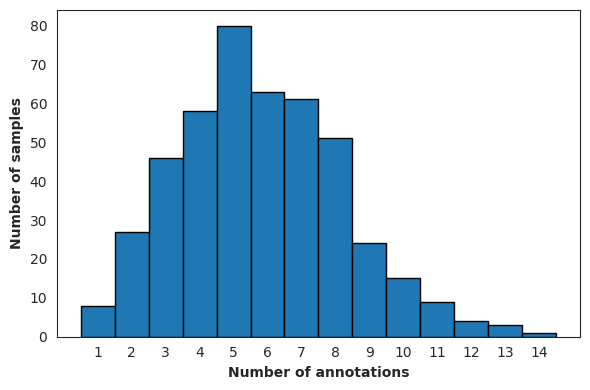

In [25]:
values = id_counts['n_ids']

# Define integer bin edges (include max + 1 so the last value is captured)
bins = np.arange(values.min(), values.max() + 2) - 0.5

plt.figure(figsize=(6,4))
plt.hist(values, bins=bins, edgecolor='black')

plt.xlabel('Number of annotations', fontweight='bold')
plt.ylabel('Number of samples', fontweight='bold')

# Set x-ticks exactly on integers
plt.xticks(np.arange(values.min(), values.max() + 1))

plt.tight_layout()
plt.show()

In [26]:
ids_few_raters = (
    df_human
    .groupby('ID')['human_id']
    .nunique()
    .loc[lambda x: x < 3]
    .index
)

ids_few_raters

Index([  3,  37,  56,  66,  87, 106, 127, 134, 138, 141, 142, 148, 194, 195,
       204, 222, 259, 288, 291, 300, 309, 313, 315, 319, 326, 337, 343, 353,
       363, 366, 373, 402, 415, 418, 428],
      dtype='int64', name='ID')

In [27]:
ids_one_raters = (
    df_human
    .groupby('ID')['human_id']
    .nunique()
    .loc[lambda x: x == 1]
    .index
)

ids_one_raters

Index([37, 148, 195, 259, 288, 309, 353, 418], dtype='int64', name='ID')

In [28]:
ids_few_raters_nonzero = (
    df_human.loc[df_human['strength_value'] > 0]
    .groupby('ID')['human_id']
    .nunique()
    .loc[lambda x: x < 3]
    .index
)

ids_few_raters_nonzero

Index([  3,  37,  56,  66,  87, 106, 127, 134, 138, 141, 142, 148, 173, 194,
       195, 204, 222, 259, 288, 291, 300, 309, 313, 315, 319, 326, 337, 343,
       353, 363, 366, 373, 402, 415, 418, 428],
      dtype='int64', name='ID')

# Moral Foundations Stats

In [29]:
summary = (
    df_clean.loc[df_clean['label_type'] == 'human']
    .drop_duplicates(subset="ID")
    .groupby("moral_foundation")
    .agg(
        N=("moral_foundation", "size"),
        rot_mean=("rot_agree", "mean"),
        rot_se=("rot_agree", "sem"),
        action_mean=("action_agree", "mean"),
        action_se=("action_agree", "sem"),
    )
)

summary["Rule-of-Thumb"] = summary.apply(lambda r: f"{r['rot_mean']:.2f} ± {r['rot_se']:.2f}", axis=1)
summary["Action"] = summary.apply(lambda r: f"{r['action_mean']:.2f} ± {r['action_se']:.2f}", axis=1)

summary = summary[["N", "Rule-of-Thumb", "Action"]]
summary.index.name = "Moral Foundation"

summary

,N,Rule-of-Thumb,Action
Moral Foundation,,,
authority-subversion,89,2.98 ± 0.08,2.99 ± 0.08
care-harm,93,3.22 ± 0.09,3.16 ± 0.09
fairness-cheating,89,3.09 ± 0.10,3.12 ± 0.08
loyalty-betrayal,89,3.01 ± 0.08,3.06 ± 0.08
sancticity-degradation,90,3.11 ± 0.08,3.13 ± 0.09


# Gwet's Agreement

## Emotion

In [30]:
df_human_clean = df_clean[
    (df_clean["label_type"] == "human") &
    (~df_clean["ID"].isin(ids_few_raters))
].copy()

rows = []

for _, row in df_human_clean.iterrows():
    vid = row["ID"]
    hid = row["human_id"]

    # Self emotions
    for emo in major_emotions:
        rows.append({
            "ID": vid,
            "human_id": hid,
            "emotion_type": "emotion_actor",
            "emotion": emo,
            "selected": 1 if emo in row["self_emotion_list"] else 0
        })

    # Other emotions
    etype_map = {0: "emotion_friend", 1: "emotion_acquaintance", 2: "emotion_stranger"}
    for idx, etype in etype_map.items():
        other_list = row["other_emotion_list"]
        emo_list = other_list[idx] if isinstance(other_list, list) and len(other_list) > idx and isinstance(other_list[idx], list) else []
        for emo in major_emotions:
            rows.append({
                "ID": vid,
                "human_id": hid,
                "emotion_type": etype,
                "emotion": emo,
                "selected": 1 if emo in emo_list else 0
            })

df_bin = pd.DataFrame(rows)
df_bin

,ID,human_id,emotion_type,emotion,selected
0,1,R_1bHJcpADL6ZNNEJ,emotion_actor,Pride,0
1,1,R_1bHJcpADL6ZNNEJ,emotion_actor,Shame,0
2,1,R_1bHJcpADL6ZNNEJ,emotion_actor,Guilt,1
3,1,R_1bHJcpADL6ZNNEJ,emotion_actor,Embarrassment,0
4,1,R_1bHJcpADL6ZNNEJ,emotion_actor,Contempt,0
...,...,...,...,...,...
81627,451,R_3w1BFpil07tKcql,emotion_stranger,Embarrassment,1
81628,451,R_3w1BFpil07tKcql,emotion_stranger,Contempt,0
81629,451,R_3w1BFpil07tKcql,emotion_stranger,Anger,0
81630,451,R_3w1BFpil07tKcql,emotion_stranger,Disgust,1


In [31]:
81632 / 8 / 4

2551.0

In [32]:
results = []

grouped = df_bin.groupby(['emotion', 'emotion_type'])

for (emotion, etype), subdf in grouped:

    # print(emotion, ", ", etype, ": ", subdf['selected'].mean())

    # Create wide table (ID × human_id)
    table = subdf.pivot_table(
        index='ID',
        columns='human_id',
        values='selected'
    )

    # Skip if too small
    if table.shape[0] < 2:
        continue

    from irrCAC.raw import CAC

    cac = CAC(table)
    gwet = cac.gwet()

    results.append({
        'emotion': emotion,
        'emotion_type': etype,
        'AC1': gwet['est']['coefficient_value']
    })

results_df = pd.DataFrame(results)
nice_table = results_df.pivot(
    index='emotion',
    columns='emotion_type',
    values='AC1'
).round(3)

nice_table

emotion_type,emotion_acquaintance,emotion_actor,emotion_friend,emotion_stranger
emotion,,,,
Anger,0.479,0.630,0.354,0.499
Compassion,0.637,0.880,0.531,0.653
Contempt,0.339,0.658,0.464,0.351
Disgust,0.253,0.598,0.274,0.219
Embarrassment,0.389,0.241,0.129,0.598
Guilt,0.871,0.223,0.785,0.921
Pride,0.918,0.609,0.900,0.938
Shame,0.623,0.225,0.376,0.777


### Gwet's AC2

In [33]:
df_human_main = df_all.loc[(df_all['rater_group'] == 'human') & (df_all['strength_value'] > 0) & (~df_all['ID'].isin(ids_few_raters_nonzero))].reset_index(drop=True).copy()
df = df_human_main.copy()
df_bin = (
    df.groupby(['ID', 'emotion_type', 'emotion', 'human_id'], as_index=False)
      .agg(strength_value=('strength_value', 'max'))  # if selected at least once → 1
)
df_bin

,ID,emotion_type,emotion,human_id,strength_value
0,1,emotion_acquaintance,Compassion,R_6r37TI1xGGUVeaA,3
1,1,emotion_acquaintance,Compassion,R_7JCKEF65rh5eA8Y,2
2,1,emotion_acquaintance,Contempt,R_3R48rDclzghStqN,3
3,1,emotion_acquaintance,Embarrassment,R_7o9lY3vQcqsE4pP,3
4,1,emotion_acquaintance,Guilt,R_1bHJcpADL6ZNNEJ,2
...,...,...,...,...,...
18620,451,emotion_friend,Embarrassment,R_3w1BFpil07tKcql,3
18621,451,emotion_stranger,Disgust,R_3w1BFpil07tKcql,4
18622,451,emotion_stranger,Disgust,R_6tmmPJhXGdMAgKw,3
18623,451,emotion_stranger,Disgust,R_7HsettKvGuSvQpb,1


In [34]:
df_bin['strength_value'].unique()

array([3, 2, 4, 1])

In [35]:
results = []

# ordinal categories present in your scale
cats = [1, 2, 3, 4]
k = len(cats)

# quadratic agreement weights
# 1 = perfect agreement, smaller values = larger disagreement
weights = np.zeros((k, k))
for i in range(k):
    for j in range(k):
        weights[i, j] = 1 - ((i - j) / (k - 1))**2

grouped = df_bin.groupby(['emotion', 'emotion_type'])

for (emotion, etype), subdf in grouped:

    # print(emotion, ",", etype, ":", subdf['strength_value'].mean())

    table = subdf.pivot_table(
        index='ID',
        columns='human_id',
        values='strength_value'
    )

    if table.shape[0] < 2:
        continue

    cac = CAC(table, weights=weights)

    # Depending on irrCAC version, one of these patterns should work:
    # gwet = cac.gwet(weights=weights)
    # gwet = cac.gwet(weight=weights)
    gwet = cac.gwet()

    results.append({
        'emotion': emotion,
        'emotion_type': etype,
        'AC2': gwet['est']['coefficient_value']
    })

results_df = pd.DataFrame(results)

nice_table = results_df.pivot(
    index='emotion',
    columns='emotion_type',
    values='AC2'
).round(3)

nice_table

emotion_type,emotion_acquaintance,emotion_actor,emotion_friend,emotion_stranger
emotion,,,,
Anger,0.309,0.423,0.294,0.220
Compassion,0.534,0.536,0.412,0.670
Contempt,0.339,0.391,0.338,0.309
Disgust,0.245,0.235,0.309,0.243
Embarrassment,0.306,0.313,0.273,0.262
Guilt,0.302,0.324,0.253,0.194
Pride,0.082,0.295,0.337,0.084
Shame,0.249,0.286,0.259,0.234


## Action

In [36]:
df_human_main = df_clean.loc[(df_clean['rater_group'] == 'human') & (~df_clean['ID'].isin(ids_few_raters))].copy()
df_act = df_human_main.copy()
action_cols = [
    'friends_reaction',
    'acquaintances_reaction',
    'strangers_reaction'
]

df_act_should = df_human_main.copy()
action_should_cols = [
    'friends_reaction_should',
    'acquaintances_reaction_should',
    'strangers_reaction_should'
]

df_act_long = df_act.melt(
    id_vars=['ID', 'human_id'],
    value_vars=action_cols,
    var_name='action_type',
    value_name='chosen_action'
)

df_act_long = df_act_long.drop_duplicates(
    subset=['ID', 'human_id', 'action_type', 'chosen_action']
)

df_act_should_long = df_act_should.melt(
    id_vars=['ID', 'human_id'],
    value_vars=action_should_cols,
    var_name='action_type',
    value_name='chosen_action'
)

df_act_should_long = df_act_should_long.drop_duplicates(
    subset=['ID', 'human_id', 'action_type', 'chosen_action']
)

In [37]:
all_actions = df_act_long['chosen_action'].unique()
df_expanded = df_act_long.assign(key=1).merge(
    pd.DataFrame({'action': all_actions, 'key': 1}),
    on='key'
).drop('key', axis=1)

df_expanded['selected'] = (
    df_expanded['chosen_action'] == df_expanded['action']
).astype(int)


all_actions_should = df_act_should_long['chosen_action'].unique()
df_expanded_should = df_act_should_long.assign(key=1).merge(
    pd.DataFrame({'action': all_actions_should, 'key': 1}),
    on='key'
).drop('key', axis=1)

df_expanded_should['selected'] = (
    df_expanded_should['chosen_action'] == df_expanded_should['action']
).astype(int)

In [38]:
df_actions = df_expanded[df_expanded['selected'] == 1].copy()
df_actions

,ID,human_id,action_type,chosen_action,action,selected
0,1,R_1bHJcpADL6ZNNEJ,friends_reaction,Verbal confrontation,Verbal confrontation,1
9,1,R_7JCKEF65rh5eA8Y,friends_reaction,Support,Support,1
16,1,R_3R48rDclzghStqN,friends_reaction,Verbal confrontation,Verbal confrontation,1
26,1,R_7o9lY3vQcqsE4pP,friends_reaction,Stay away,Stay away,1
33,1,R_6r37TI1xGGUVeaA,friends_reaction,Support,Support,1
...,...,...,...,...,...,...
61151,450,R_3w1BFpil07tKcql,strangers_reaction,Inform authority,Inform authority,1
61159,450,R_5zRYJCZE3hbKrOP,strangers_reaction,Inform authority,Inform authority,1
61163,451,R_7HsettKvGuSvQpb,strangers_reaction,Do nothing,Do nothing,1
61171,451,R_6tmmPJhXGdMAgKw,strangers_reaction,Do nothing,Do nothing,1


In [39]:
df_actions = df_expanded.copy()
results = []
grouped = df_actions.groupby(['action', 'action_type'])

for (action, atype), subdf in grouped:

    # Pivot: ID × human_id (binary selected)
    table = subdf.pivot_table(
        index='ID',
        columns='human_id',
        values='selected',
        aggfunc='max'
    )

    # Keep items with at least 2 raters
    table = table.dropna(thresh=2)

    if table.shape[0] < 2 or table.shape[1] < 2:
        continue

    cac = CAC(table)
    gwet = cac.gwet()

    results.append({
        'action': action,
        'action_type': atype,
        'AC1': gwet['est']['coefficient_value'],
        'n_items': table.shape[0],
        'n_raters': table.shape[1]
    })

results_df = pd.DataFrame(results)
nice_table = results_df.pivot(
    index='action',
    columns='action_type',
    values='AC1'
).round(3)

nice_table

action_type,acquaintances_reaction,friends_reaction,strangers_reaction
action,,,
Do nothing,0.182,0.517,0.167
Gossip,0.422,0.545,0.791
Inform authority,0.952,0.961,0.944
Physical confrontation,0.971,0.944,0.975
Praise,0.979,0.973,0.987
Stay away,0.701,0.871,0.655
Support,0.868,0.755,0.954
Verbal confrontation,0.769,0.286,0.857


In [40]:
df_actions = df_expanded_should.copy()
results = []
grouped = df_actions.groupby(['action', 'action_type'])

for (action, atype), subdf in grouped:

    # Pivot: ID × human_id (binary selected)
    table = subdf.pivot_table(
        index='ID',
        columns='human_id',
        values='selected',
        aggfunc='max'
    )

    # Keep items with at least 2 raters
    table = table.dropna(thresh=2)

    if table.shape[0] < 2 or table.shape[1] < 2:
        continue

    cac = CAC(table)
    gwet = cac.gwet()

    results.append({
        'action': action,
        'action_type': atype,
        'AC1': gwet['est']['coefficient_value'],
        'n_items': table.shape[0],
        'n_raters': table.shape[1]
    })

results_df = pd.DataFrame(results)
nice_table = results_df.pivot(
    index='action',
    columns='action_type',
    values='AC1'
).round(3)

nice_table

action_type,acquaintances_reaction_should,friends_reaction_should,strangers_reaction_should
action,,,
Do nothing,0.144,0.400,0.269
Gossip,0.900,0.922,0.944
Inform authority,0.931,0.941,0.925
Physical confrontation,0.966,0.941,0.985
Praise,0.984,0.973,0.987
Stay away,0.721,0.878,0.681
Support,0.827,0.704,0.931
Verbal confrontation,0.627,0.219,0.823


# Emotion Distribution

**Mean number of emotions selected by different raters when only considering the 8 MAJOR emotions**

In [41]:
df_emo = df_clean.copy()
df_emo["human_id"] = df_emo["human_id"].fillna(df_emo["label_type"])

all_means = []

# Actor (self) emotions
self_counts = (
    df_emo
    .groupby(["ID", "label_type", "human_id", "actor_gender"])["self_emotion_list"]
    .first()
    .apply(lambda x: len(x) if isinstance(x, list) else 0)
    .reset_index(name="n_emotions")
)

means = (
    self_counts.loc[self_counts["n_emotions"] > 0]
    .groupby("label_type")["n_emotions"]
    .agg(["mean", "std", "count"])
    .round(2)
    .assign(emotion_type="Actor")
    .reset_index()
)
all_means.append(means)

# Other emotions: 0=Friend, 1=Acquaintance, 2=Stranger
other_map = {0: "Friend", 1: "Acquaintance", 2: "Stranger"}

for idx, name in other_map.items():
    other_counts = (
        df_emo
        .groupby(["ID", "label_type", "human_id", "actor_gender"])["other_emotion_list"]
        .first()
        .apply(lambda x: len(x[idx]) if isinstance(x, list) and len(x) > idx and isinstance(x[idx], list) else 0)
        .reset_index(name="n_emotions")
    )
    means = (
        other_counts.loc[other_counts["n_emotions"] > 0]
        .groupby("label_type")["n_emotions"]
        .agg(["mean", "std", "count"])
        .round(2)
        .assign(emotion_type=name)
        .reset_index()
    )
    all_means.append(means)

emotion_summary = pd.concat(all_means, ignore_index=True)
emotion_summary.pivot(index="label_type", columns="emotion_type", values="mean")

emotion_type,Acquaintance,Actor,Friend,Stranger
label_type,,,,
claude,1.83,1.77,2.23,1.85
gemini,2.04,1.78,2.24,1.84
gemma,1.69,2.15,2.04,1.62
gpt_5.2,2.53,2.25,2.84,2.41
gpt_oss,2.08,2.08,2.31,1.94
human,1.69,2.10,2.06,1.50
llama,1.74,1.95,2.62,1.39


**Mean number of emotions selected by different raters when considering ALL emotions, including the others suggested by LLMs**

In [42]:
df_emo = df_emotions.copy()
df_emo["human_id"] = df_emo["human_id"].fillna(df_emo["label_type"])

all_means = []

# Actor (self) emotions
self_counts = (
    df_emo
    .groupby(["ID", "label_type", "human_id", "actor_gender"])["self_emotion_list"]
    .first()
    .apply(lambda x: len(x) if isinstance(x, list) else 0)
    .reset_index(name="n_emotions")
)

means = (
    self_counts.loc[self_counts["n_emotions"] > 0]
    .groupby("label_type")["n_emotions"]
    .agg(["mean", "std", "count"])
    .round(2)
    .assign(emotion_type="Actor")
    .reset_index()
)
all_means.append(means)

# Other emotions: 0=Friend, 1=Acquaintance, 2=Stranger
other_map = {0: "Friend", 1: "Acquaintance", 2: "Stranger"}

for idx, name in other_map.items():
    other_counts = (
        df_emo
        .groupby(["ID", "label_type", "human_id", "actor_gender"])["other_emotion_list"]
        .first()
        .apply(lambda x: len(x[idx]) if isinstance(x, list) and len(x) > idx and isinstance(x[idx], list) else 0)
        .reset_index(name="n_emotions")
    )
    means = (
        other_counts.loc[other_counts["n_emotions"] > 0]
        .groupby("label_type")["n_emotions"]
        .agg(["mean", "std", "count"])
        .round(2)
        .assign(emotion_type=name)
        .reset_index()
    )
    all_means.append(means)

emotion_summary = pd.concat(all_means, ignore_index=True)
emotion_summary.pivot(index="label_type", columns="emotion_type", values="mean")

emotion_type,Acquaintance,Actor,Friend,Stranger
label_type,,,,
claude,2.37,2.31,3.36,2.19
gemini,2.25,2.29,2.73,1.97
gemma,1.69,2.15,2.04,1.61
gpt_5.2,2.82,2.79,3.27,2.56
gpt_oss,2.09,2.10,2.32,1.94
human,1.69,2.10,2.06,1.50
llama,1.74,1.95,2.63,1.39


In [43]:
def count_emotions(emotion_lists):
    """
    emotion_lists: iterable of lists of emotions
    returns: dict emotion -> count
    """
    counts = {e: 0 for e in emotions}
    for lst in emotion_lists:
        if not isinstance(lst, list):
            continue
        for e in lst:
            if e in counts:
                counts[e] += 1
    return counts

def get_observer_emotions(df, idx):
    return df["other_emotion_list"].apply(
        lambda x: x[idx] if isinstance(x, list) and len(x) > idx else []
    )

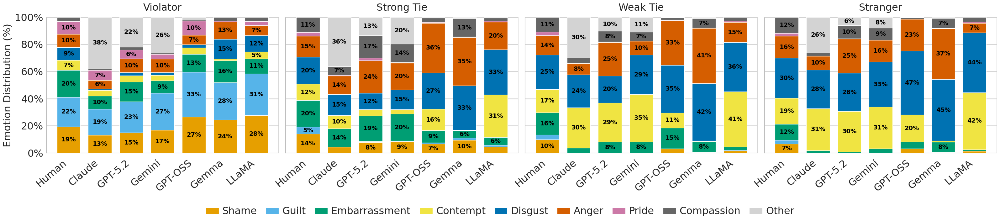

In [44]:
# --------------------------------------------------
# Font sizes
# --------------------------------------------------
fontsize = 23
YLABEL_FONTSIZE = fontsize
TICK_FONTSIZE = fontsize
TITLE_FONTSIZE = fontsize
LEGEND_TITLE_FONTSIZE = fontsize
LEGEND_LABEL_FONTSIZE = fontsize

# ----------------------------
# Major emotion order
# ----------------------------
emotions = [
    "Shame", "Guilt", "Embarrassment", "Contempt",
    "Disgust", "Anger", "Pride", "Compassion"
]

# major_emotions = [
#     "Shame", "Guilt", "Embarrassment", "Contempt",
#     "Disgust", "Anger", "Pride", "Compassion"
# ]

plot_emotions = emotions + ["Other"]

# ----------------------------
# Colors
# ----------------------------
colors = {
    "Shame": "#E69F00",
    "Guilt": "#56B4E9",
    "Embarrassment": "#009E73",
    "Contempt": "#F0E442",
    "Disgust": "#0072B2",
    "Anger": "#D55E00",
    "Pride": "#CC79A7",
    "Compassion": "#666666",
    "Other": "#D3D3D3"
}

# ----------------------------
# Model dictionary
# ----------------------------
models = {
    "gemini": df_emotions[df_emotions["label_type"] == "gemini"],
    "gpt_5.2": df_emotions[df_emotions["label_type"] == "gpt_5.2"],
    "claude": df_emotions[df_emotions["label_type"] == "claude"],
    "gpt_oss": df_emotions[df_emotions["label_type"] == "gpt_oss"],
    "gemma": df_emotions[df_emotions["label_type"] == "gemma"],
    "llama": df_emotions[df_emotions["label_type"] == "llama"],
    "human": df_emotions[df_emotions["label_type"] == "human"],
}

# ----------------------------
# Define which models get "Other"
# ----------------------------
all_models = {"gemini", "gpt_5.2", "claude", "gpt_oss", "llama", "gemma"}

pretty_names = {
    "gemini": "Gemini",
    "gpt_5.2": "GPT-5.2",
    "claude": "Claude",
    "gpt_oss": "GPT-OSS",
    "gemma": "Gemma",
    "llama": "LLaMA",
    "human": "Human"
}

# ----------------------------
# Totals
# ----------------------------
totals = {}

for name, df in models.items():
    totals[name] = {
        "self": df["self_emotion_list"].apply(len).sum(),
        "friend": df["other_emotion_list"].apply(lambda x: len(x[0]) if isinstance(x, list) else 0).sum(),
        "acquaintance": df["other_emotion_list"].apply(lambda x: len(x[1]) if isinstance(x, list) else 0).sum(),
        "stranger": df["other_emotion_list"].apply(lambda x: len(x[2]) if isinstance(x, list) else 0).sum(),
    }

# ----------------------------
# Counts of the 8 major emotions only
# count_emotions(...) should return counts for these major emotions
# ----------------------------
counts = {}

for name, df in models.items():
    counts[name] = {
        "self": count_emotions(df["self_emotion_list"]),
        "friend": count_emotions(get_observer_emotions(df, 0)),
        "acquaintance": count_emotions(get_observer_emotions(df, 1)),
        "stranger": count_emotions(get_observer_emotions(df, 2)),
    }

# ----------------------------
# Convert counts -> proportions
# ----------------------------
def to_proportions(counts_dict, total, include_other=False):
    # major emotions
    props = {
        emo: counts_dict.get(emo, 0) / total if total > 0 else 0
        for emo in emotions
    }

    # "Other" only for selected models, computed from actual counts
    if include_other:
        counted_major = sum(counts_dict.get(emo, 0) for emo in emotions)
        other_count = max(0, total - counted_major)
        props["Other"] = other_count / total if total > 0 else 0
    else:
        props["Other"] = 0

    return props

# ----------------------------
# Build DataFrame for one model
# ----------------------------
def build_df(model_name):
    include_other = model_name in all_models

    data = {
        "Violator": to_proportions(
            counts[model_name]["self"],
            totals[model_name]["self"],
            include_other=include_other
        ),
        "Strong Tie": to_proportions(
            counts[model_name]["friend"],
            totals[model_name]["friend"],
            include_other=include_other
        ),
        "Weak Tie": to_proportions(
            counts[model_name]["acquaintance"],
            totals[model_name]["acquaintance"],
            include_other=include_other
        ),
        "Stranger": to_proportions(
            counts[model_name]["stranger"],
            totals[model_name]["stranger"],
            include_other=include_other
        ),
    }

    df_plot = pd.DataFrame(data)
    df_plot = df_plot.reindex(plot_emotions).fillna(0)
    return df_plot

# ----------------------------
# Build plot DataFrames
# ----------------------------
model_order = ["human", "claude", "gpt_5.2", "gemini", "gpt_oss", "gemma", "llama"]

plot_dfs = {m: build_df(m) for m in model_order}
panels = [(pretty_names[m], plot_dfs[m]) for m in model_order]

# ----------------------------
# Plot settings — 1×4 layout
# ----------------------------
categories = ["Violator", "Strong Tie", "Weak Tie", "Stranger"]
model_order = ["human", "claude", "gpt_5.2", "gemini", "gpt_oss", "gemma", "llama"]
x = np.arange(len(model_order))
bar_width = 0.75

fig, axes = plt.subplots(1, 4, figsize=(32, 7), sharey=True)

for ax, category in zip(axes, categories):
    bottoms = np.zeros(len(model_order))

    for emo in plot_emotions:
        vals = np.array([plot_dfs[m].loc[emo, category] for m in model_order])
        ax.bar(
            x, vals, bottom=bottoms, width=bar_width,
            color=colors[emo], edgecolor="white",
            linewidth=0.8, label=emo, zorder=3,
        )

        for i, (v, b) in enumerate(zip(vals, bottoms)):
            if v >= 0.05:
                ax.text(
                    x[i], b + v / 2, f"{v * 100:.0f}%",
                    ha="center", va="center", fontsize=14,
                    fontweight="bold", color="black", zorder=4,
                )

        bottoms += vals

    ax.set_title(category, fontsize=TITLE_FONTSIZE, pad=15)
    if ax == axes[0]:
        ax.set_ylabel("Emotion Distribution (%)", fontsize=YLABEL_FONTSIZE)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [pretty_names[m] for m in model_order],
        rotation=40, ha="right", fontsize=TICK_FONTSIZE,
    )
    ax.tick_params(axis="x", pad=8)

    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)

    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="-", linewidth=2, alpha=0.9, color="#d0d0d0")

    ax.spines["left"].set_visible(True)
    ax.spines["left"].set_color("#bfbfbf")
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_color("#bfbfbf")
    ax.spines["bottom"].set_linewidth(1.5)
    ax.spines["top"].set_visible(True)
    ax.spines["top"].set_color("#cfcfcf")
    ax.spines["top"].set_linewidth(1.2)
    ax.spines["right"].set_visible(True)
    ax.spines["right"].set_color("#cfcfcf")
    ax.spines["right"].set_linewidth(1.2)

# Legend at top, horizontal
handles, labels = axes[0].get_legend_handles_labels()
legend = fig.legend(
    handles, labels,
    loc="upper center", bbox_to_anchor=(0.5, 0.0),
    ncol=len(plot_emotions), frameon=False,
    handlelength=3, handleheight=2,
    # handletextpad=0.5, columnspacing=1.0,
)
# Vertically align color boxes with text
for handle in legend.legend_handles:
    handle.set_y(handle.get_y() + 4)

legend.get_title().set_fontsize(LEGEND_TITLE_FONTSIZE)
for text in legend.get_texts():
    text.set_fontsize(LEGEND_LABEL_FONTSIZE)

fig.tight_layout(rect=[0, 0.02, 1, 0.93])
plt.subplots_adjust(wspace=0.03)
plt.show()

## Table

In [45]:
# Build the table for each model
def build_emotion_table(df_model, emotions, model_name):
    """
    Returns a DataFrame with rows = emotions,
    columns = Men, Women, Strong Tie, Weak Tie, Stranger
    Values = "XX.X% (count)"
    """
    # Split by gender for self (violator)
    df_male = df_model[df_model["actor_gender"] == "male"]
    df_female = df_model[df_model["actor_gender"] == "female"]

    # Count emotions
    def count_and_proportion(emotion_series, total_label="total"):
        all_emotions = [e for sublist in emotion_series for e in sublist]
        total = len(all_emotions)
        counts = pd.Series(all_emotions).value_counts()
        return counts, total

    results = {}

    # --- Violator by gender ---
    male_counts, male_total = count_and_proportion(df_male["self_emotion_list"])
    female_counts, female_total = count_and_proportion(df_female["self_emotion_list"])

    # --- Observers (all genders combined) ---
    friend_emotions = get_observer_emotions(df_model, 0)
    acq_emotions = get_observer_emotions(df_model, 1)
    stranger_emotions = get_observer_emotions(df_model, 2)

    friend_all = [e for sublist in friend_emotions for e in sublist]
    acq_all = [e for sublist in acq_emotions for e in sublist]
    stranger_all = [e for sublist in stranger_emotions for e in sublist]

    friend_counts = pd.Series(friend_all).value_counts()
    acq_counts = pd.Series(acq_all).value_counts()
    stranger_counts = pd.Series(stranger_all).value_counts()

    friend_total = len(friend_all)
    acq_total = len(acq_all)
    stranger_total = len(stranger_all)

    rows = []
    for emo in emotions:
        mc = male_counts.get(emo, 0)
        fc = female_counts.get(emo, 0)
        frc = friend_counts.get(emo, 0)
        ac = acq_counts.get(emo, 0)
        sc = stranger_counts.get(emo, 0)

        rows.append({
            "Emotion": emo,
            "Men": f"{mc/male_total*100:.1f}% ({mc})" if male_total > 0 else "0.0% (0)",
            "Women": f"{fc/female_total*100:.1f}% ({fc})" if female_total > 0 else "0.0% (0)",
            "Strong Tie": f"{frc/friend_total*100:.1f}% ({frc})" if friend_total > 0 else "0.0% (0)",
            "Weak Tie": f"{ac/acq_total*100:.1f}% ({ac})" if acq_total > 0 else "0.0% (0)",
            "Stranger": f"{sc/stranger_total*100:.1f}% ({sc})" if stranger_total > 0 else "0.0% (0)",
        })

    return pd.DataFrame(rows).set_index("Emotion")


# Generate tables for all models
emotions = [
    "Shame", "Guilt", "Embarrassment", "Contempt",
    "Disgust", "Anger", "Pride", "Compassion"
]

model_names = ["human", "claude", "gpt_5.2", "gemini", "gpt_oss", "gemma", "llama"]

for model_name in model_names:
    df_model = df_emotions[df_emotions["label_type"] == model_name]
    table = build_emotion_table(df_model, emotions, model_name)

    print(f"\n{'='*80}")
    print(f"  {pretty_names[model_name]}")
    print(f"{'='*80}")
    display(table)


  Human


,Men,Women,Strong Tie,Weak Tie,Stranger
Emotion,,,,,
Shame,20.1% (549),18.9% (520),14.1% (757),9.9% (432),6.8% (265)
Guilt,21.8% (597),21.6% (594),5.0% (269),3.6% (159),2.6% (100)
Embarrassment,20.0% (547),19.6% (539),19.7% (1062),16.3% (716),11.9% (465)
Contempt,6.8% (185),8.2% (226),11.9% (640),17.1% (750),19.0% (740)
Disgust,9.6% (263),9.3% (255),19.9% (1070),25.3% (1111),29.7% (1156)
Anger,9.3% (256),10.0% (276),15.4% (827),14.2% (624),16.1% (627)
Pride,9.7% (265),9.4% (259),2.8% (149),2.6% (113),2.2% (86)
Compassion,2.8% (76),3.2% (87),11.2% (604),10.9% (479),11.8% (458)



  Claude


,Men,Women,Strong Tie,Weak Tie,Stranger
Emotion,,,,,
Shame,13.4% (119),12.7% (121),4.4% (122),0.0% (0),0.0% (0)
Guilt,19.7% (175),19.0% (181),0.0% (1),0.0% (0),0.0% (0)
Embarrassment,9.2% (82),9.8% (93),13.6% (379),3.7% (68),1.9% (25)
Contempt,3.7% (33),4.6% (44),9.7% (270),29.8% (545),30.9% (404)
Disgust,0.9% (8),1.3% (12),15.4% (427),24.2% (443),28.4% (372)
Anger,6.5% (58),6.2% (59),13.6% (377),8.2% (150),10.1% (132)
Pride,7.7% (68),6.8% (65),0.5% (14),0.1% (2),0.2% (2)
Compassion,0.9% (8),1.6% (15),6.6% (183),4.2% (76),2.4% (32)



  GPT-5.2


...

,Men,Women,Strong Tie,Weak Tie,Stranger
Emotion,,,,,
Shame,26.0% (217),27.2% (229),6.8% (129),3.1% (50),3.3% (36)
Guilt,33.7% (281),32.3% (272),0.8% (15),0.2% (3),0.1% (1)
Embarrassment,13.5% (113),12.6% (106),9.1% (173),15.3% (246),4.9% (54)
Contempt,5.2% (43),4.6% (39),15.6% (297),11.0% (177),19.8% (219)
Disgust,2.3% (19),2.4% (20),26.9% (512),35.2% (567),47.2% (522)
Anger,6.4% (53),7.4% (62),36.4% (692),33.0% (532),23.2% (256)
Pride,10.2% (85),10.5% (88),0.6% (12),0.4% (6),0.1% (1)
Compassion,0.7% (6),0.7% (6),3.4% (65),1.6% (25),1.3% (14)



  Gemma


,Men,Women,Strong Tie,Weak Tie,Stranger
Emotion,,,,,
Shame,24.6% (225),24.3% (223),9.5% (166),0.4% (5),0.4% (5)
Guilt,27.1% (248),28.1% (258),1.5% (26),0.1% (2),0.1% (2)
Embarrassment,14.7% (135),17.6% (162),5.7% (99),8.1% (114),7.7% (103)
Contempt,1.2% (11),0.9% (8),0.2% (3),0.5% (7),0.7% (10)
Disgust,14.8% (136),14.4% (132),32.7% (571),42.2% (596),45.4% (610)
Anger,14.6% (134),11.3% (104),35.5% (619),40.5% (572),37.4% (502)
Pride,0.4% (4),0.5% (5),0.5% (8),0.2% (3),0.2% (3)
Compassion,2.5% (23),2.9% (27),13.4% (234),6.9% (97),7.0% (94)



  LLaMA


,Men,Women,Strong Tie,Weak Tie,Stranger
Emotion,,,,,
Shame,29.3% (237),26.3% (209),4.5% (99),1.7% (25),1.4% (16)
Guilt,31.9% (258),29.4% (234),1.2% (26),0.3% (4),0.1% (1)
Embarrassment,9.9% (80),12.2% (97),5.9% (128),2.6% (37),1.1% (13)
Contempt,5.1% (41),5.2% (41),31.2% (681),40.7% (586),42.0% (480)
Disgust,11.6% (94),12.2% (97),33.3% (725),36.1% (520),44.0% (503)
Anger,6.7% (54),8.2% (65),20.3% (443),14.7% (212),7.0% (80)
Pride,3.1% (25),3.1% (25),0.6% (14),0.9% (13),1.0% (11)
Compassion,2.3% (19),3.5% (28),2.5% (55),2.9% (42),3.5% (40)


## Other Emotions

In [46]:
# Collect all unique "other" emotions per model and social distance
for name in ["claude", "gpt_5.2", "gemini", "gpt_oss", "gemma", "llama"]:
    df_model = models[name]

    print(f"\n{'='*60}")
    print(f"  {pretty_names[name]}")
    print(f"{'='*60}")

    for dist_name, dist_key in [("Violator", "self"), ("Strong Tie", "friend"),
                                 ("Weak Tie", "acquaintance"), ("Stranger", "stranger")]:
        if dist_key == "self":
            all_emos = [e for sublist in df_model["self_emotion_list"] for e in sublist]
        else:
            idx = {"friend": 0, "acquaintance": 1, "stranger": 2}[dist_key]
            observer_emos = get_observer_emotions(df_model, idx)
            all_emos = [e for sublist in observer_emos for e in sublist]

        # Filter to non-major emotions
        other_emos = [e for e in all_emos if e not in emotions]

        if other_emos:
            other_counts = pd.Series(other_emos).value_counts()
            total = len(all_emos)
            print(f"\n  {dist_name} (total={total}, other={len(other_emos)}, {len(other_emos)/total*100:.1f}%):")
            for emo, count in other_counts.items():
                print(f"    {emo}: {count} ({count/total*100:.1f}%)")
        else:
            print(f"\n  {dist_name}: no 'Other' emotions")


  Claude

  Violator (total=1838, other=697, 37.9%):
    Frustration: 80 (4.4%)
    Indifference: 60 (3.3%)
    Satisfaction: 59 (3.2%)
    Relief: 45 (2.4%)
    Amusement: 29 (1.6%)
    Anxiety: 28 (1.5%)
    Excitement: 27 (1.5%)
    Sadness: 27 (1.5%)
    Insecurity: 21 (1.1%)
    Righteousness: 17 (0.9%)
    Entitlement: 15 (0.8%)
    Regret: 14 (0.8%)
    Determination: 14 (0.8%)
    Hurt: 13 (0.7%)
    Fear: 12 (0.7%)
    Jealousy: 12 (0.7%)
    Curiosity: 12 (0.7%)
    Conflict: 11 (0.6%)
    Concern: 11 (0.6%)
    Contentment: 11 (0.6%)
    Defensiveness: 10 (0.5%)
    Justified: 9 (0.5%)
    Conviction: 9 (0.5%)
    Resentment: 8 (0.4%)
    Vindication: 7 (0.4%)
    Disappointment: 7 (0.4%)
    Enjoyment: 7 (0.4%)
    Nervousness: 7 (0.4%)
    Despair: 6 (0.3%)
    Happiness: 5 (0.3%)
    Annoyance: 5 (0.3%)
    Stress: 4 (0.2%)
    Loneliness: 4 (0.2%)
    Confusion: 4 (0.2%)
    Longing: 4 (0.2%)
    Self-loathing: 4 (0.2%)
    Hopelessness: 4 (0.2%)
    Irritation: 3 (0.2%

# Action Distribution

In [47]:
ACTION_CANONICAL_MAP = {
    # --- Do nothing ---
    "Do nothing": "Do nothing",

    # --- Gossip ---
    "Gossip": "Gossip",
    "Gossip about / discuss with / complain to others informally": "Gossip",

    # --- Inform authority ---
    "Inform authority": "Inform authority",
    "Inform the authorities, such as the police": "Inform authority",

    # --- Stay away ---
    "Stay away": "Stay away",
    "Stay away or keep a distance from the actor": "Stay away",

    # --- Support ---
    "Support": "Support",
    "Support the actor": "Support",

    # --- Verbal confrontation ---
    "Verbal confrontation": "Verbal confrontation",
    "Verbal reprimand / verbal confrontation": "Verbal confrontation",

    # --- Physical confrontation ---
    "Physical confrontation": "Physical confrontation",

    # --- Praise ---
    "Praise": "Praise",
    "Celebrate / praise": "Praise",
}

In [48]:
ACTION_ORDER = [
    "Do nothing",
    "Stay away",
    "Gossip",
    "Verbal confrontation",
    "Physical confrontation",
    "Inform authority",
    "Support",
    "Praise",
]

ACTION_COLORS = {
    "Do nothing": "#7f7f7f",
    "Stay away": "#e69f00",
    "Gossip": "#56b4e9",
    "Verbal confrontation": "#009e73",
    "Physical confrontation": "#f0e442",
    "Inform authority": "#0072b2",
    "Support": "#d55e00",
    "Praise": "#cc79a7",
}

## Would

In [49]:
DISTANCE_COLS = {
    "friends_reaction": "Strong tie",
    "acquaintances_reaction": "Weak tie",
    "strangers_reaction": "Stranger",
}

df_long = (
    df_clean[["ID", "label_type", *DISTANCE_COLS.keys()]]
    .melt(
        id_vars=["ID", "label_type"],
        value_vars=DISTANCE_COLS.keys(),
        var_name="distance_raw",
        value_name="action_raw",
    )
    .dropna(subset=["action_raw"])
)

df_long["distance"] = df_long["distance_raw"].map(DISTANCE_COLS)
df_long["action"] = df_long["action_raw"].map(ACTION_CANONICAL_MAP)
df_long = df_long.dropna(subset=["action"])

counts = (
    df_long
    .groupby(["label_type", "distance", "action"])
    .size()
    .reset_index(name="count")
)

# Pad with 0s for all combinations
all_actions = [
    "Do nothing", "Stay away", "Gossip", "Verbal confrontation",
    "Physical confrontation", "Inform authority", "Support", "Praise",
]
all_distances = list(DISTANCE_COLS.values())
all_label_types = df_long["label_type"].unique()

full_idx = pd.MultiIndex.from_product(
    [all_label_types, all_distances, all_actions],
    names=["label_type", "distance", "action"],
)

counts = (
    counts
    .set_index(["label_type", "distance", "action"])
    .reindex(full_idx, fill_value=0)
    .reset_index()
)

counts["percent"] = (
    counts
    .groupby(["label_type", "distance"])["count"]
    .transform(lambda x: x / x.sum() * 100 if x.sum() > 0 else 0)
)

counts

,label_type,distance,action,count,percent
0,human,Strong tie,Do nothing,580,22.196709
1,human,Strong tie,Stay away,162,6.199770
2,human,Strong tie,Gossip,519,19.862227
3,human,Strong tie,Verbal confrontation,848,32.453119
4,human,Strong tie,Physical confrontation,70,2.678913
...,...,...,...,...,...
163,llama,Stranger,Verbal confrontation,0,0.000000
164,llama,Stranger,Physical confrontation,0,0.000000
165,llama,Stranger,Inform authority,4,0.468933
166,llama,Stranger,Support,49,5.744431


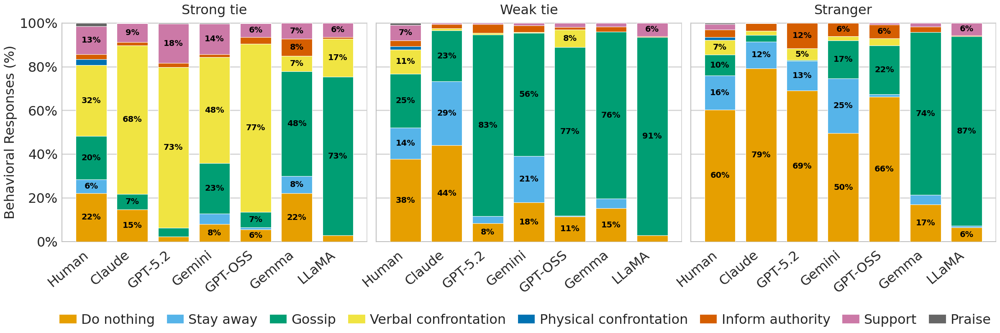

In [50]:
# ----------------------------
# Plot settings — 1×3 layout
# ----------------------------
distances = ["Strong tie", "Weak tie", "Stranger"]
model_order = ["human", "claude", "gpt_5.2", "gemini", "gpt_oss", "gemma", "llama"]
all_actions = [
    "Do nothing", "Stay away", "Gossip", "Verbal confrontation",
    "Physical confrontation", "Inform authority", "Support", "Praise",
]

pretty_names = {
    "gemini": "Gemini",
    "gpt_5.2": "GPT-5.2",
    "claude": "Claude",
    "gpt_oss": "GPT-OSS",
    "gemma": "Gemma",
    "llama": "LLaMA",
    "human": "Human",
}

action_colors = {
    "Do nothing": "#E69F00",
    "Stay away": "#56B4E9",
    "Gossip": "#009E73",
    "Verbal confrontation": "#F0E442",
    "Physical confrontation": "#0072B2",
    "Inform authority": "#D55E00",
    "Support": "#CC79A7",
    "Praise": "#666666",
}

x = np.arange(len(model_order))
bar_width = 0.75

fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)

for ax, dist in zip(axes, distances):
    bottoms = np.zeros(len(model_order))

    for action in all_actions:
        vals = []
        for m in model_order:
            row = counts[
                (counts["label_type"] == m)
                & (counts["distance"] == dist)
                & (counts["action"] == action)
            ]
            vals.append(row["percent"].values[0] / 100 if len(row) > 0 else 0)
        vals = np.array(vals)

        ax.bar(
            x, vals, bottom=bottoms, width=bar_width,
            color=action_colors[action], edgecolor="white",
            linewidth=0.8, label=action, zorder=3,
        )

        # Annotate percentages >= 5%
        for i, (v, b) in enumerate(zip(vals, bottoms)):
            if v >= 0.05:
                ax.text(
                    x[i], b + v / 2, f"{v * 100:.0f}%",
                    ha="center", va="center", fontsize=14,
                    fontweight="bold", color="black", zorder=4,
                )

        bottoms += vals

    ax.set_title(dist, fontsize=TITLE_FONTSIZE, pad=15)
    if ax == axes[0]:
      ax.set_ylabel("Behavioral Responses (%)", fontsize=YLABEL_FONTSIZE)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [pretty_names[m] for m in model_order],
        rotation=40, ha="right", fontsize=TICK_FONTSIZE,
    )
    ax.tick_params(axis="x", pad=8)

    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)

    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="-", linewidth=2, alpha=0.9, color="#d0d0d0")

    ax.spines["left"].set_visible(True)
    ax.spines["left"].set_color("#bfbfbf")
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_color("#bfbfbf")
    ax.spines["bottom"].set_linewidth(1.5)
    ax.spines["top"].set_visible(True)
    ax.spines["top"].set_color("#cfcfcf")
    ax.spines["top"].set_linewidth(1.2)
    ax.spines["right"].set_visible(True)
    ax.spines["right"].set_color("#cfcfcf")
    ax.spines["right"].set_linewidth(1.2)

# Legend
handles, labels = axes[0].get_legend_handles_labels()
legend = fig.legend(
    handles, labels,
    loc="upper center", bbox_to_anchor=(0.525, 0.0),
    ncol=len(all_actions), frameon=False,
    handlelength=3, handleheight=2,
    # handletextpad=0.5, columnspacing=1.0,
)
# Vertically align color boxes with text
for handle in legend.legend_handles:
    handle.set_y(handle.get_y() + 5)

legend.get_title().set_fontsize(LEGEND_TITLE_FONTSIZE)
for text in legend.get_texts():
    text.set_fontsize(LEGEND_LABEL_FONTSIZE)

fig.tight_layout(rect=[0, 0.02, 1, 0.93])
plt.subplots_adjust(wspace=0.03)
plt.show()

### Table

In [51]:
model_names = ["human", "claude", "gpt_5.2", "gemini", "gpt_oss", "gemma", "llama"]

all_actions = [
    "Do nothing", "Stay away", "Gossip", "Verbal confrontation",
    "Physical confrontation", "Inform authority", "Support", "Praise",
]
all_distances = ["Strong tie", "Weak tie", "Stranger"]

for model_name in model_names:
    df_model = counts[counts["label_type"] == model_name]

    rows = []
    for action in all_actions:
        row = {"Reaction type": action}

        overall_count = 0
        overall_total = 0

        for dist in all_distances:
            r = df_model[(df_model["action"] == action) & (df_model["distance"] == dist)]
            c = r["count"].values[0] if len(r) > 0 else 0
            p = r["percent"].values[0] if len(r) > 0 else 0.0
            row[dist] = f"{c:,} ({p:.1f}%)"

            overall_count += c
            dist_total = df_model[df_model["distance"] == dist]["count"].sum()
            overall_total += dist_total

        overall_pct = overall_count / overall_total * 100 if overall_total > 0 else 0
        row["Overall"] = f"{overall_count:,} ({overall_pct:.1f}%)"

        rows.append(row)

    table = pd.DataFrame(rows).set_index("Reaction type")

    print(f"\n{'='*80}")
    print(f"  {pretty_names[model_name]}")
    print(f"{'='*80}")
    display(table)


  Human


,Strong tie,Weak tie,Stranger,Overall
Reaction type,,,,
Do nothing,580 (22.2%),986 (37.7%),"1,576 (60.3%)","3,142 (40.1%)"
Stay away,162 (6.2%),374 (14.3%),407 (15.6%),943 (12.0%)
Gossip,519 (19.9%),646 (24.7%),251 (9.6%),"1,416 (18.1%)"
Verbal confrontation,848 (32.5%),287 (11.0%),175 (6.7%),"1,310 (16.7%)"
Physical confrontation,70 (2.7%),38 (1.5%),35 (1.3%),143 (1.8%)
Inform authority,58 (2.2%),73 (2.8%),86 (3.3%),217 (2.8%)
Support,334 (12.8%),182 (7.0%),65 (2.5%),581 (7.4%)
Praise,42 (1.6%),27 (1.0%),18 (0.7%),87 (1.1%)



  Claude


,Strong tie,Weak tie,Stranger,Overall
Reaction type,,,,
Do nothing,125 (14.7%),376 (44.1%),675 (79.1%),"1,176 (46.0%)"
Stay away,1 (0.1%),249 (29.2%),105 (12.3%),355 (13.9%)
Gossip,60 (7.0%),198 (23.2%),25 (2.9%),283 (11.1%)
Verbal confrontation,579 (67.9%),9 (1.1%),17 (2.0%),605 (23.6%)
Physical confrontation,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
Inform authority,13 (1.5%),16 (1.9%),29 (3.4%),58 (2.3%)
Support,73 (8.6%),5 (0.6%),2 (0.2%),80 (3.1%)
Praise,2 (0.2%),0 (0.0%),0 (0.0%),2 (0.1%)



  GPT-5.2


...

,Strong tie,Weak tie,Stranger,Overall
Reaction type,,,,
Do nothing,47 (5.5%),98 (11.5%),564 (66.1%),709 (27.7%)
Stay away,8 (0.9%),3 (0.4%),10 (1.2%),21 (0.8%)
Gossip,61 (7.2%),657 (77.0%),191 (22.4%),909 (35.5%)
Verbal confrontation,655 (76.8%),68 (8.0%),27 (3.2%),750 (29.3%)
Physical confrontation,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
Inform authority,26 (3.0%),11 (1.3%),54 (6.3%),91 (3.6%)
Support,54 (6.3%),15 (1.8%),7 (0.8%),76 (3.0%)
Praise,2 (0.2%),1 (0.1%),0 (0.0%),3 (0.1%)



  Gemma


,Strong tie,Weak tie,Stranger,Overall
Reaction type,,,,
Do nothing,188 (22.0%),130 (15.2%),145 (17.0%),463 (18.1%)
Stay away,67 (7.9%),37 (4.3%),37 (4.3%),141 (5.5%)
Gossip,409 (47.9%),651 (76.3%),635 (74.4%),"1,695 (66.2%)"
Verbal confrontation,60 (7.0%),0 (0.0%),0 (0.0%),60 (2.3%)
Physical confrontation,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
Inform authority,66 (7.7%),20 (2.3%),21 (2.5%),107 (4.2%)
Support,63 (7.4%),15 (1.8%),15 (1.8%),93 (3.6%)
Praise,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)



  LLaMA


,Strong tie,Weak tie,Stranger,Overall
Reaction type,,,,
Do nothing,24 (2.8%),24 (2.8%),55 (6.4%),103 (4.0%)
Stay away,0 (0.0%),0 (0.0%),7 (0.8%),7 (0.3%)
Gossip,619 (72.6%),773 (90.6%),738 (86.5%),"2,130 (83.2%)"
Verbal confrontation,148 (17.4%),0 (0.0%),0 (0.0%),148 (5.8%)
Physical confrontation,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
Inform authority,7 (0.8%),4 (0.5%),4 (0.5%),15 (0.6%)
Support,55 (6.4%),52 (6.1%),49 (5.7%),156 (6.1%)
Praise,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)


## Should

In [52]:
DISTANCE_COLS = {
    "friends_reaction_should": "Strong tie",
    "acquaintances_reaction_should": "Weak tie",
    "strangers_reaction_should": "Stranger",
}

df_long = (
    df_clean[["ID", "label_type", *DISTANCE_COLS.keys()]]
    .melt(
        id_vars=["ID", "label_type"],
        value_vars=DISTANCE_COLS.keys(),
        var_name="distance_raw",
        value_name="action_raw",
    )
    .dropna(subset=["action_raw"])
)

df_long["distance"] = df_long["distance_raw"].map(DISTANCE_COLS)
df_long["action"] = df_long["action_raw"].map(ACTION_CANONICAL_MAP)
df_long = df_long.dropna(subset=["action"])

counts = (
    df_long
    .groupby(["label_type", "distance", "action"])
    .size()
    .reset_index(name="count")
)

# Pad with 0s for all combinations
all_actions = [
    "Do nothing", "Stay away", "Gossip", "Verbal confrontation",
    "Physical confrontation", "Inform authority", "Support", "Praise",
]
all_distances = list(DISTANCE_COLS.values())
all_label_types = df_long["label_type"].unique()

full_idx = pd.MultiIndex.from_product(
    [all_label_types, all_distances, all_actions],
    names=["label_type", "distance", "action"],
)

counts = (
    counts
    .set_index(["label_type", "distance", "action"])
    .reindex(full_idx, fill_value=0)
    .reset_index()
)

counts["percent"] = (
    counts
    .groupby(["label_type", "distance"])["count"]
    .transform(lambda x: x / x.sum() * 100 if x.sum() > 0 else 0)
)

counts

,label_type,distance,action,count,percent
0,human,Strong tie,Do nothing,734,28.090318
1,human,Strong tie,Stay away,154,5.893609
2,human,Strong tie,Gossip,100,3.827019
3,human,Strong tie,Verbal confrontation,1016,38.882511
4,human,Strong tie,Physical confrontation,74,2.831994
...,...,...,...,...,...
163,llama,Stranger,Verbal confrontation,716,83.939039
164,llama,Stranger,Physical confrontation,0,0.000000
165,llama,Stranger,Inform authority,7,0.820633
166,llama,Stranger,Support,50,5.861665


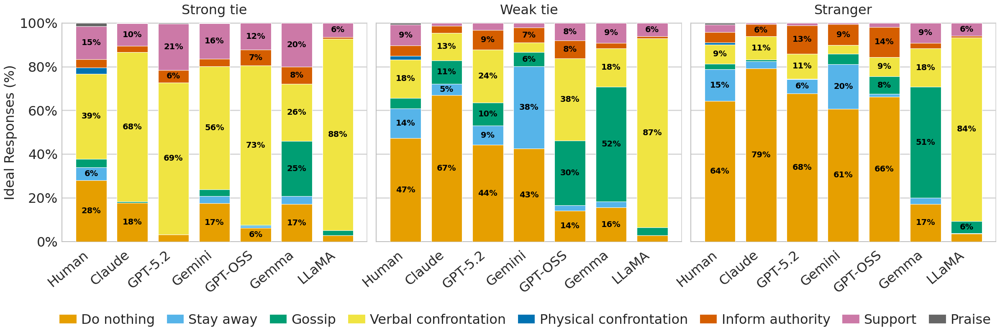

In [53]:
# ----------------------------
# Plot settings — 1×3 layout
# ----------------------------
distances = ["Strong tie", "Weak tie", "Stranger"]
model_order = ["human", "claude", "gpt_5.2", "gemini", "gpt_oss", "gemma", "llama"]
all_actions = [
    "Do nothing", "Stay away", "Gossip", "Verbal confrontation",
    "Physical confrontation", "Inform authority", "Support", "Praise",
]

pretty_names = {
    "gemini": "Gemini",
    "gpt_5.2": "GPT-5.2",
    "claude": "Claude",
    "gpt_oss": "GPT-OSS",
    "gemma": "Gemma",
    "llama": "LLaMA",
    "human": "Human",
}

action_colors = {
    "Do nothing": "#E69F00",
    "Stay away": "#56B4E9",
    "Gossip": "#009E73",
    "Verbal confrontation": "#F0E442",
    "Physical confrontation": "#0072B2",
    "Inform authority": "#D55E00",
    "Support": "#CC79A7",
    "Praise": "#666666",
}

x = np.arange(len(model_order))
bar_width = 0.75

fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)

for ax, dist in zip(axes, distances):
    bottoms = np.zeros(len(model_order))

    for action in all_actions:
        vals = []
        for m in model_order:
            row = counts[
                (counts["label_type"] == m)
                & (counts["distance"] == dist)
                & (counts["action"] == action)
            ]
            vals.append(row["percent"].values[0] / 100 if len(row) > 0 else 0)
        vals = np.array(vals)

        ax.bar(
            x, vals, bottom=bottoms, width=bar_width,
            color=action_colors[action], edgecolor="white",
            linewidth=0.8, label=action, zorder=3,
        )

        # Annotate percentages >= 5%
        for i, (v, b) in enumerate(zip(vals, bottoms)):
            if v >= 0.05:
                ax.text(
                    x[i], b + v / 2, f"{v * 100:.0f}%",
                    ha="center", va="center", fontsize=14,
                    fontweight="bold", color="black", zorder=4,
                )

        bottoms += vals

    ax.set_title(dist, fontsize=TITLE_FONTSIZE, pad=15)
    if ax == axes[0]:
      ax.set_ylabel("Ideal Responses (%)", fontsize=YLABEL_FONTSIZE)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [pretty_names[m] for m in model_order],
        rotation=40, ha="right", fontsize=TICK_FONTSIZE,
    )
    ax.tick_params(axis="x", pad=8)

    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)

    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="-", linewidth=2, alpha=0.9, color="#d0d0d0")

    ax.spines["left"].set_visible(True)
    ax.spines["left"].set_color("#bfbfbf")
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_color("#bfbfbf")
    ax.spines["bottom"].set_linewidth(1.5)
    ax.spines["top"].set_visible(True)
    ax.spines["top"].set_color("#cfcfcf")
    ax.spines["top"].set_linewidth(1.2)
    ax.spines["right"].set_visible(True)
    ax.spines["right"].set_color("#cfcfcf")
    ax.spines["right"].set_linewidth(1.2)

# Legend
handles, labels = axes[0].get_legend_handles_labels()
legend = fig.legend(
    handles, labels,
    loc="upper center", bbox_to_anchor=(0.525, 0.0),
    ncol=len(all_actions), frameon=False,
    handlelength=3, handleheight=2,
    # handletextpad=0.5, columnspacing=1.0,
)
# Vertically align color boxes with text
for handle in legend.legend_handles:
    handle.set_y(handle.get_y() + 5)

legend.get_title().set_fontsize(LEGEND_TITLE_FONTSIZE)
for text in legend.get_texts():
    text.set_fontsize(LEGEND_LABEL_FONTSIZE)

fig.tight_layout(rect=[0, 0.02, 1, 0.93])
plt.subplots_adjust(wspace=0.03)
plt.show()

### Table

In [54]:
model_names = ["human", "claude", "gpt_5.2", "gemini", "gpt_oss", "gemma", "llama"]

all_actions = [
    "Do nothing", "Stay away", "Gossip", "Verbal confrontation",
    "Physical confrontation", "Inform authority", "Support", "Praise",
]
all_distances = ["Strong tie", "Weak tie", "Stranger"]

for model_name in model_names:
    df_model = counts[counts["label_type"] == model_name]

    rows = []
    for action in all_actions:
        row = {"Reaction type": action}

        overall_count = 0
        overall_total = 0

        for dist in all_distances:
            r = df_model[(df_model["action"] == action) & (df_model["distance"] == dist)]
            c = r["count"].values[0] if len(r) > 0 else 0
            p = r["percent"].values[0] if len(r) > 0 else 0.0
            row[dist] = f"{c:,} ({p:.1f}%)"

            overall_count += c
            dist_total = df_model[df_model["distance"] == dist]["count"].sum()
            overall_total += dist_total

        overall_pct = overall_count / overall_total * 100 if overall_total > 0 else 0
        row["Overall"] = f"{overall_count:,} ({overall_pct:.1f}%)"

        rows.append(row)

    table = pd.DataFrame(rows).set_index("Reaction type")

    print(f"\n{'='*80}")
    print(f"  {pretty_names[model_name]}")
    print(f"{'='*80}")
    display(table)


  Human


,Strong tie,Weak tie,Stranger,Overall
Reaction type,,,,
Do nothing,734 (28.1%),"1,236 (47.3%)","1,678 (64.2%)","3,648 (46.5%)"
Stay away,154 (5.9%),355 (13.6%),379 (14.5%),888 (11.3%)
Gossip,100 (3.8%),125 (4.8%),68 (2.6%),293 (3.7%)
Verbal confrontation,"1,016 (38.9%)",459 (17.6%),228 (8.7%),"1,703 (21.7%)"
Physical confrontation,74 (2.8%),45 (1.7%),23 (0.9%),142 (1.8%)
Inform authority,101 (3.9%),123 (4.7%),125 (4.8%),349 (4.5%)
Support,394 (15.1%),247 (9.5%),93 (3.6%),734 (9.4%)
Praise,40 (1.5%),23 (0.9%),19 (0.7%),82 (1.0%)



  Claude


,Strong tie,Weak tie,Stranger,Overall
Reaction type,,,,
Do nothing,151 (17.7%),571 (66.9%),675 (79.1%),"1,397 (54.6%)"
Stay away,0 (0.0%),44 (5.2%),28 (3.3%),72 (2.8%)
Gossip,5 (0.6%),92 (10.8%),7 (0.8%),104 (4.1%)
Verbal confrontation,583 (68.3%),107 (12.5%),90 (10.6%),780 (30.5%)
Physical confrontation,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
Inform authority,24 (2.8%),27 (3.2%),47 (5.5%),98 (3.8%)
Support,88 (10.3%),12 (1.4%),6 (0.7%),106 (4.1%)
Praise,2 (0.2%),0 (0.0%),0 (0.0%),2 (0.1%)



  GPT-5.2


...

,Strong tie,Weak tie,Stranger,Overall
Reaction type,,,,
Do nothing,53 (6.2%),121 (14.2%),564 (66.1%),738 (28.8%)
Stay away,9 (1.1%),21 (2.5%),12 (1.4%),42 (1.6%)
Gossip,3 (0.4%),252 (29.5%),68 (8.0%),323 (12.6%)
Verbal confrontation,621 (72.8%),321 (37.6%),76 (8.9%),"1,018 (39.8%)"
Physical confrontation,1 (0.1%),0 (0.0%),0 (0.0%),1 (0.0%)
Inform authority,61 (7.2%),69 (8.1%),116 (13.6%),246 (9.6%)
Support,104 (12.2%),68 (8.0%),17 (2.0%),189 (7.4%)
Praise,1 (0.1%),1 (0.1%),0 (0.0%),2 (0.1%)



  Gemma


,Strong tie,Weak tie,Stranger,Overall
Reaction type,,,,
Do nothing,146 (17.1%),133 (15.6%),147 (17.2%),426 (16.6%)
Stay away,31 (3.6%),24 (2.8%),24 (2.8%),79 (3.1%)
Gossip,215 (25.2%),447 (52.4%),432 (50.6%),"1,094 (42.8%)"
Verbal confrontation,223 (26.1%),150 (17.6%),150 (17.6%),523 (20.4%)
Physical confrontation,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
Inform authority,67 (7.9%),21 (2.5%),22 (2.6%),110 (4.3%)
Support,171 (20.0%),78 (9.1%),78 (9.1%),327 (12.8%)
Praise,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)



  LLaMA


,Strong tie,Weak tie,Stranger,Overall
Reaction type,,,,
Do nothing,24 (2.8%),24 (2.8%),31 (3.6%),79 (3.1%)
Stay away,0 (0.0%),0 (0.0%),1 (0.1%),1 (0.0%)
Gossip,20 (2.3%),31 (3.6%),48 (5.6%),99 (3.9%)
Verbal confrontation,747 (87.6%),738 (86.5%),716 (83.9%),"2,201 (86.0%)"
Physical confrontation,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
Inform authority,7 (0.8%),7 (0.8%),7 (0.8%),21 (0.8%)
Support,55 (6.4%),53 (6.2%),50 (5.9%),158 (6.2%)
Praise,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)


# Co-occuring Emotions

In [55]:
df_human = df_all[(df_all["rater_group"] == "human")].reset_index(drop=True).copy()
df_human

,ID,stimuli,actor,actor_gender,label_type,actor_emotions,friends_emotions,friends_reaction,friends_reaction_should,acquaintances_emotions,...,strength_value,moral_foundation,rot_agree,action_agree,human_id,gender,age,race,education,rater_group
0,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree,human
1,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree,human
2,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree,human
3,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree,human
4,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,0,care-harm,4,4,R_1bHJcpADL6ZNNEJ,Female,53.0,Asian,Bachelor’s degree,human
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83611,451,David smells his socks and underwear every tim...,David,male,human,"Shame, Disgust, Embarrassment","Disgust, Embarrassment",Gossip,Gossip,"Shame, Disgust, Embarrassment",...,0,sancticity-degradation,2,2,R_3w1BFpil07tKcql,Male,25.0,Asian,Bachelor’s degree,human
83612,451,David smells his socks and underwear every tim...,David,male,human,"Shame, Disgust, Embarrassment","Disgust, Embarrassment",Gossip,Gossip,"Shame, Disgust, Embarrassment",...,3,sancticity-degradation,2,2,R_3w1BFpil07tKcql,Male,25.0,Asian,Bachelor’s degree,human
83613,451,David smells his socks and underwear every tim...,David,male,human,"Shame, Disgust, Embarrassment","Disgust, Embarrassment",Gossip,Gossip,"Shame, Disgust, Embarrassment",...,0,sancticity-degradation,2,2,R_3w1BFpil07tKcql,Male,25.0,Asian,Bachelor’s degree,human
83614,451,David smells his socks and underwear every tim...,David,male,human,"Shame, Disgust, Embarrassment","Disgust, Embarrassment",Gossip,Gossip,"Shame, Disgust, Embarrassment",...,0,sancticity-degradation,2,2,R_3w1BFpil07tKcql,Male,25.0,Asian,Bachelor’s degree,human


In [56]:
EMOTIONS = major_emotions

# Union logic: emotion is "selected" if ANY observer type has strength > 0
def union_agg(x):
    """Take mean of non-zero values; if all zero, return 0."""
    non_zero = x[x > 0]
    # If selected by multiple observers with different strengths, take MEAN of non-zero values
    # If all observers have strength 0 for that emotion → 0
    return non_zero.mean() if len(non_zero) > 0 else 0.0

# SELF vector: emotion_type == 'emotion_actor'
df_self = df_human[df_human['emotion_type'] == 'emotion_actor'].copy()

human_self_X = (
    df_self.pivot_table(
        index=['ID', 'human_id'],
        columns='emotion',
        values='strength_value',
        aggfunc=union_agg,  # only one row per (ID, human_id, emotion) for actor
        fill_value=0
    )
    .reindex(columns=EMOTIONS, fill_value=0)
)

# OTHER vectors: emotion_type != 'emotion_actor'
df_other = df_human[df_human['emotion_type'] != 'emotion_actor'].copy()

df_other_stage1 = (
    df_other.groupby(['ID', 'human_id', 'emotion', 'emotion_type'])['strength_value']
    .agg(union_agg)
    .reset_index()
)

# Aggregate across observer types per (ID, emotion)
human_other_X = (
    df_other_stage1.pivot_table(
        index=['ID', 'human_id'],
        columns='emotion',
        values='strength_value',
        aggfunc=union_agg,  # union across friend/acquaintance/stranger
        fill_value=0
    )
    .reindex(columns=EMOTIONS, fill_value=0)
)

print("human_self_X shape:", human_self_X.shape)   # (n_pairs, 8)
print("human_other_X shape:", human_other_X.shape)  # (n_pairs, 8)

human_self_X shape: (2611, 8)
human_other_X shape: (2611, 8)


In [57]:
llm_self_vectors = {}
llm_other_vectors = {}

for label in ["gpt_5.2", "claude", "gemini", "gpt_oss", "llama", "gemma"]:
    df_sub = df_all[df_all["label_type"] == label].copy()

    # SELF: emotion_actor
    df_self = df_sub[df_sub['emotion_type'] == 'emotion_actor']
    llm_self_X = (
            df_self.pivot_table(
                index='ID',
                columns='emotion',
                values='strength_value',
                aggfunc=union_agg,  # mean of non-zero values, 0 if all zero
                fill_value=0
            )
            .reindex(columns=EMOTIONS, fill_value=0)
        )

    # OTHER: union across friend/acquaintance/stranger
    df_other = df_sub[df_sub['emotion_type'] != 'emotion_actor']

    df_other_stage1 = (
        df_other.groupby(['ID', 'emotion', 'emotion_type'])['strength_value']
        .agg(union_agg)
        .reset_index()
    )

    # Aggregate across observer types per (ID, emotion)
    llm_other_X = (
        df_other_stage1.pivot_table(
            index='ID',
            columns='emotion',
            values='strength_value',
            aggfunc=union_agg,  # union across friend/acquaintance/stranger
            fill_value=0
        )
        .reindex(columns=EMOTIONS, fill_value=0)
    )

    llm_self_vectors[label] = llm_self_X
    llm_other_vectors[label] = llm_other_X

    print(f"{label} — self: {llm_self_X.shape}, other: {llm_other_X.shape}")

gpt_5.2 — self: (450, 8), other: (450, 8)
claude — self: (450, 8), other: (450, 8)
gemini — self: (450, 8), other: (450, 8)
gpt_oss — self: (450, 8), other: (450, 8)
llama — self: (450, 8), other: (450, 8)
gemma — self: (450, 8), other: (450, 8)


In [58]:
def corr_with_pvalues(X, emotions, method='spearmanr'):
    """
    Compute pairwise correlation with p-values for continuous intensity vectors.
    method: 'pearson' or 'spearman'
    """
    n = len(emotions)
    corr = np.zeros((n, n))
    pvals = np.ones((n, n))

    corr_func = pearsonr if method == 'pearson' else spearmanr

    for i in range(n):
        for j in range(n):
            x = X[:, i]
            y = X[:, j]

            # handle constant vectors
            if np.std(x) == 0 or np.std(y) == 0:
                corr[i, j] = np.nan
                pvals[i, j] = np.nan
                continue

            r, p = corr_func(x, y)
            corr[i, j] = r
            pvals[i, j] = p

    return (
        pd.DataFrame(corr, index=emotions, columns=emotions),
        pd.DataFrame(pvals, index=emotions, columns=emotions)
    )

# Compute correlations
corr_human_self, _ = corr_with_pvalues(human_self_X.values, EMOTIONS)
corr_human_other, _ = corr_with_pvalues(human_other_X.values, EMOTIONS)

corr_llm_self = {}
corr_llm_other = {}
for label in ["gpt_5.2", "claude", "gemini", "gpt_oss", "llama", "gemma"]:
    corr_llm_self[label], _ = corr_with_pvalues(llm_self_vectors[label].values, EMOTIONS)
    corr_llm_other[label], _ = corr_with_pvalues(llm_other_vectors[label].values, EMOTIONS)

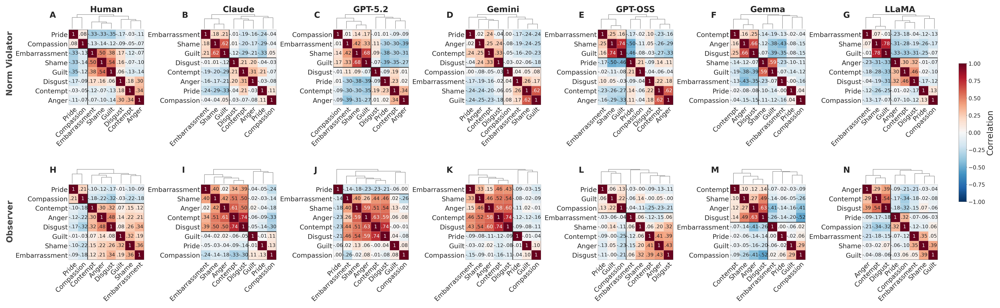

In [59]:
# Settings
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "axes.linewidth":     0.6,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.3,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

def reorder_matrix(mat, order):
    return mat.loc[order, order]

row_names = ["Human", "Claude", "GPT-5.2", "Gemini", "GPT-OSS",  "Gemma", "LLaMA"]
row_keys  = [None, "claude", "gpt_5.2", "gemini", "gpt_oss", "gemma", "llama"]

raw_grid = []  # list of (title, mat) in row-major order for 2×7
for name, key in zip(row_names, row_keys):
    if key is None:
        raw_grid.append(("Norm Violator", corr_human_self))
    else:
        raw_grid.append(("Norm Violator", corr_llm_self[key]))

for name, key in zip(row_names, row_keys):
    if key is None:
        raw_grid.append(("Observer", corr_human_other))
    else:
        raw_grid.append(("Observer", corr_llm_other[key]))

# Global color limits
all_vals = np.concatenate([mat.values.flatten() for _, mat in raw_grid])
vmax = np.nanmax(np.abs(all_vals))
vmin = -vmax

cmap = plt.cm.RdBu_r

PANEL_LABELS = [chr(ord('A') + i) for i in range(14)]

def draw_panel(fig, gs_slot, title, panel_label, mat_orig,
               cmap, vmin, vmax, k_clusters=2, draw_boxes=True):

    n = len(mat_orig)

    dist = 1 - mat_orig.fillna(0)
    dist = (dist + dist.T) / 2
    np.fill_diagonal(dist.values, 0)

    Z = linkage(squareform(dist.values, checks=False), method="average")

    dend_info = dendrogram(Z, labels=mat_orig.index.tolist(), no_plot=True)
    leaf_order = dend_info["ivl"]

    mat = reorder_matrix(mat_orig, leaf_order)

    clusters = fcluster(Z, k_clusters, criterion='maxclust')
    cluster_series = pd.Series(clusters, index=mat_orig.index).loc[leaf_order]
    boundaries = np.where(cluster_series.values[:-1] != cluster_series.values[1:])[0]

    inner = gs_slot.subgridspec(2, 1, height_ratios=[1, 5], hspace=0.02)
    ax_dend = fig.add_subplot(inner[0])
    ax_heat = fig.add_subplot(inner[1])

    plot_data = mat.values.astype(float)

    ax_heat.imshow(
        plot_data, cmap=cmap, vmin=vmin, vmax=vmax,
        aspect="equal", origin="upper", interpolation="nearest",
    )

    for i in range(n + 1):
        ax_heat.axhline(i - 0.5, color="#E0E0E0", linewidth=0.4)
        ax_heat.axvline(i - 0.5, color="#E0E0E0", linewidth=0.4)

    for b in boundaries:
        ax_heat.axhline(b + 0.5, color="#333333", linewidth=2.5)
        ax_heat.axvline(b + 0.5, color="#333333", linewidth=2.5)

    if draw_boxes:
        start = 0
        for b in list(boundaries) + [n - 1]:
            end = b
            ax_heat.add_patch(
                plt.Rectangle(
                    (start - 0.5, start - 0.5),
                    end - start + 1, end - start + 1,
                    fill=False, edgecolor="black", linewidth=1.5
                )
            )
            start = end + 1

    for i in range(n):
        for j in range(n):
            val = mat.iloc[i, j]
            if round(val * 100) == 100:
                txt = "1"
            elif round(val * 100) == -100:
                txt = "-1"
            elif val >= 0:
                txt = f".{int(round(val * 100)):02d}"
            else:
                txt = f"-.{int(round(abs(val) * 100)):02d}"
            text_color = "white" if abs(val) > 0.55 * vmax else "#222222"
            ax_heat.text(j, i, txt, ha="center", va="center",
                         fontsize=18, color=text_color)

    ax_heat.set_xticks(range(n))
    ax_heat.set_xticklabels(leaf_order, fontsize=24,
                            rotation=45, ha="right", rotation_mode="anchor")
    ax_heat.set_yticks(range(n))
    ax_heat.set_yticklabels(leaf_order, fontsize=24)
    ax_heat.tick_params(length=0)
    ax_heat.set_xlim(-0.5, n - 0.5)
    ax_heat.set_ylim(n - 0.5, -0.5)

    for spine in ax_heat.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("#999999")

    dendrogram(
        Z, labels=mat_orig.index.tolist(), ax=ax_dend,
        color_threshold=0, above_threshold_color="#888888",
        leaf_font_size=0,
    )

    for coll in ax_dend.collections:
        for path in coll.get_paths():
            path.vertices[:, 0] = (path.vertices[:, 0] - 5) / 10.0

    ax_dend.set_xlim(-1.5, n + 0.5)
    ax_dend.set_xticks([])
    ax_dend.set_yticks([])

    for spine in ax_dend.spines.values():
        spine.set_visible(False)

    ax_dend.set_title(title, fontsize=30, fontweight="bold", pad=6)
    ax_dend.text(-0.08, 1.15, panel_label,
                 transform=ax_dend.transAxes,
                 fontsize=30, fontweight="bold", va="top")

    return ax_heat

# Figure: 2 rows × 7 cols
fig = plt.figure(figsize=(49, 14))
outer = gridspec.GridSpec(
    2, 7, figure=fig,
    hspace=0.7, wspace=0.35,
    left=0.04, right=0.96,
    top=0.93, bottom=0.04,
)

for idx in range(14):
    row, col = divmod(idx, 7)
    # Column titles (source names) only on first row
    title = row_names[col] if row == 0 else ""
    _, mat_orig = raw_grid[idx]

    draw_panel(
        fig, outer[row, col], title, PANEL_LABELS[idx],
        mat_orig, cmap, vmin, vmax,
        k_clusters=2, draw_boxes=True
    )

# Row labels (perspective) on the left
perspective_labels = ["Norm Violator", "Observer"]
for i, label in enumerate(perspective_labels):
    y = 1 - (i + 0.5) / 2
    y -= i * 0.07  # slight adjustment
    fig.text(-0.009, y, label, fontsize=30, fontweight="bold",
             rotation=90, ha="center", va="center", color="#444444")

# Colorbar
cbar_ax = fig.add_axes([0.97, 0.25, 0.008, 0.50])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.ax.tick_params(labelsize=20)
cbar.outline.set_linewidth(0.6)
cbar.set_label("Correlation", fontsize=30)

plt.show()

# Emotion Intensity Distribution

In [60]:
df_all_human = df_all.loc[df_all['rater_group'] == 'human']
df_llms = {}

for label in ["gpt_5.2", "claude", "gemini", "gpt_oss", "llama", "gemma"]:
    df_llms[label] = df_all[df_all["label_type"] == label].copy()

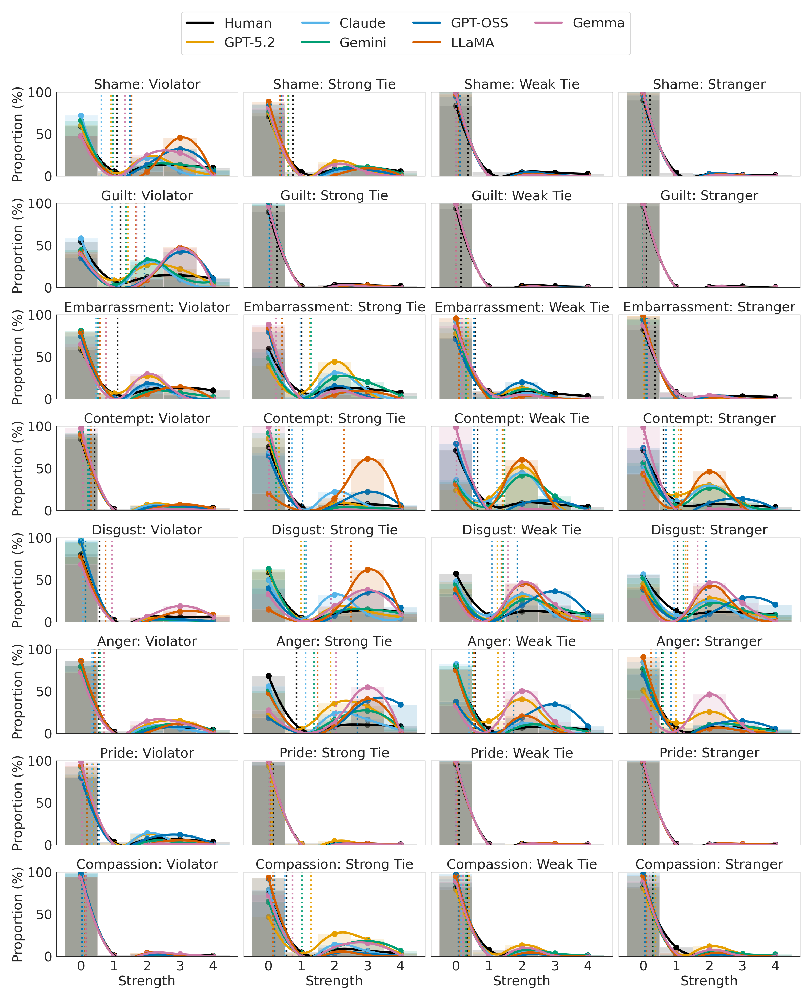

In [61]:
# -----------------------------
# Style
# -----------------------------
FONT_SIZE = 24
LINE_WIDTH = 4
MARKER_SIZE = 10
SMOOTH_POINTS = 200

FIG_WIDTH = 20
FIG_HEIGHT = 24

# -----------------------------
ordered_emotions = [
    "Shame", "Guilt", "Embarrassment",
    "Contempt", "Disgust", "Anger", "Pride", "Compassion"
]

emotion_columns = [
    ("emotion_actor", "Violator"),
    ("emotion_friend", "Strong Tie"),
    ("emotion_acquaintance", "Weak Tie"),
    ("emotion_stranger", "Stranger")
]

# -----------------------------
fig, axes = plt.subplots(
    nrows=len(ordered_emotions),
    ncols=len(emotion_columns),
    figsize=(FIG_WIDTH, FIG_HEIGHT),
    sharex=True,
    sharey=True
)

# -----------------------------
datasets = {
    "Human": df_all_human,
    "GPT-5.2": df_llms["gpt_5.2"],
    "Claude": df_llms["claude"],
    "Gemini": df_llms["gemini"],
    "GPT-OSS": df_llms["gpt_oss"],
    "LLaMA": df_llms["llama"],
    "Gemma": df_llms["gemma"],
}

colors = {
    "Human": "#000000",
    "GPT-5.2": "#E69F00",
    "Claude": "#56B4E9",
    "Gemini": "#009E73",
    "GPT-OSS": "#0072B2",
    "LLaMA": "#D55E00",
    "Gemma": "#CC79A7",
}

bins = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
centers = np.array([0, 1, 2, 3, 4])

# -----------------------------
for row, emotion in enumerate(ordered_emotions):

    for col, (emotion_type, label_name) in enumerate(emotion_columns):

        ax = axes[row, col]

        for label, df in datasets.items():

            subset = df.loc[
                (df["emotion"] == emotion) &
                (df["emotion_type"] == emotion_type),
                "strength_value"
            ]

            if len(subset) == 0:
                continue

            # -----------------------------
            weights = np.ones_like(subset) * (100.0 / len(subset))

            ax.hist(
                subset,
                bins=bins,
                weights=weights,
                color=colors[label],
                alpha=0.15,
                edgecolor=None
            )

            # -----------------------------
            counts, _ = np.histogram(subset, bins=bins)
            proportions = counts / counts.sum() * 100

            x_new = np.linspace(centers.min(), centers.max(), SMOOTH_POINTS)
            spline = make_interp_spline(centers, proportions, k=2)
            y_smooth = spline(x_new)

            ax.plot(
                x_new,
                y_smooth,
                color=colors[label],
                linewidth=LINE_WIDTH,
                label=label if (row == 0 and col == 0) else None
            )

            ax.scatter(
                centers,
                proportions,
                color=colors[label],
                s=MARKER_SIZE**2
            )

            # -----------------------------
            mean_val = subset.mean()

            ax.axvline(
                x=mean_val,
                color=colors[label],
                linestyle=":",
                linewidth=3,
                alpha=0.9
            )

        # -----------------------------
        ax.set_title(f"{emotion}: {label_name}", fontsize=FONT_SIZE)

        if col == 0:
            ax.set_ylabel("Proportion (%)", fontsize=FONT_SIZE)

        if row == len(ordered_emotions) - 1:
            ax.set_xlabel("Strength", fontsize=FONT_SIZE)

        ax.set_xticks([0, 1, 2, 3, 4])
        ax.set_ylim(0, 100)
        ax.tick_params(axis='both', labelsize=FONT_SIZE)

# -----------------------------
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    fontsize=FONT_SIZE,
    bbox_to_anchor=(0.5, 1.03)
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

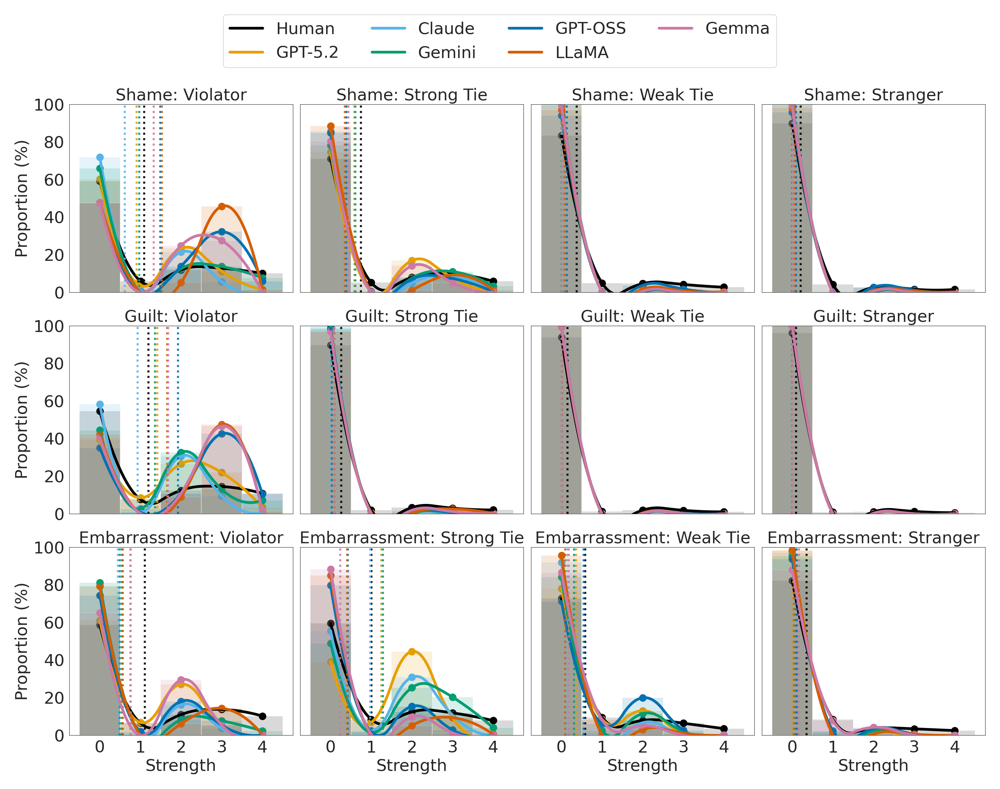

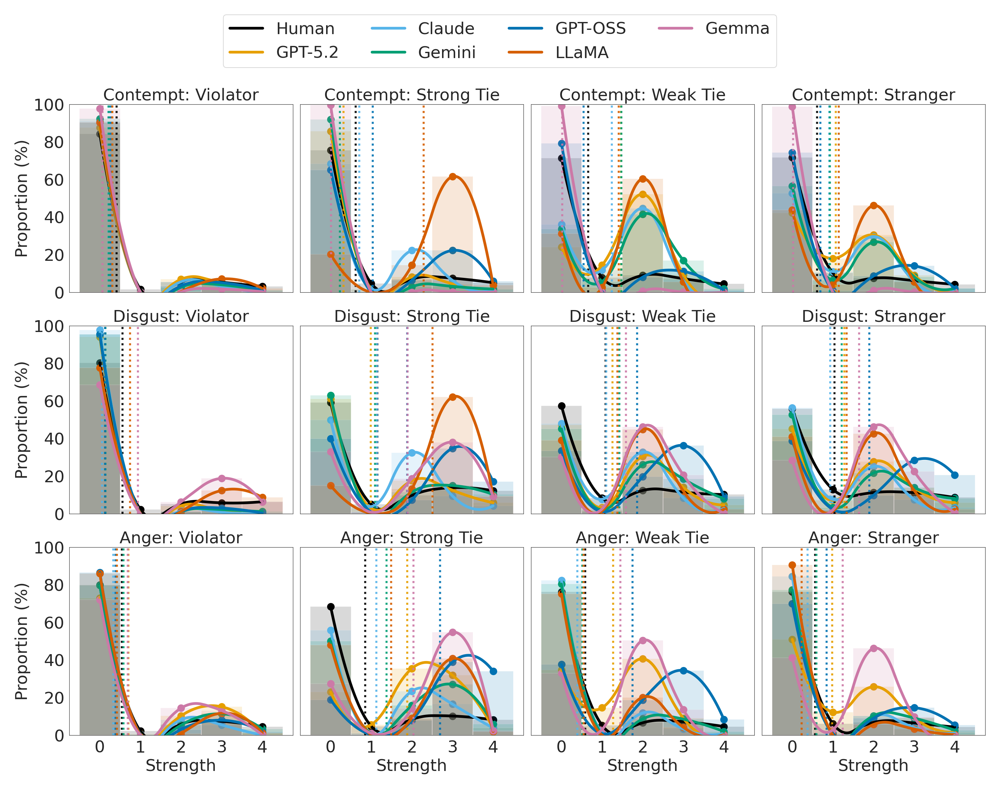

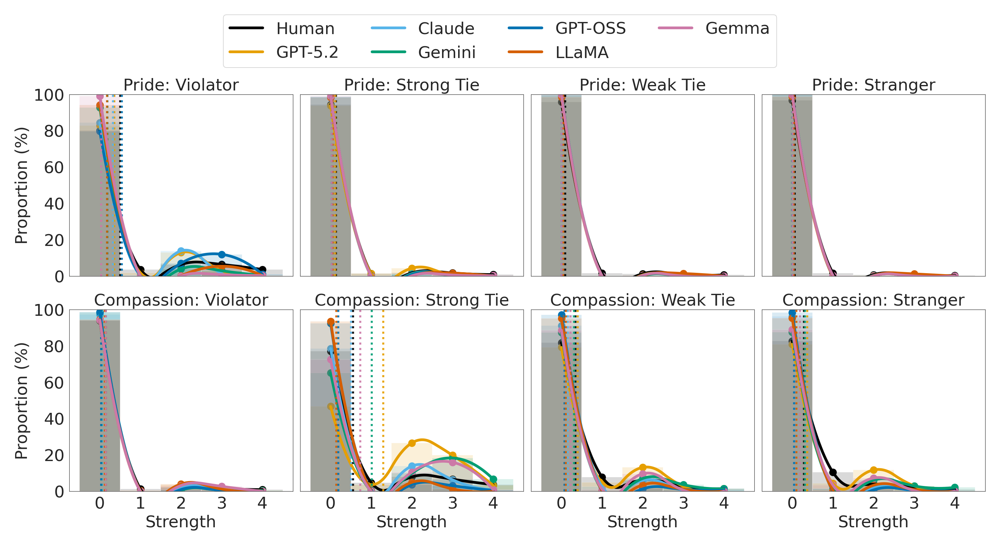

In [62]:
# -----------------------------
# Style
# -----------------------------
FONT_SIZE = 24
LINE_WIDTH = 4
MARKER_SIZE = 10
SMOOTH_POINTS = 200

FIG_WIDTH = 20

# -----------------------------
datasets = {
    "Human": df_all_human,
    "GPT-5.2": df_llms["gpt_5.2"],
    "Claude": df_llms["claude"],
    "Gemini": df_llms["gemini"],
    "GPT-OSS": df_llms["gpt_oss"],
    "LLaMA": df_llms["llama"],
    "Gemma": df_llms["gemma"],
}

colors = {
    "Human": "#000000",
    "GPT-5.2": "#E69F00",
    "Claude": "#56B4E9",
    "Gemini": "#009E73",
    "GPT-OSS": "#0072B2",
    "LLaMA": "#D55E00",
    "Gemma": "#CC79A7",
}

emotion_columns = [
    ("emotion_actor", "Violator"),
    ("emotion_friend", "Strong Tie"),
    ("emotion_acquaintance", "Weak Tie"),
    ("emotion_stranger", "Stranger")
]

bins = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
centers = np.array([0, 1, 2, 3, 4])

# -----------------------------
# Three figures
# -----------------------------
emotion_groups = {
    "Self-Focused Emotions": ["Shame", "Guilt", "Embarrassment"],
    "Other-Focused Emotions": ["Contempt", "Disgust", "Anger"],
    "Positive Emotions": ["Pride", "Compassion"],
}

for group_name, emotions in emotion_groups.items():

    nrows = len(emotions)
    ncols = len(emotion_columns)
    subplot_size = FIG_WIDTH / ncols  # square subplots based on width
    fig_height = nrows * subplot_size

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(FIG_WIDTH, fig_height),
        sharex=True,
        sharey=True
    )

    # Handle single-row case (Positive has 2 rows, but just in case)
    if nrows == 1:
        axes = axes[np.newaxis, :]

    for row, emotion in enumerate(emotions):
        for col, (emotion_type, label_name) in enumerate(emotion_columns):

            ax = axes[row, col]

            for label, df in datasets.items():

                subset = df.loc[
                    (df["emotion"] == emotion) &
                    (df["emotion_type"] == emotion_type),
                    "strength_value"
                ]

                if len(subset) == 0:
                    continue

                weights = np.ones_like(subset) * (100.0 / len(subset))

                ax.hist(
                    subset,
                    bins=bins,
                    weights=weights,
                    color=colors[label],
                    alpha=0.15,
                    edgecolor=None
                )

                counts, _ = np.histogram(subset, bins=bins)
                proportions = counts / counts.sum() * 100

                x_new = np.linspace(centers.min(), centers.max(), SMOOTH_POINTS)
                spline = make_interp_spline(centers, proportions, k=2)
                y_smooth = spline(x_new)

                ax.plot(
                    x_new,
                    y_smooth,
                    color=colors[label],
                    linewidth=LINE_WIDTH,
                    label=label if (row == 0 and col == 0) else None
                )

                ax.scatter(
                    centers,
                    proportions,
                    color=colors[label],
                    s=MARKER_SIZE**2
                )

                mean_val = subset.mean()

                ax.axvline(
                    x=mean_val,
                    color=colors[label],
                    linestyle=":",
                    linewidth=3,
                    alpha=0.9
                )

            ax.set_title(f"{emotion}: {label_name}", fontsize=FONT_SIZE)

            if col == 0:
                ax.set_ylabel("Proportion (%)", fontsize=FONT_SIZE)

            if row == nrows - 1:
                ax.set_xlabel("Strength", fontsize=FONT_SIZE)

            ax.set_xticks([0, 1, 2, 3, 4])
            ax.set_ylim(0, 100)
            ax.tick_params(axis='both', labelsize=FONT_SIZE)

    handles, labels_leg = axes[0, 0].get_legend_handles_labels()
    legend_y = 1.05 if nrows >= 3 else 1.08
    fig.legend(
        handles,
        labels_leg,
        loc="upper center",
        ncol=4,
        fontsize=FONT_SIZE,
        bbox_to_anchor=(0.5, legend_y)
    )

    # fig.suptitle(group_name, fontsize=FONT_SIZE + 4, fontweight='bold', y=0.99)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [63]:
# -----------------------------
datasets = {
    "Human": df_all_human,
    "GPT-5.2": df_llms["gpt_5.2"],
    "Claude": df_llms["claude"],
    "Gemini": df_llms["gemini"],
    "GPT-OSS": df_llms["gpt_oss"],
    "LLaMA": df_llms["llama"],
    "Gemma": df_llms["gemma"],
}

ordered_emotions = [
    "Shame", "Guilt", "Embarrassment",
    "Contempt", "Disgust", "Anger",
    "Pride", "Compassion"
]

emotion_types = ["emotion_actor", "emotion_friend", "emotion_acquaintance", "emotion_stranger"]

bins_no_zero = [0.5, 1.5, 2.5, 3.5, 4.5]

# -----------------------------
rows = []

for emotion in ordered_emotions:
    for emotion_type in emotion_types:
        row = {"Emotion": emotion, "Level": emotion_type}

        for label, df in datasets.items():
            subset = df.loc[
                (df["emotion"] == emotion) &
                (df["emotion_type"] == emotion_type),
                "strength_value"
            ]

            subset_nz = subset[subset > 0]
            if len(subset_nz) > 0:
                counts_nz, _ = np.histogram(subset_nz, bins=bins_no_zero)
                probs_nz = counts_nz / counts_nz.sum()
                H = entropy(probs_nz, base=2)
            else:
                H = np.nan

            row[label] = round(H, 3)

        rows.append(row)

df_entropy = pd.DataFrame(rows)

# Clean up level names
level_map = {
    "emotion_actor": "Violator",
    "emotion_friend": "Strong Tie",
    "emotion_acquaintance": "Weak Tie",
    "emotion_stranger": "Stranger"
}
df_entropy["Level"] = df_entropy["Level"].map(level_map)
df_entropy

,Emotion,Level,Human,GPT-5.2,Claude,Gemini,GPT-OSS,LLaMA,Gemma
0,Shame,Violator,1.947,1.472,0.959,1.573,1.330,0.639,1.019
1,Shame,Strong Tie,1.953,1.082,1.262,1.438,1.303,0.903,0.964
2,Shame,Weak Tie,1.967,NaN,NaN,NaN,1.177,1.535,0.000
3,Shame,Stranger,1.875,NaN,NaN,NaN,1.225,1.406,0.000
4,Guilt,Violator,1.963,1.689,1.035,1.533,1.337,0.770,0.889
5,Guilt,Strong Tie,1.960,1.279,0.000,0.544,1.273,0.773,0.961
6,Guilt,Weak Tie,1.955,NaN,NaN,NaN,0.918,0.000,0.000
7,Guilt,Stranger,1.955,NaN,NaN,NaN,0.000,0.000,0.000
8,Embarrassment,Violator,1.952,1.186,0.865,1.555,1.150,0.989,0.622
9,Embarrassment,Strong Tie,1.971,1.116,1.130,1.469,1.091,1.110,0.783


## Temperature Experiment

In [64]:
df_temp = pd.read_csv(folder_path+'NormReact_temperature.csv')
df_temp = df_temp.rename(columns={
    'stimuli_id': 'ID',
    'rater_type': 'label_type',
    'friends_reaction_would': 'friends_reaction',
    'acquaintances_reaction_would': 'acquaintances_reaction',
    'strangers_reaction_would': 'strangers_reaction',
    })
df_human_temp = df_temp.loc[df_temp['label_type'] == 'human']
df_claude = {}

for label in ["claude_0", "claude_05", "claude_1"]:
    df_claude[label] = df_temp[df_temp["label_type"] == label].copy()

/tmp/ipykernel_81060/2123035519.py:1: DtypeWarning: Columns (23,24,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(folder_path+'NormReact_temperature.csv')


In [65]:
datasets = {
    "Human": df_human_temp,
    "Temp = 0": df_claude["claude_0"],
    "Temp = 0.5": df_claude["claude_05"],
    "Temp = 1": df_claude["claude_1"]
}

ordered_emotions = [
    "Shame", "Guilt", "Embarrassment",
    "Contempt", "Disgust", "Anger",
    "Pride", "Compassion"
]

emotion_types = ["emotion_actor", "emotion_friend", "emotion_acquaintance", "emotion_stranger"]

bins_no_zero = [0.5, 1.5, 2.5, 3.5, 4.5]

# -----------------------------
rows = []

for emotion in ordered_emotions:
    for emotion_type in emotion_types:
        row = {"Emotion": emotion, "Level": emotion_type}

        for label, df in datasets.items():
            subset = df.loc[
                (df["emotion"] == emotion) &
                (df["emotion_type"] == emotion_type),
                "strength_value"
            ]

            subset_nz = subset[subset > 0]
            if len(subset_nz) > 0:
                counts_nz, _ = np.histogram(subset_nz, bins=bins_no_zero)
                probs_nz = counts_nz / counts_nz.sum()
                H = entropy(probs_nz, base=2)
            else:
                H = np.nan

            row[label] = round(H, 3)

        rows.append(row)

df_entropy = pd.DataFrame(rows)

# Clean up level names
level_map = {
    "emotion_actor": "Violator",
    "emotion_friend": "Strong Tie",
    "emotion_acquaintance": "Weak Tie",
    "emotion_stranger": "Stranger"
}
df_entropy["Level"] = df_entropy["Level"].map(level_map)
df_entropy

,Emotion,Level,Human,Temp = 0,Temp = 0.5,Temp = 1
0,Shame,Violator,1.947,0.959,1.023,1.022
1,Shame,Strong Tie,1.953,1.262,1.228,1.230
2,Shame,Weak Tie,1.967,NaN,NaN,0.000
3,Shame,Stranger,1.875,NaN,NaN,NaN
4,Guilt,Violator,1.963,1.035,1.021,1.082
5,Guilt,Strong Tie,1.960,0.000,NaN,0.000
6,Guilt,Weak Tie,1.955,NaN,NaN,NaN
7,Guilt,Stranger,1.955,NaN,NaN,NaN
8,Embarrassment,Violator,1.952,0.865,0.893,0.875
9,Embarrassment,Strong Tie,1.971,1.130,1.126,1.161


In [66]:
# Compute absolute distance from human entropy for each temperature
for temp_col in ["Temp = 0", "Temp = 0.5", "Temp = 1"]:
    df_entropy[f"dist_{temp_col}"] = (df_entropy[temp_col] - df_entropy["Human"]).abs()

# Summary: mean distance from human entropy per temperature
print("Mean |H_model - H_human| by temperature:")
for temp_col in ["Temp = 0", "Temp = 0.5", "Temp = 1"]:
    mean_dist = df_entropy[f"dist_{temp_col}"].mean()
    se_dist = df_entropy[f"dist_{temp_col}"].sem()
    print(f"  {temp_col}: {mean_dist:.4f} ± {se_dist:.4f}")
mask = df_entropy[["Human", "Temp = 0", "Temp = 0.5", "Temp = 1"]].notna().all(axis=1)

h = df_entropy.loc[mask, "Human"]
m0 = df_entropy.loc[mask, "Temp = 0"]
m05 = df_entropy.loc[mask, "Temp = 0.5"]
m1 = df_entropy.loc[mask, "Temp = 1"]

stat0, p0 = wilcoxon(h, m0, alternative="greater")
stat05, p05 = wilcoxon(h, m05, alternative="greater")
stat1, p1 = wilcoxon(h, m1, alternative="greater")

print(f"\nHuman > Temp=0:   stat={stat0:.2f}, p={p0:.6f}")
print(f"Human > Temp=0.5: stat={stat05:.2f}, p={p05:.6f}")
print(f"Human > Temp=1:   stat={stat1:.2f}, p={p1:.6f}")
print(f"\nN pairs: {mask.sum()}")
print(f"Mean entropy — Human: {h.mean():.3f}, T=0: {m0.mean():.3f}, T=0.5: {m05.mean():.3f}, T=1: {m1.mean():.3f}")

Mean |H_model - H_human| by temperature:
  Temp = 0: 0.9163 ± 0.0807
  Temp = 0.5: 0.8781 ± 0.0704
  Temp = 1: 0.9412 ± 0.0862

Human > Temp=0:   stat=378.00, p=0.000000
Human > Temp=0.5: stat=378.00, p=0.000000
Human > Temp=1:   stat=378.00, p=0.000000

N pairs: 27
Mean entropy — Human: 1.911, T=0: 1.033, T=0.5: 1.032, T=1: 1.045


In [67]:
mask = df_entropy[["dist_Temp = 0", "dist_Temp = 0.5", "dist_Temp = 1"]].notna().all(axis=1)

d0 = df_entropy.loc[mask, "dist_Temp = 0"]
d05 = df_entropy.loc[mask, "dist_Temp = 0.5"]
d1 = df_entropy.loc[mask, "dist_Temp = 1"]

stat, p_val = wilcoxon(d0, d1, alternative="greater")
print(f"Wilcoxon (dist_T0 > dist_T1): stat={stat:.2f}, p={p_val:.4f}")

stat2, p_val2 = wilcoxon(d0, d05, alternative="greater")
print(f"Wilcoxon (dist_T0 > dist_T0.5): stat={stat2:.2f}, p={p_val2:.4f}")

stat3, p_val3 = wilcoxon(d05, d1, alternative="greater")
print(f"Wilcoxon (dist_T0.5 > dist_T1): stat={stat3:.2f}, p={p_val3:.4f}")

Wilcoxon (dist_T0 > dist_T1): stat=170.00, p=0.4200
Wilcoxon (dist_T0 > dist_T0.5): stat=135.50, p=0.7663
Wilcoxon (dist_T0.5 > dist_T1): stat=214.00, p=0.0829


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)


# Wrongness-Inappropriateness

In [68]:
df_clean.columns

Index(['ID', 'stimuli', 'actor', 'actor_gender', 'label_type',
       'actor_emotions', 'friends_emotions', 'friends_reaction',
       'friends_reaction_should', 'acquaintances_emotions',
       'acquaintances_reaction', 'acquaintances_reaction_should',
       'strangers_emotions', 'strangers_reaction', 'strangers_reaction_should',
       'norm_wrongness', 'norm_inappropriateness', 'emotion_type', 'emotion',
       'strength_value', 'moral_foundation', 'rot_agree', 'action_agree',
       'human_id', 'gender', 'age', 'race', 'education', 'rater_group',
       'self_emotion_list', 'other_emotion_list'],
      dtype='object')

In [69]:
wrong = df_clean.groupby(['ID', 'rater_group'])['norm_wrongness'].mean().unstack()
inappr = df_clean.groupby(['ID', 'rater_group'])['norm_inappropriateness'].mean().unstack()

wrong['diff_human_closed'] = wrong['human'] - wrong['closed-source']
wrong['diff_human_open'] = wrong['human'] - wrong['open-source']
inappr['diff_human_closed'] = inappr['human'] - inappr['closed-source']
inappr['diff_human_open'] = inappr['human'] - inappr['open-source']

df_diff = wrong[['diff_human_closed', 'diff_human_open']].merge(
    inappr[['diff_human_closed', 'diff_human_open']],
    left_index=True,
    right_index=True,
    suffixes=('_wrong', '_inappr')
).reset_index()
df_diff

rater_group,ID,diff_human_closed_wrong,diff_human_open_wrong,diff_human_closed_inappr,diff_human_open_inappr
0,1,-0.666667,-0.666667,-0.466667,-0.466667
1,2,2.166667,1.166667,1.166667,0.500000
2,3,2.000000,1.000000,1.666667,1.000000
3,4,0.333333,-0.333333,0.333333,-0.666667
4,5,0.500000,0.166667,0.583333,0.416667
...,...,...,...,...,...
445,447,0.880952,-0.452381,-0.119048,-0.619048
446,448,0.060606,-0.106061,-0.090909,0.075758
447,449,0.666667,0.333333,0.833333,0.666667
448,450,-0.200000,-0.033333,-0.400000,-0.233333


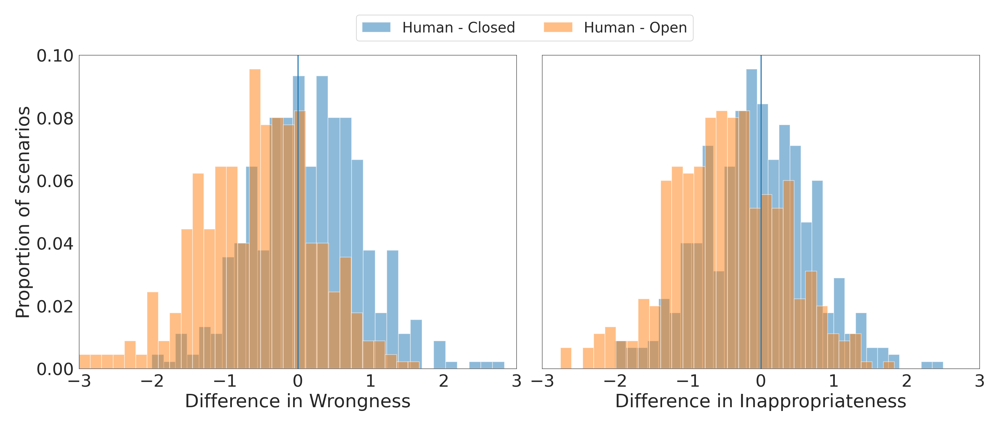

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

# ---------- Weights (for proportions) ----------
n = len(df_diff)

weights_closed_wrong = np.ones(len(df_diff['diff_human_closed_wrong'])) / n
weights_open_wrong   = np.ones(len(df_diff['diff_human_open_wrong'])) / n

weights_closed_inappr = np.ones(len(df_diff['diff_human_closed_inappr'])) / n
weights_open_inappr   = np.ones(len(df_diff['diff_human_open_inappr'])) / n

# ---------- Plot 1: Wrongness ----------
h1 = axes[0].hist(
    df_diff['diff_human_closed_wrong'],
    bins=30,
    alpha=0.5,
    weights=weights_closed_wrong,
    label='Human - Closed'
)

h2 = axes[0].hist(
    df_diff['diff_human_open_wrong'],
    bins=30,
    alpha=0.5,
    weights=weights_open_wrong,
    label='Human - Open'
)

axes[0].axvline(0)

axes[0].set_xlim(-3, 3)
axes[0].set_ylim(0, 0.15)

axes[0].set_xticks(np.arange(-3, 4, 1))
axes[0].set_yticks(np.arange(0, 0.151, 0.02))

axes[0].set_xlabel("Difference in Wrongness", fontsize=26)
axes[0].set_ylabel("Proportion of scenarios", fontsize=26)
axes[0].tick_params(axis='both', labelsize=24)

# ---------- Plot 2: Inappropriateness ----------
axes[1].hist(
    df_diff['diff_human_closed_inappr'],
    bins=30,
    alpha=0.5,
    weights=weights_closed_inappr
)

axes[1].hist(
    df_diff['diff_human_open_inappr'],
    bins=30,
    alpha=0.5,
    weights=weights_open_inappr
)

axes[1].axvline(0)

axes[1].set_xlim(-3, 3)
axes[1].set_ylim(0, 0.1)

axes[1].set_xticks(np.arange(-3, 4, 1))
axes[1].set_yticks(np.arange(0, 0.101, 0.02))

axes[1].set_xlabel("Difference in Inappropriateness", fontsize=26)
axes[1].tick_params(axis='both', labelsize=24)

# ---------- Shared legend ----------
legend_x = 0.63  # adjust this to move left/right
legend_y = 1.00 # adjust up/down

fig.legend(
    handles=[h1[2][0], h2[2][0]],
    labels=['Human - Closed', 'Human - Open'],
    loc='upper center',
    bbox_to_anchor=(legend_x, legend_y),
    ncol=2,
    fontsize=20
)

plt.tight_layout(rect=[0, 0, 1.2, 0.92])
plt.show()

# LLM Benchmarking

## Emotion

In [71]:
SELF_REG = {"shame", "guilt", "embarrassment"}
OTHER_REG = {"contempt", "anger", "disgust"}

def normalize_list(lst):
    if not isinstance(lst, list):
        return []
    out = []
    for x in lst:
        if pd.isna(x):
            continue
        out.append(str(x).strip().lower())
    return out

def has_self_reg(lst):
    lst = normalize_list(lst)
    return int(any(e in SELF_REG for e in lst))

def has_other_reg(lst):
    lst = normalize_list(lst)
    return int(any(e in OTHER_REG for e in lst))

def get_inner_list(x, idx):
    if not isinstance(x, list) or len(x) <= idx:
        return []
    inner = x[idx]
    if not isinstance(inner, list):
        return []
    return inner

df = df_clean.loc[~df_clean['ID'].isin(ids_one_raters)].copy()

# Actor: check self_emotion_list for self-focused emotions
df["actor_label"] = df["self_emotion_list"].apply(has_self_reg)

# Friend / acquaintance / stranger: check corresponding inner list for other-focused emotions
df["friend_label"] = df["other_emotion_list"].apply(
    lambda x: has_other_reg(get_inner_list(x, 0))
)

df["acq_label"] = df["other_emotion_list"].apply(
    lambda x: has_other_reg(get_inner_list(x, 1))
)

df["stranger_label"] = df["other_emotion_list"].apply(
    lambda x: has_other_reg(get_inner_list(x, 2))
)

### True Consensus

#### LLM Evaluation

In [72]:
df_human_only = df.loc[df["rater_group"] == "human"].copy()

IDs = sorted(df_human_only["ID"].astype(int).unique())

label_cols = {
    "actor": "actor_label",
    "friend": "friend_label",
    "acq": "acq_label",
    "stranger": "stranger_label",
}

# Aggregate to one row per (human_id, ID)
df_agg = (
    df_human_only
    .groupby(["human_id", "ID"])[list(label_cols.values())]
    .max()  # "yes" if they said yes for either gender version
    .reset_index()
)

consensus_results = {}

for name, col in label_cols.items():
    # Count how many annotators selected this emotion (label=1) per ID
    label_counts = df_agg.groupby("ID")[col].sum().reindex(IDs, fill_value=0)

    # Count total annotators per ID
    n_annotators = df_agg.groupby("ID")[col].count().reindex(IDs, fill_value=0)

    # Consensus = majority voted "selected" (more than half)
    consensus_results[name] = (label_counts > n_annotators / 2).astype(int)

actor_consensus = consensus_results["actor"]
friend_consensus = consensus_results["friend"]
acq_consensus = consensus_results["acq"]
stranger_consensus = consensus_results["stranger"]

actor_X = actor_consensus.values
friend_X = friend_consensus.values
acq_X = acq_consensus.values
stranger_X = stranger_consensus.values

# --------------------------------
# Outputs for comparison to LLMs
# --------------------------------
human_self_X = actor_consensus.values

human_other_X = np.column_stack([
    friend_consensus.values,
    acq_consensus.values,
    stranger_consensus.values,
])

human_consensus_df = pd.DataFrame({
    "ID": IDs,
    "actor_selfreg_consensus": actor_consensus.values,
    "friend_otherreg_consensus": friend_consensus.values,
    "acq_otherreg_consensus": acq_consensus.values,
    "stranger_otherreg_consensus": stranger_consensus.values,
})
human_consensus_df

,ID,actor_selfreg_consensus,friend_otherreg_consensus,acq_otherreg_consensus,stranger_otherreg_consensus
0,1,1,0,0,0
1,2,1,1,1,1
2,3,1,0,0,0
3,4,1,1,0,1
4,5,1,1,0,1
...,...,...,...,...,...
437,447,1,1,1,1
438,448,1,1,1,1
439,449,0,0,0,0
440,450,1,1,1,1


In [73]:
llm_df = df[df["rater_group"] != "human"].copy()

llm_agg = (
    llm_df
    .groupby(["label_type", "ID"])[
        ["actor_label", "friend_label", "acq_label", "stranger_label"]
    ]
    .max()   # union
    .reset_index()
)

llm_agg

,label_type,ID,actor_label,friend_label,acq_label,stranger_label
0,claude,1,1,1,1,1
1,claude,2,0,0,1,0
2,claude,3,0,0,0,0
3,claude,4,0,1,0,0
4,claude,5,0,1,1,0
...,...,...,...,...,...,...
2647,llama,447,1,1,1,1
2648,llama,448,1,1,1,1
2649,llama,449,0,0,0,0
2650,llama,450,1,1,1,1


In [74]:
human_consensus_df = human_consensus_df.rename(columns={
    "actor_selfreg_consensus": "actor_label",
    "friend_otherreg_consensus": "friend_label",
    "acq_otherreg_consensus": "acq_label",
    "stranger_otherreg_consensus": "stranger_label"
})

merged = llm_agg.merge(
    human_consensus_df,
    on="ID",
    suffixes=("_llm", "_human")
)

In [75]:
categories = ["actor", "friend", "acq", "stranger"]

def compute_metrics(y_true, y_pred):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }

def bootstrap_ci_with_significance(y_true_dict, y_pred_dict, n_boot=2000, ci=95, seed=42):
    rng = np.random.RandomState(seed)
    model_names = list(y_true_dict.keys())

    boot_distributions = {}

    for model in model_names:
        yt_vals = y_true_dict[model].values
        yp_vals = y_pred_dict[model].values
        n = len(yt_vals)

        idx_matrix = rng.choice(n, size=(n_boot, n), replace=True)
        yt = yt_vals[idx_matrix]
        yp = yp_vals[idx_matrix]

        accuracy = (yt == yp).mean(axis=1)

        pos_label = 1
        tp = ((yp == pos_label) & (yt == pos_label)).sum(axis=1).astype(float)
        fp = ((yp == pos_label) & (yt != pos_label)).sum(axis=1).astype(float)
        fn = ((yp != pos_label) & (yt == pos_label)).sum(axis=1).astype(float)

        # Safe division — avoid divide-by-zero
        prec_denom = tp + fp
        rec_denom = tp + fn
        prec = np.divide(tp, prec_denom, out=np.zeros_like(tp), where=prec_denom > 0)
        rec = np.divide(tp, rec_denom, out=np.zeros_like(tp), where=rec_denom > 0)
        f1_denom = prec + rec
        f1 = np.divide(2 * prec * rec, f1_denom, out=np.zeros_like(prec), where=f1_denom > 0)

        boot_distributions[model] = {
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "accuracy": accuracy,
        }

    lower = (100 - ci) / 2
    upper = 100 - lower

    results = {}
    for model in model_names:
        results[model] = {}
        for metric in ["precision", "recall", "f1", "accuracy"]:
            model_dist = boot_distributions[model][metric]

            others = [boot_distributions[m][metric] for m in model_names if m != model]
            group_mean_dist = np.mean(others, axis=0)

            diff_dist = model_dist - group_mean_dist

            observed_diff = np.mean(model_dist) - np.mean(group_mean_dist)
            if observed_diff >= 0:
                p_val = (np.sum(diff_dist <= 0) + 1) / (n_boot + 1)
            else:
                p_val = (np.sum(diff_dist >= 0) + 1) / (n_boot + 1)
            p_val = min(p_val * 2, 1.0)

            results[model][f"{metric}_ci_lo"] = np.percentile(model_dist, lower)
            results[model][f"{metric}_ci_hi"] = np.percentile(model_dist, upper)
            results[model][f"{metric}_p"] = p_val

    return results

# Bootstrap CI only (no significance)
def bootstrap_ci_only(y_true, y_pred, n_boot=2000, ci=95, seed=42):
    rng = np.random.RandomState(seed)
    yt_vals = y_true.values if hasattr(y_true, 'values') else np.array(y_true)
    yp_vals = y_pred.values if hasattr(y_pred, 'values') else np.array(y_pred)
    n = len(yt_vals)

    idx_matrix = rng.choice(n, size=(n_boot, n), replace=True)
    yt = yt_vals[idx_matrix]
    yp = yp_vals[idx_matrix]

    accuracy = (yt == yp).mean(axis=1)

    tp = ((yp == 1) & (yt == 1)).sum(axis=1).astype(float)
    fp = ((yp == 1) & (yt != 1)).sum(axis=1).astype(float)
    fn = ((yp != 1) & (yt == 1)).sum(axis=1).astype(float)

    prec_denom = tp + fp
    rec_denom = tp + fn
    prec = np.divide(tp, prec_denom, out=np.zeros_like(tp), where=prec_denom > 0)
    rec = np.divide(tp, rec_denom, out=np.zeros_like(tp), where=rec_denom > 0)
    f1_denom = prec + rec
    f1 = np.divide(2 * prec * rec, f1_denom, out=np.zeros_like(prec), where=f1_denom > 0)

    lower = (100 - ci) / 2
    upper = 100 - lower

    result = {}
    for metric_name, dist in [("precision", prec), ("recall", rec), ("f1", f1), ("accuracy", accuracy)]:
        result[f"{metric_name}_ci_lo"] = np.percentile(dist, lower)
        result[f"{metric_name}_ci_hi"] = np.percentile(dist, upper)
        result[f"{metric_name}_p"] = np.nan
    return result

human_annotators = df_agg["human_id"].unique()
human_results = []

for cat in categories:
    col = label_cols[cat]

    all_preds = []
    all_truths = []

    for annotator in human_annotators:
        ann_df = df_agg[df_agg["human_id"] == annotator].set_index("ID")[col]
        others_df = df_agg[df_agg["human_id"] != annotator]

        label_counts = others_df.groupby("ID")[col].sum()
        n_others = others_df.groupby("ID")[col].count()
        loo_consensus = (label_counts > n_others / 2).astype(int)

        shared_ids = sorted(set(ann_df.index) & set(loo_consensus.index))

        all_preds.append(ann_df.loc[shared_ids].values)
        all_truths.append(loo_consensus.loc[shared_ids].values)

    y_pred_human = pd.Series(np.concatenate(all_preds))
    y_true_human = pd.Series(np.concatenate(all_truths))

    metrics = compute_metrics(y_true_human, y_pred_human)
    boot_ci = bootstrap_ci_only(y_true_human, y_pred_human)

    human_results.append({
        "label_type": "human",
        "category": cat,
        **metrics,
        **boot_ci,
    })

human_baseline_df = pd.DataFrame(human_results)  # fixed: was human_loo_results

# Full results pipeline
model_order = ["claude", "gemini", "gpt_5.2", "gpt_oss", "llama", "gemma"]

results = []

for cat in categories:
    y_true_dict = {}
    y_pred_dict = {}

    for label_type in model_order:
        df_sub = merged[merged["label_type"] == label_type]
        y_true_dict[label_type] = df_sub[f"{cat}_label_human"]
        y_pred_dict[label_type] = df_sub[f"{cat}_label_llm"]

    boot_results = bootstrap_ci_with_significance(y_true_dict, y_pred_dict)

    for label_type in model_order:
        df_sub = merged[merged["label_type"] == label_type]
        y_true = df_sub[f"{cat}_label_human"]
        y_pred = df_sub[f"{cat}_label_llm"]
        metrics = compute_metrics(y_true, y_pred)

        results.append({
            "label_type": label_type,
            "category": cat,
            **metrics,
            **boot_results[label_type],
        })

results_df = pd.DataFrame(results)
results_df = pd.concat([results_df, human_baseline_df], ignore_index=True)
results_df

,label_type,category,precision,recall,f1,accuracy,precision_ci_lo,precision_ci_hi,precision_p,recall_ci_lo,recall_ci_hi,recall_p,f1_ci_lo,f1_ci_hi,f1_p,accuracy_ci_lo,accuracy_ci_hi,accuracy_p
0,claude,actor,0.878788,0.717314,0.789883,0.755656,0.831897,0.919292,0.001000,0.662856,0.768684,0.001000,0.747322,0.828573,0.486757,0.712670,0.794118,0.213893
1,gemini,actor,0.800000,0.862191,0.829932,0.773756,0.753204,0.844666,0.134933,0.818859,0.900356,0.504748,0.795138,0.860001,0.074963,0.733032,0.809955,0.022989
2,gpt_5.2,actor,0.762763,0.897527,0.824675,0.755656,0.716012,0.807343,0.779610,0.860804,0.932144,0.007996,0.788396,0.857143,0.158921,0.714932,0.796380,0.232884
3,gpt_oss,actor,0.703081,0.886926,0.784375,0.687783,0.657208,0.751398,0.003998,0.846974,0.921710,0.038981,0.748018,0.818324,0.255872,0.644796,0.730769,0.033983
4,llama,actor,0.749196,0.823322,0.784512,0.710407,0.702530,0.795471,0.426787,0.779410,0.864874,0.198901,0.748654,0.819238,0.309845,0.669683,0.753394,0.288856
5,gemma,actor,0.715877,0.908127,0.800623,0.710407,0.669420,0.765371,0.027986,0.873286,0.940300,0.002999,0.766296,0.834604,0.954523,0.667421,0.753394,0.289855
6,claude,friend,0.721003,0.867925,0.787671,0.719457,0.670640,0.768987,0.061969,0.824885,0.907960,0.002999,0.749103,0.822559,0.546727,0.676471,0.760181,0.064968
7,gemini,friend,0.740864,0.841509,0.787986,0.728507,0.692567,0.790173,0.006997,0.797605,0.882359,0.001000,0.749989,0.822526,0.528736,0.687783,0.769231,0.019990
8,gpt_5.2,friend,0.657143,0.954717,0.778462,0.674208,0.611825,0.703130,0.357821,0.927201,0.977186,0.011994,0.743825,0.811558,0.916542,0.633428,0.714932,0.665667
9,gpt_oss,friend,0.628641,0.977358,0.765140,0.640271,0.580334,0.675677,0.031984,0.958015,0.992728,0.001000,0.727266,0.799453,0.447776,0.595023,0.685520,0.049975


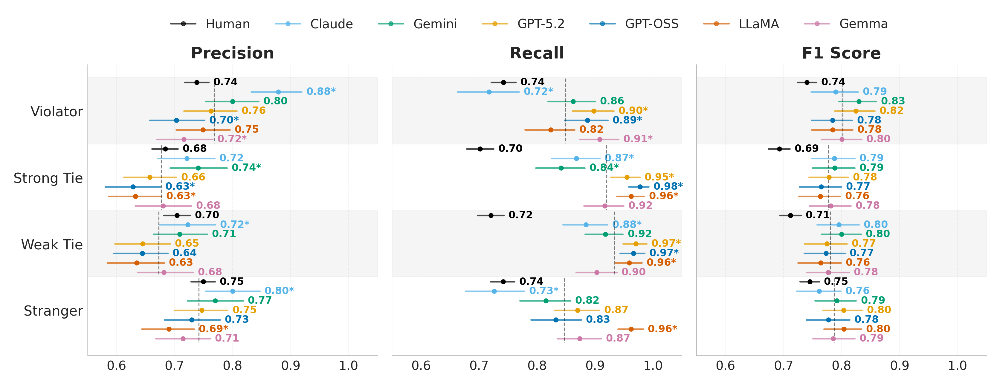

In [76]:
FONT_SIZE = 24
FIG_WIDTH = 22
FIG_HEIGHT = 8

metrics = ["precision", "recall", "f1"]
metric_titles = ["Precision", "Recall", "F1 Score"]
categories = ["actor", "friend", "acq", "stranger"]
cat_labels = ["Violator", "Strong Tie", "Weak Tie", "Stranger"]

model_order = ["claude", "gemini", "gpt_5.2", "gpt_oss", "llama", "gemma"]
model_labels = ["Claude", "Gemini", "GPT-5.2", "GPT-OSS", "LLaMA", "Gemma"]

colors = {
    "claude": "#56B4E9",
    "gemini": "#009E73",
    "gpt_5.2": "#E69F00",
    "gpt_oss": "#0072B2",
    "llama": "#D55E00",
    "gemma": "#CC79A7",
    "human": "#000000",
}

all_order = ["human", "claude", "gemini", "gpt_5.2", "gpt_oss", "llama", "gemma"]
all_labels = ["Human", "Claude", "Gemini", "GPT-5.2", "GPT-OSS", "LLaMA", "Gemma"]

def sig_stars(p):
    if np.isnan(p): return ""
    # if p < 0.001: return "***"
    # if p < 0.01: return "**"
    if p < 0.05: return "*"
    return ""

fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH, FIG_HEIGHT), sharey=True)

n_all = len(all_order)
n_cats = len(categories)

for ax_idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
    ax = axes[ax_idx]

    for cat_idx, (cat, cat_label) in enumerate(zip(categories, cat_labels)):
        if cat_idx % 2 == 0:
            ax.axhspan(
                cat_idx * n_all - 0.5,
                cat_idx * n_all + n_all - 0.5,
                color='grey', alpha=0.08
            )

        for model_idx, (model, model_label) in enumerate(zip(all_order, all_labels)):
            row = results_df[
                (results_df["label_type"] == model) &
                (results_df["category"] == cat)
            ]

            val = row[metric].values[0]
            lo = row[f"{metric}_ci_lo"].values[0]
            hi = row[f"{metric}_ci_hi"].values[0]

            y_pos = cat_idx * n_all + model_idx

            ax.plot(
                [lo, hi], [y_pos, y_pos],
                color=colors[model], linewidth=2.5, alpha=0.7,
                solid_capstyle='round'
            )
            ax.plot(
                val, y_pos, 'o',
                color=colors[model], markersize=7, zorder=5,
                label=model_label if (ax_idx == 0 and cat_idx == 0) else None
            )
            stars = sig_stars(row[f"{metric}_p"].values[0])
            label_text = f"{val:.2f}{stars}"
            ax.text(
                hi + 0.008, y_pos, label_text,
                va='center', ha='left',
                fontsize=FONT_SIZE - 8, color=colors[model], fontweight='bold'
            )

        # LLM average dashed line (excluding human)
        cat_vals = []
        for model in model_order:
            row = results_df[
                (results_df["label_type"] == model) &
                (results_df["category"] == cat)
            ]
            cat_vals.append(row[metric].values[0])

        avg_val = np.mean(cat_vals)
        y_top = cat_idx * n_all - 0.4
        y_bot = cat_idx * n_all + n_all - 0.6

        ax.plot(
            [avg_val, avg_val], [y_top, y_bot],
            color='black', linewidth=1.5, linestyle='--', alpha=0.5, zorder=4
        )

    ytick_positions = [cat_idx * n_all + (n_all - 1) / 2 for cat_idx in range(n_cats)]
    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(cat_labels, fontsize=FONT_SIZE - 2)
    ax.invert_yaxis()

    ax.set_xlim(0.55, 1.05)
    ax.set_title(title, fontsize=FONT_SIZE + 2, fontweight='bold', pad=10)
    ax.tick_params(axis='x', labelsize=FONT_SIZE - 4)
    ax.grid(axis='x', alpha=0.25, linestyle='--', linewidth=0.8)
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

legend_handles = []
for model, model_label in zip(all_order, all_labels):
    legend_handles.append(
        Line2D([0], [0], color=colors[model], marker='o', markersize=7,
               linewidth=2.5, alpha=0.7, label=model_label)
    )

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.53, 1.04),
    ncol=n_all,
    fontsize=FONT_SIZE - 4,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Individual Emotions

In [77]:
emotion_names = [
    "Shame",
    "Guilt",
    "Embarrassment",
    "Contempt",
    "Disgust",
    "Anger",
    "Pride",
    "Compassion",
]

IDs = sorted(df["ID"].astype(int).unique())

# Explode and deduplicate per (human_id, ID, emotion)
human_self_long = (
    df.loc[df["label_type"] == "human", ["ID", "human_id", "self_emotion_list"]]
    .explode("self_emotion_list")
    .rename(columns={"self_emotion_list": "emotion"})
)

human_self_long = human_self_long.dropna(subset=["emotion"])
human_self_long = human_self_long.drop_duplicates(subset=["ID", "human_id", "emotion"])

# Count distinct annotators per emotion per ID
human_self_counts = (
    human_self_long
    .groupby(["ID", "emotion"])["human_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(index=IDs, columns=emotion_names, fill_value=0)
)

# Count unique annotators per ID (also deduplicated across gender)
n_annotators_per_id = (
    df.loc[df["label_type"] == "human"]
    .drop_duplicates(subset=["ID", "human_id"])
    .groupby("ID")["human_id"]
    .nunique()
    .reindex(IDs, fill_value=0)
)

# Consensus
human_self_X = (
    human_self_counts.gt(n_annotators_per_id / 2, axis=0)
    .astype(int)
    .values
)
human_self_X

array([[0, 1, 0, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 1, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 0, 1, ..., 0, 0, 0]])

In [78]:
tie_map = {
    0: "friend",
    1: "acquaintance",
    2: "stranger"
}

def expand_other(row):
    rows = []
    for tie_idx, emotions in enumerate(row["other_emotion_list"]):
        if isinstance(emotions, list):
            for emo in emotions:
                rows.append({
                    "ID": row["ID"],
                    "human_id": row["human_id"],
                    "tie_type": tie_map.get(tie_idx),
                    "emotion": emo
                })
    return rows

human_df = df.loc[df["label_type"] == "human"].copy()
human_other_long = pd.DataFrame(
    [
        item
        for _, row in human_df.iterrows()
        for item in expand_other(row)
    ]
)

# Clean and dedup per (human_id, ID, tie_type, emotion)
human_other_long = human_other_long.dropna(subset=["emotion"])
human_other_long = human_other_long.drop_duplicates(
    subset=["ID", "human_id", "tie_type", "emotion"]
)

# Count distinct annotators per (ID, tie_type, emotion)
human_other_counts = (
    human_other_long
    .groupby(["ID", "tie_type", "emotion"])["human_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=emotion_names, fill_value=0)
)

# Count unique annotators per (ID, tie_type) — deduplicated across gender
n_annotators_per_id_tie = (
    human_df
    .drop_duplicates(subset=["ID", "human_id"])
    .assign(tie_types=lambda x: [list(tie_map.values())] * len(x))
    .explode("tie_types")
    .rename(columns={"tie_types": "tie_type"})
    .groupby(["ID", "tie_type"])["human_id"]
    .nunique()
)

# Align annotator counts to the same index as human_other_counts
n_aligned = n_annotators_per_id_tie.reindex(human_other_counts.index, fill_value=0)

# Apply majority consensus
human_other_binary = (
    human_other_counts.gt(n_aligned / 2, axis=0)
    .astype(int)
    .reset_index()
)

def build_matrix(df, tie):
    return (
        df[df["tie_type"] == tie]
        .set_index("ID")[emotion_names]
        .reindex(index=IDs, fill_value=0)
        .values
    )

human_friend_X = build_matrix(human_other_binary, "friend")
human_acquaintance_X = build_matrix(human_other_binary, "acquaintance")
human_stranger_X = build_matrix(human_other_binary, "stranger")
human_other_binary

emotion,ID,tie_type,Shame,Guilt,Embarrassment,Contempt,Disgust,Anger,Pride,Compassion
0,1,acquaintance,0,0,0,0,0,0,0,0
1,1,friend,0,0,0,0,0,0,0,0
2,1,stranger,0,0,0,0,0,0,0,0
3,2,acquaintance,0,0,0,0,1,0,0,0
4,2,friend,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1321,450,friend,1,0,1,1,1,1,0,0
1322,450,stranger,0,0,0,1,1,1,0,0
1323,451,acquaintance,0,0,0,0,1,0,0,0
1324,451,friend,0,0,0,0,1,0,0,0


In [79]:
# LLMs — union across gender variants
llm_labels = ["claude", "gemini", "gpt_5.2", "gpt_oss", "llama", "gemma"]
llm_self_X = {}

for label in llm_labels:
    llm_sub = df.loc[df["label_type"] == label, ["ID", "self_emotion_list"]]

    llm_long = (
        llm_sub
        .explode("self_emotion_list")
        .rename(columns={"self_emotion_list": "emotion"})
    )
    llm_long = llm_long.dropna(subset=["emotion"])
    llm_long = llm_long.drop_duplicates(subset=["ID", "emotion"])

    # If any row for this ID has the emotion, it's present (union)
    llm_presence = (
        llm_long
        .groupby(["ID", "emotion"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=IDs, columns=emotion_names, fill_value=0)
        .gt(0)
        .astype(int)
        .values
    )

    llm_self_X[label] = llm_presence

In [80]:
tie_map = {
    0: "friend",
    1: "acquaintance",
    2: "stranger"
}

def expand_other_llm(row):
    rows = []
    for tie_idx, emotions in enumerate(row["other_emotion_list"]):
        if isinstance(emotions, list):
            for emo in emotions:
                rows.append({
                    "ID": row["ID"],
                    "tie_type": tie_map.get(tie_idx),
                    "emotion": emo
                })
    return rows

llm_labels = ["claude", "gemini", "gpt_5.2", "gpt_oss", "llama", "gemma"]

llm_friend_X = {}
llm_acquaintance_X = {}
llm_stranger_X = {}

for label in llm_labels:
    llm_sub = df.loc[df["label_type"] == label].copy()

    llm_other_long = pd.DataFrame(
        [
            item
            for _, row in llm_sub.iterrows()
            for item in expand_other_llm(row)
        ]
    )

    llm_other_long = llm_other_long.dropna(subset=["emotion"])
    llm_other_long = llm_other_long.drop_duplicates(subset=["ID", "tie_type", "emotion"])

    llm_other_binary = (
        llm_other_long
        .groupby(["ID", "tie_type", "emotion"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=emotion_names, fill_value=0)
        .gt(0)
        .astype(int)
        .reset_index()
    )

    def build_matrix(df_bin, tie):
        return (
            df_bin[df_bin["tie_type"] == tie]
            .set_index("ID")[emotion_names]
            .reindex(index=IDs, fill_value=0)
            .values
        )

    llm_friend_X[label] = build_matrix(llm_other_binary, "friend")
    llm_acquaintance_X[label] = build_matrix(llm_other_binary, "acquaintance")
    llm_stranger_X[label] = build_matrix(llm_other_binary, "stranger")

In [81]:
# Map category to human and LLM matrices
human_matrices = {
    "self": human_self_X,
    "friend": human_friend_X,
    "acquaintance": human_acquaintance_X,
    "stranger": human_stranger_X,
}

llm_matrices = {
    "self": llm_self_X,
    "friend": llm_friend_X,
    "acquaintance": llm_acquaintance_X,
    "stranger": llm_stranger_X,
}

results = []

for cat in ["self", "friend", "acquaintance", "stranger"]:
    h_matrix = human_matrices[cat]

    for emo_idx, emo_name in enumerate(emotion_names):
        # Collect all models' y_true and y_pred for this category + emotion
        y_true_dict = {}
        y_pred_dict = {}
        metrics_dict = {}

        for label in llm_labels:
            l_matrix = llm_matrices[cat][label]

            y_true = pd.Series(h_matrix[:, emo_idx])
            y_pred = pd.Series(l_matrix[:, emo_idx])

            y_true_dict[label] = y_true
            y_pred_dict[label] = y_pred
            metrics_dict[label] = compute_metrics(y_true.values, y_pred.values)

        # Bootstrap with significance for all models together
        boot_results = bootstrap_ci_with_significance(y_true_dict, y_pred_dict)

        for label in llm_labels:
            results.append({
                "category": cat,
                "label_type": label,
                "emotion": emo_name,
                **metrics_dict[label],
                **boot_results[label],
            })

results_emotion_df = pd.DataFrame(results)
results_emotion_df

,category,label_type,emotion,precision,recall,f1,accuracy,precision_ci_lo,precision_ci_hi,precision_p,recall_ci_lo,recall_ci_hi,recall_p,f1_ci_lo,f1_ci_hi,f1_p,accuracy_ci_lo,accuracy_ci_hi,accuracy_p
0,self,claude,Shame,0.577778,0.577778,0.577778,0.742081,0.496123,0.656500,0.007996,0.495732,0.660722,0.001000,0.505747,0.645614,0.766617,0.699095,0.780543,0.001000
1,self,gemini,Shame,0.564706,0.711111,0.629508,0.744344,0.485030,0.636389,0.019990,0.633320,0.789939,0.610695,0.562262,0.692088,0.054973,0.703620,0.785068,0.001000
2,self,gpt_5.2,Shame,0.537313,0.800000,0.642857,0.728507,0.470899,0.606383,0.054973,0.727273,0.866678,0.041979,0.581454,0.701160,0.007996,0.687783,0.771493,0.001000
3,self,gpt_oss,Shame,0.402135,0.837037,0.543269,0.570136,0.345193,0.459856,0.008996,0.774436,0.896296,0.001000,0.484108,0.600452,0.401799,0.524887,0.615385,0.001000
4,self,llama,Shame,0.410359,0.762963,0.533679,0.592760,0.346937,0.473035,0.025987,0.688877,0.832062,0.304848,0.469070,0.590337,0.230885,0.547511,0.640271,0.006997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,stranger,gemini,Compassion,0.142857,0.294118,0.192308,0.809955,0.066667,0.229756,0.091954,0.151515,0.457173,0.434783,0.094118,0.294737,0.825587,0.773699,0.846154,0.018991
188,stranger,gpt_5.2,Compassion,0.093458,0.294118,0.141844,0.726244,0.042355,0.153170,0.001000,0.142857,0.444444,0.462769,0.066222,0.222259,0.139930,0.683258,0.769231,0.001000
189,stranger,gpt_oss,Compassion,0.363636,0.117647,0.177778,0.916290,0.071429,0.666667,0.307846,0.024390,0.242424,0.034983,0.040816,0.333333,0.702649,0.889140,0.941176,0.001000
190,stranger,llama,Compassion,0.259259,0.205882,0.229508,0.893665,0.096774,0.434783,0.712644,0.074977,0.357143,0.550725,0.084478,0.363712,0.694653,0.861991,0.920814,0.001000


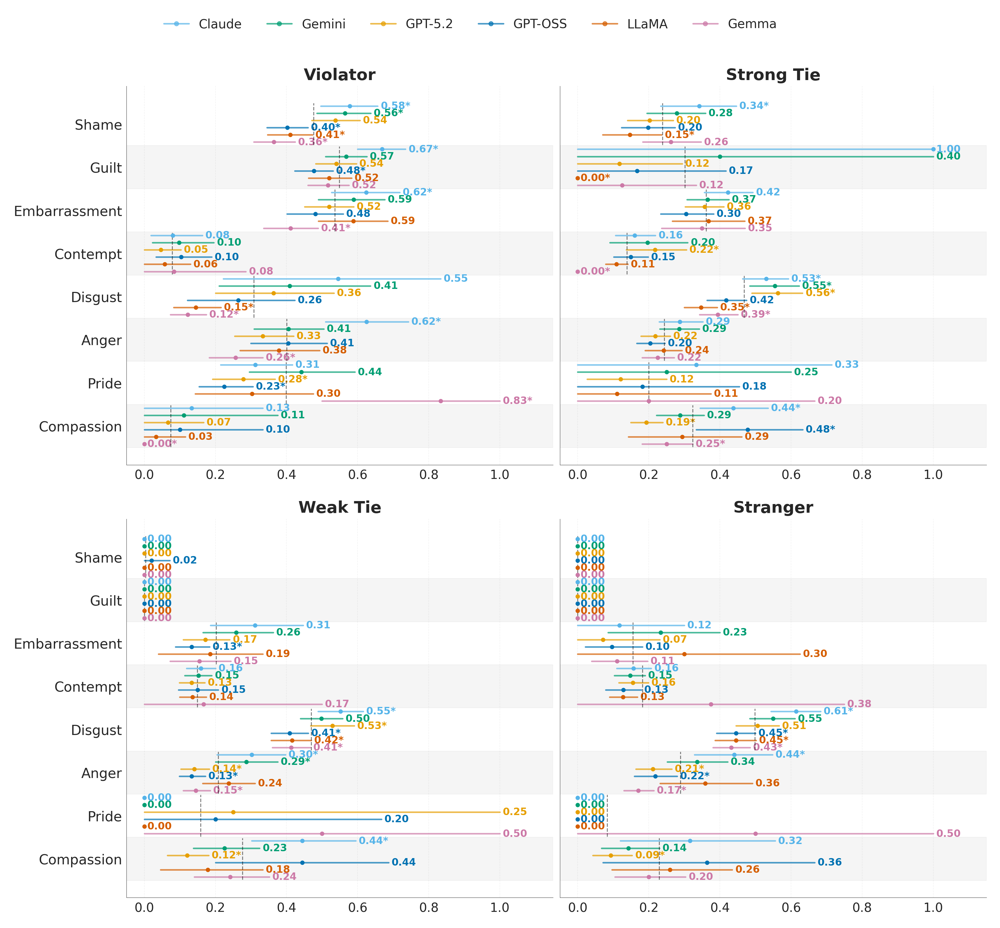

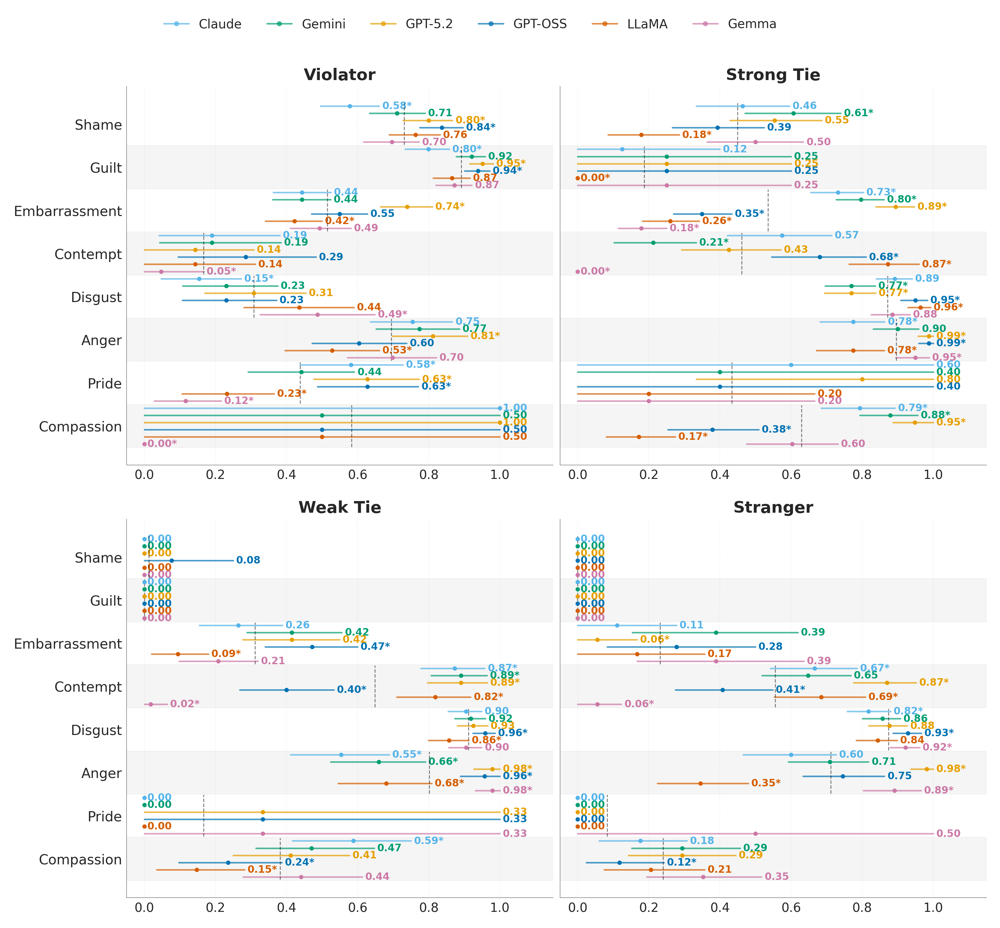

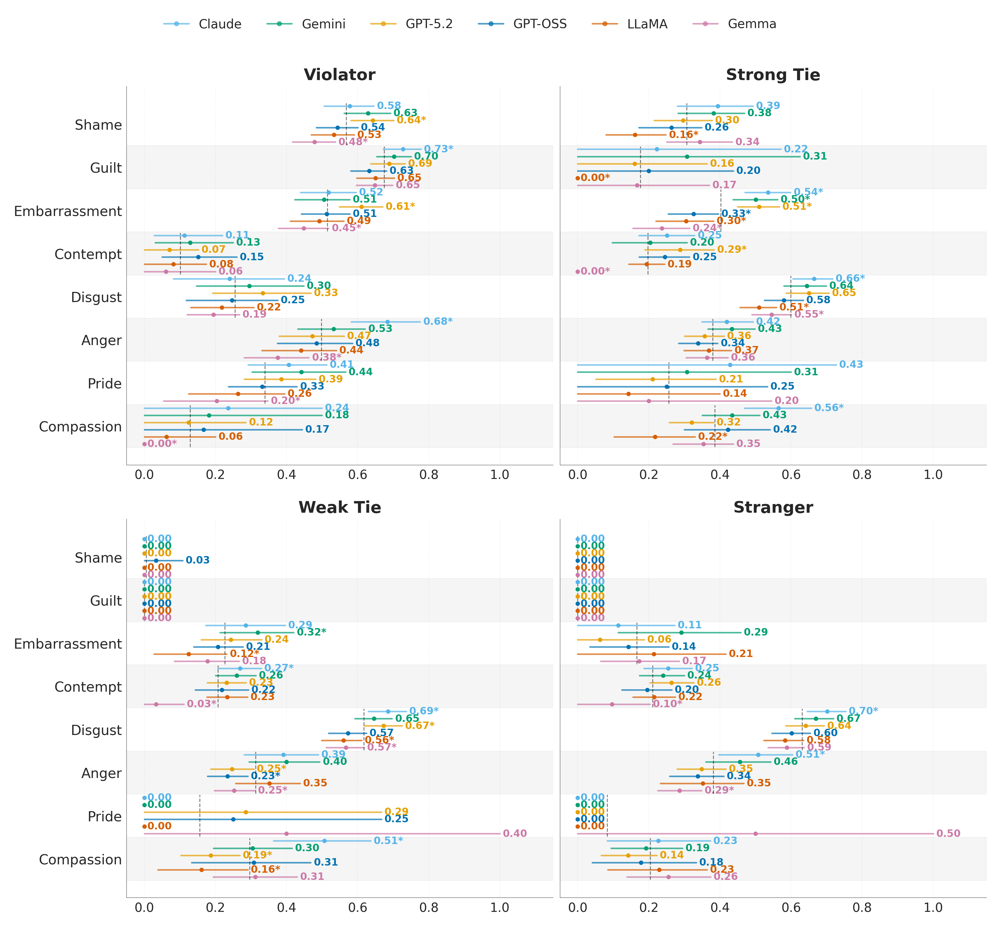

In [82]:
FONT_SIZE = 24
FIG_WIDTH = 22
FIG_HEIGHT = 10

categories = ["self", "friend", "acquaintance", "stranger"]
cat_labels = ["Violator", "Strong Tie", "Weak Tie", "Stranger"]

model_order = ["claude", "gemini", "gpt_5.2", "gpt_oss", "llama", "gemma"]
model_labels = ["Claude", "Gemini", "GPT-5.2", "GPT-OSS", "LLaMA", "Gemma"]

colors = {
    "claude": "#56B4E9",
    "gemini": "#009E73",
    "gpt_5.2": "#E69F00",
    "gpt_oss": "#0072B2",
    "llama": "#D55E00",
    "gemma": "#CC79A7",
}

emotion_names = [
    "Shame", "Guilt", "Embarrassment",
    "Contempt", "Disgust", "Anger",
    "Pride", "Compassion",
]

n_models = len(model_order)
n_emotions = len(emotion_names)

metrics = ["precision", "recall", "f1"]
metric_titles = ["Precision", "Recall", "F1 Score"]

for metric, metric_title in zip(metrics, metric_titles):

    fig, axes = plt.subplots(2, 2, figsize=(FIG_WIDTH, FIG_HEIGHT * 2), sharey=True)
    axes = axes.flatten()

    for ax_idx, (cat, cat_label) in enumerate(zip(categories, cat_labels)):
        ax = axes[ax_idx]

        for emo_idx, emo_name in enumerate(reversed(emotion_names)):
            if emo_idx % 2 == 0:
                ax.axhspan(
                    emo_idx * n_models - 0.5,
                    emo_idx * n_models + n_models - 0.5,
                    color='grey', alpha=0.08
                )

            # Collect values for average line
            cat_vals = []

            for model_idx, (model, model_label) in enumerate(zip(model_order[::-1], model_labels[::-1])):
                row = results_emotion_df[
                    (results_emotion_df["label_type"] == model) &
                    (results_emotion_df["category"] == cat) &
                    (results_emotion_df["emotion"] == emo_name)
                ]

                if len(row) == 0:
                    continue

                val = row[metric].values[0]
                lo = row[f"{metric}_ci_lo"].values[0]
                hi = row[f"{metric}_ci_hi"].values[0]
                cat_vals.append(val)

                y_pos = emo_idx * n_models + model_idx

                ax.plot(
                    [lo, hi], [y_pos, y_pos],
                    color=colors[model], linewidth=2.5, alpha=0.7,
                    solid_capstyle='round'
                )
                ax.plot(
                    val, y_pos, 'o',
                    color=colors[model], markersize=6, zorder=5,
                    label=model_label if (ax_idx == 0 and emo_idx == 0) else None
                )
                stars = sig_stars(row[f"{metric}_p"].values[0])
                label_text = f"{val:.2f}{stars}"
                ax.text(
                    hi + 0.008, y_pos, label_text,
                    va='center', ha='left',
                    fontsize=FONT_SIZE - 8, color=colors[model], fontweight='bold'
                )

            # Average line per emotion group
            if cat_vals:
                avg_val = np.mean(cat_vals)
                y_top = emo_idx * n_models - 0.4
                y_bot = emo_idx * n_models + n_models - 0.6
                ax.plot(
                    [avg_val, avg_val], [y_top, y_bot],
                    color='black', linewidth=1.5, linestyle='--', alpha=0.5, zorder=4
                )
                # ax.text(
                #     avg_val, y_top - 0.3, f"{avg_val:.2f}",
                #     va='bottom', ha='center',
                #     fontsize=FONT_SIZE - 8, color='black', fontstyle='italic'
                # )

        ytick_positions = [emo_idx * n_models + (n_models - 1) / 2 for emo_idx in range(n_emotions)]
        ax.set_yticks(ytick_positions)
        ax.set_yticklabels(list(reversed(emotion_names)), fontsize=FONT_SIZE - 2)
        # ax.invert_yaxis()

        ax.set_xlim(-0.05, 1.15)
        ax.set_title(cat_label, fontsize=FONT_SIZE + 2, fontweight='bold', pad=10)
        ax.tick_params(axis='x', labelsize=FONT_SIZE - 4)
        ax.grid(axis='x', alpha=0.25, linestyle='--', linewidth=0.8)
        ax.set_axisbelow(True)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.5)
        ax.spines['bottom'].set_linewidth(0.5)

    legend_handles = []
    legend_labels = []
    for model, model_label in zip(model_order, model_labels):
        legend_handles.append(
            Line2D([0], [0], color=colors[model], marker='o', markersize=7,
                   linewidth=2.5, alpha=0.7)
        )
        legend_labels.append(model_label)

    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        loc="upper center",
        bbox_to_anchor=(0.47, 1.02),
        ncol=n_models,
        fontsize=FONT_SIZE - 4,
        frameon=False
    )

    # fig.suptitle(metric_title, fontsize=FONT_SIZE + 4, fontweight='bold', y=1.08)
    fig.savefig(f"emotion_{metric}.png", bbox_inches='tight', dpi=300)
    plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=3)
    plt.show()

##### Emotion Distribution

In [83]:
SELF_EMOTIONS = ['Shame', 'Guilt', 'Embarrassment']
OTHER_EMOTIONS = ['Anger', 'Disgust', 'Contempt']
POSITIVE_EMOTIONS = ['Pride', 'Compassion']
EMOTIONS = major_emotions

def classify_and_count(df, emotions_cols, label):
    """
    df: DataFrame with columns for each emotion (binary 0/1), indexed per stimulus.
    Returns a summary DataFrame with counts and median emotion counts per category.
    """
    results = []

    for _, row in df.iterrows():
        has_self = row[SELF_EMOTIONS].sum() > 0
        has_other = row[OTHER_EMOTIONS].sum() > 0
        has_pos = row[POSITIVE_EMOTIONS].sum() > 0
        has_any = row[SELF_EMOTIONS + OTHER_EMOTIONS + POSITIVE_EMOTIONS].sum() > 0

        self_count = row[SELF_EMOTIONS].sum()
        other_count = row[OTHER_EMOTIONS].sum()
        pos_count = row[POSITIVE_EMOTIONS].sum()

        if not has_any:
            cat = "No Emotion"
        elif has_self and has_other:
            cat = "Both Self + Other"
        elif has_self and not has_other:
            cat = "Self-focused Only"
        elif has_other and not has_self:
            cat = "Other-focused Only"
        elif has_pos and not has_self and not has_other:
            cat = "Positive Only"
        else:
            cat = "Other"

        results.append({
            'category': cat,
            'self_count': self_count,
            'other_count': other_count,
            'pos_count': pos_count,
        })

    res_df = pd.DataFrame(results)

    summary = res_df.groupby('category').agg(
        n_stimuli=('category', 'size'),
        median_self=('self_count', 'median'),
        median_other=('other_count', 'median'),
        median_positive=('pos_count', 'median'),
    ).reset_index()

    summary['proportion'] = (summary['n_stimuli'] / 442).round(3)
    summary['perspective'] = label
    return summary

# Actor (from human_self_count)
human_self_df = pd.DataFrame(human_self_X, columns=EMOTIONS)
actor_summary = classify_and_count(human_self_df, EMOTIONS, 'Actor')

# Friend / Acquaintance / Stranger (from human_other_binary)
friend_df = human_other_binary[human_other_binary['tie_type'] == 'friend'].drop(columns=['ID', 'tie_type'])
acq_df = human_other_binary[human_other_binary['tie_type'] == 'acquaintance'].drop(columns=['ID', 'tie_type'])
stranger_df = human_other_binary[human_other_binary['tie_type'] == 'stranger'].drop(columns=['ID', 'tie_type'])

friend_summary = classify_and_count(friend_df, EMOTIONS, 'Friend')
acq_summary = classify_and_count(acq_df, EMOTIONS, 'Acquaintance')
stranger_summary = classify_and_count(stranger_df, EMOTIONS, 'Stranger')

# Combine
full_summary = pd.concat([actor_summary, friend_summary, acq_summary, stranger_summary], ignore_index=True)
full_summary

,category,n_stimuli,median_self,median_other,median_positive,proportion,perspective
0,Both Self + Other,45,1.0,1.0,1.0,0.102,Actor
1,No Emotion,126,0.0,0.0,0.0,0.285,Actor
2,Other-focused Only,71,0.0,1.0,0.0,0.161,Actor
3,Positive Only,11,0.0,0.0,1.0,0.025,Actor
4,Self-focused Only,189,1.0,0.0,1.0,0.428,Actor
5,Both Self + Other,67,1.0,1.0,0.0,0.152,Friend
6,No Emotion,130,0.0,0.0,0.0,0.294,Friend
7,Other-focused Only,115,0.0,1.0,0.0,0.260,Friend
8,Positive Only,52,0.0,0.0,1.0,0.118,Friend
9,Self-focused Only,78,1.0,0.0,0.0,0.176,Friend


### Minor Agreement (>= 2)

In [84]:
emotion_names = [
    "Shame",
    "Guilt",
    "Embarrassment",
    "Contempt",
    "Disgust",
    "Anger",
    "Pride",
    "Compassion",
]

IDs = sorted(df["ID"].astype(int).unique())

human_self_long = (
    df.loc[df["label_type"] == "human", ["ID", "human_id", "self_emotion_list"]]
    .explode("self_emotion_list")
    .rename(columns={"self_emotion_list": "emotion"})
)

human_self_long = human_self_long.dropna(subset=["emotion"])
human_self_long = human_self_long.drop_duplicates(subset=["ID", "human_id", "emotion"])

# count how many distinct annotators selected each emotion for each ID
human_self_counts = (
    human_self_long
    .groupby(["ID", "emotion"])["human_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(index=IDs, columns=emotion_names, fill_value=0)
)

# count total annotators per ID
n_annotators_per_id = (
    df.loc[df["label_type"] == "human"]
    .groupby("ID")["human_id"]
    .nunique()
    .reindex(IDs, fill_value=0)
)

# consensus = majority of annotators selected the emotion
human_self_X = (
    human_self_counts.ge(2, axis=0)
    .astype(int)
    .values
)
human_self_X

array([[0, 1, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 1, 0],
       [1, 1, 1, ..., 1, 0, 0],
       [1, 0, 1, ..., 0, 0, 0]])

In [85]:
tie_map = {
    0: "friend",
    1: "acquaintance",
    2: "stranger"
}

def expand_other(row):
    rows = []
    for tie_idx, emotions in enumerate(row["other_emotion_list"]):
        if isinstance(emotions, list):
            for emo in emotions:
                rows.append({
                    "ID": row["ID"],
                    "human_id": row["human_id"],
                    "tie_type": tie_map.get(tie_idx),
                    "emotion": emo
                })
    return rows

human_df = df.loc[df["label_type"] == "human"].copy()
human_other_long = pd.DataFrame(
    [
        item
        for _, row in human_df.iterrows()
        for item in expand_other(row)
    ]
)

# Clean and dedup per (human_id, ID, tie_type, emotion)
human_other_long = human_other_long.dropna(subset=["emotion"])
human_other_long = human_other_long.drop_duplicates(
    subset=["ID", "human_id", "tie_type", "emotion"]
)

# Count distinct annotators per (ID, tie_type, emotion)
human_other_counts = (
    human_other_long
    .groupby(["ID", "tie_type", "emotion"])["human_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=emotion_names, fill_value=0)
)

# Count annotators per (id, tie, emotion)
human_other_counts = (
    human_other_long
    .groupby(["ID", "tie_type", "emotion"])["human_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=emotion_names, fill_value=0)
)

# Count total annotators per (id, tie_type)
n_annotators_per_id_tie = (
    human_other_long
    .groupby(["ID", "tie_type"])["human_id"]
    .nunique()
)

# Align annotator counts to the same index as human_other_counts
n_aligned = n_annotators_per_id_tie.reindex(human_other_counts.index, fill_value=0)

# Apply majority consensus
human_other_binary = (
    human_other_counts.ge(2, axis=0)
    .astype(int)
    .reset_index()
)

def build_matrix(df, tie):
    return (
        df[df["tie_type"] == tie]
        .set_index("ID")[emotion_names]
        .reindex(index=IDs, fill_value=0)
        .values
    )

human_friend_X = build_matrix(human_other_binary, "friend")
human_acquaintance_X = build_matrix(human_other_binary, "acquaintance")
human_stranger_X = build_matrix(human_other_binary, "stranger")
human_other_binary

emotion,ID,tie_type,Shame,Guilt,Embarrassment,Contempt,Disgust,Anger,Pride,Compassion
0,1,acquaintance,0,0,0,0,0,0,0,1
1,1,friend,0,0,0,0,0,1,0,1
2,1,stranger,0,0,0,0,0,0,0,1
3,2,acquaintance,0,0,0,1,1,1,0,0
4,2,friend,1,1,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1321,450,friend,1,0,1,1,1,1,0,0
1322,450,stranger,0,0,0,1,1,1,0,0
1323,451,acquaintance,0,0,0,0,1,0,0,0
1324,451,friend,0,0,0,0,1,0,0,0


#### Emotion Distribution

In [86]:
# Actor (from human_self_count)
human_self_df = pd.DataFrame(human_self_X, columns=EMOTIONS)
actor_summary = classify_and_count(human_self_df, EMOTIONS, 'Actor')

# Friend / Acquaintance / Stranger (from human_other_binary)
friend_df = human_other_binary[human_other_binary['tie_type'] == 'friend'].drop(columns=['ID', 'tie_type'])
acq_df = human_other_binary[human_other_binary['tie_type'] == 'acquaintance'].drop(columns=['ID', 'tie_type'])
stranger_df = human_other_binary[human_other_binary['tie_type'] == 'stranger'].drop(columns=['ID', 'tie_type'])

friend_summary = classify_and_count(friend_df, EMOTIONS, 'Friend')
acq_summary = classify_and_count(acq_df, EMOTIONS, 'Acquaintance')
stranger_summary = classify_and_count(stranger_df, EMOTIONS, 'Stranger')

# Combine
full_summary = pd.concat([actor_summary, friend_summary, acq_summary, stranger_summary], ignore_index=True)
full_summary

,category,n_stimuli,median_self,median_other,median_positive,proportion,perspective
0,Both Self + Other,240,2.0,1.0,1.0,0.543,Actor
1,No Emotion,20,0.0,0.0,0.0,0.045,Actor
2,Other-focused Only,43,0.0,1.0,0.0,0.097,Actor
3,Positive Only,4,0.0,0.0,1.0,0.009,Actor
4,Self-focused Only,135,2.0,0.0,1.0,0.305,Actor
5,Both Self + Other,263,2.0,2.0,0.0,0.595,Friend
6,No Emotion,14,0.0,0.0,0.0,0.032,Friend
7,Other-focused Only,70,0.0,1.0,0.0,0.158,Friend
8,Positive Only,31,0.0,0.0,1.0,0.070,Friend
9,Self-focused Only,64,1.0,0.0,0.5,0.145,Friend


## Action

Does the model think norm enforcement / sanctioning is required?

In [87]:
ACTIONS = {
    1: "Do nothing",
    2: "Stay away",
    3: "Gossip",
    4: "Verbal confrontation",
    5: "Physical confrontation",
    6: "Inform authority",
    7: "Support",
    8: "Praise",
}

ACTION_NORMALIZATION = {
    "Do nothing": 1,

    "Stay away": 2,
    "Stay away or keep a distance from the actor": 2,

    "Gossip": 3,
    "Gossip about / discuss with / complain to others informally": 3,

    "Verbal confrontation": 4,
    "Verbal reprimand / verbal confrontation": 4,

    "Physical confrontation": 5,

    "Inform authority": 6,
    "Inform the authorities, such as the police": 6,

    "Support": 7,
    "Support the actor": 7,

    "Praise": 8,
    "Celebrate / praise": 8,
}

REACTION_COLS = {
    ("friends", "would"): "friends_reaction",
    ("friends", "should"): "friends_reaction_should",
    ("acquaintances", "would"): "acquaintances_reaction",
    ("acquaintances", "should"): "acquaintances_reaction_should",
    ("strangers", "would"): "strangers_reaction",
    ("strangers", "should"): "strangers_reaction_should",
}

In [88]:
def normalize_action_safe(x):
    if pd.isna(x):
        return None
    return ACTION_NORMALIZATION.get(x.strip(), None)

for (_, _), col in REACTION_COLS.items():
    df[col + "_norm"] = df[col].apply(normalize_action_safe)

In [89]:
def to_binary(action_code):
    if action_code is None:
        return np.nan

    # Treat Do nothing + positive actions as 0
    if action_code in [1, 7, 8]:  # Do nothing, Support, Praise
        return 0

    return 1

for key, col in REACTION_COLS.items():
    df[col + "_bin"] = df[col + "_norm"].apply(to_binary)

df

,ID,stimuli,actor,actor_gender,label_type,actor_emotions,friends_emotions,friends_reaction,friends_reaction_should,acquaintances_emotions,...,acquaintances_reaction_norm,acquaintances_reaction_should_norm,strangers_reaction_norm,strangers_reaction_should_norm,friends_reaction_bin,friends_reaction_should_bin,acquaintances_reaction_bin,acquaintances_reaction_should_bin,strangers_reaction_bin,strangers_reaction_should_bin
0,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,Anger,Verbal confrontation,Gossip,Guilt,...,1,1,1,1,1,1,0,0,0,0
1,1,Maria did not tell someone's girlfriend that h...,Maria,female,human,Guilt,Compassion,Support,Do nothing,Compassion,...,7,1,1,1,0,0,0,0,0,0
2,1,William did not tell someone's girlfriend that...,William,male,human,Guilt,"Shame, Contempt, Anger, Disgust",Verbal confrontation,Verbal confrontation,Contempt,...,1,1,2,1,1,1,0,0,1,0
3,1,William did not tell someone's girlfriend that...,William,male,human,Embarrassment,Embarrassment,Stay away,Stay away,Embarrassment,...,2,2,2,2,1,1,1,1,1,1
4,1,William did not tell someone's girlfriend that...,William,male,human,Compassion,Compassion,Support,Support,Compassion,...,7,7,7,7,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7726,449,Richard reads things in a British accent even ...,Richard,male,llama,NaN,NaN,Do nothing,Do nothing,NaN,...,1,1,1,1,0,0,0,0,0,0
7727,449,Jennifer reads things in a British accent even...,Jennifer,female,llama,NaN,NaN,Do nothing,Do nothing,NaN,...,1,1,1,1,0,0,0,0,0,0
7728,450,Charles touched a passed-out girl inappropriat...,Charles,male,llama,"Guilt, Shame","Contempt, Anger, Disgust",Verbal reprimand / verbal confrontation,Verbal reprimand / verbal confrontation,"Contempt, Anger, Disgust",...,3,4,3,4,1,1,1,1,1,1
7729,450,Elizabeth touched a passed-out guy inappropria...,Elizabeth,female,llama,"Shame, Guilt, Embarrassment","Contempt, Anger, Disgust",Verbal reprimand / verbal confrontation,Verbal reprimand / verbal confrontation,"Contempt, Anger, Disgust",...,3,4,3,4,1,1,1,1,1,1


In [90]:
df_filtered = df.copy()
df_human = df_filtered[df_filtered["rater_group"] == "human"].copy()
reaction_bin_cols = [col + "_bin" for (_, _), col in REACTION_COLS.items()]

df_agg = (
    df_human
    .groupby(["human_id", "ID"])[list(label_cols.values()) + reaction_bin_cols]
    .max()
    .reset_index()
)

IDs = sorted(df_human["ID"].unique())

def human_consensus(df, col, consensus=False):
  if consensus:
    label_counts = df.groupby("ID")[col].sum().reindex(IDs, fill_value=0)
    n_annotators = df.groupby("ID")[col].count().reindex(IDs, fill_value=0)
    return (label_counts > n_annotators / 2).astype(int)
  else:
    return (
        df.groupby("ID")[col]
        .sum()
        .reindex(IDs, fill_value=0)
        .ge(2)
        .astype(int)
    )

df_llm = df_filtered[df_filtered["rater_group"] != "human"].copy()

def llm_union(df, col):
    return (
        df.groupby(["label_type", "ID"])[col]
        .max()
        .reset_index()
    )

In [91]:
cases = {
    "friend_would": "friends_reaction_bin",
    "friend_should": "friends_reaction_should_bin",
    "acq_would": "acquaintances_reaction_bin",
    "acq_should": "acquaintances_reaction_should_bin",
    "stranger_would": "strangers_reaction_bin",
    "stranger_should": "strangers_reaction_should_bin",
}

### True Consensus

In [92]:
results = []

for case_name, col in cases.items():

    y_true_series = human_consensus(df_human, col, True)
    llm_case = llm_union(df_llm, col)

    # Collect all models' data for this case
    y_true_dict = {}
    y_pred_dict = {}
    metrics_dict = {}

    for label_type in llm_case["label_type"].unique():
        df_sub = llm_case[llm_case["label_type"] == label_type]

        df_eval = pd.DataFrame({
            "ID": IDs,
            "y_true": y_true_series.values
        }).merge(df_sub, on="ID", how="left")

        df_eval[col] = df_eval[col].fillna(0)

        y_true_dict[label_type] = pd.Series(df_eval["y_true"].values)
        y_pred_dict[label_type] = pd.Series(df_eval[col].values)
        metrics_dict[label_type] = compute_metrics(
            df_eval["y_true"].values, df_eval[col].values
        )

    # Bootstrap with significance for all models together
    boot_results = bootstrap_ci_with_significance(y_true_dict, y_pred_dict)

    for label_type in y_true_dict:
        results.append({
            "label_type": label_type,
            "case": case_name,
            **metrics_dict[label_type],
            **boot_results[label_type],
        })

    # Human LOO baseline for this case
    human_annotators = df_agg["human_id"].unique()
    all_preds = []
    all_truths = []

    for annotator in human_annotators:
        ann_df = df_agg[df_agg["human_id"] == annotator].set_index("ID")[col]
        others_df = df_agg[df_agg["human_id"] != annotator]

        label_counts = others_df.groupby("ID")[col].sum()
        n_others = others_df.groupby("ID")[col].count()
        loo_consensus = (label_counts > n_others / 2).astype(int)

        shared_ids = sorted(set(ann_df.index) & set(loo_consensus.index))

        all_preds.append(ann_df.loc[shared_ids].values)
        all_truths.append(loo_consensus.loc[shared_ids].values)

    y_pred_human = pd.Series(np.concatenate(all_preds))
    y_true_human = pd.Series(np.concatenate(all_truths))

    metrics_human = compute_metrics(y_true_human, y_pred_human)
    boot_ci_human = bootstrap_ci_only(y_true_human, y_pred_human)

    results.append({
        "label_type": "human",
        "case": case_name,
        **metrics_human,
        **boot_ci_human,
    })

results_df = pd.DataFrame(results)
results_df.sort_values(['label_type'], ascending=False)
results_df

,label_type,case,precision,recall,f1,accuracy,precision_ci_lo,precision_ci_hi,precision_p,recall_ci_lo,recall_ci_hi,recall_p,f1_ci_lo,f1_ci_hi,f1_p,accuracy_ci_lo,accuracy_ci_hi,accuracy_p
0,claude,friend_would,0.706215,0.915751,0.797448,0.712670,0.661111,0.757064,0.385807,0.881117,0.947368,0.208896,0.763635,0.833074,0.690655,0.671946,0.757919,0.396802
1,gemini,friend_would,0.714286,0.952381,0.816327,0.735294,0.667582,0.761524,0.235882,0.924399,0.975265,0.171914,0.782194,0.848392,0.137931,0.692308,0.776018,0.049975
2,gemma,friend_would,0.697605,0.853480,0.767710,0.680995,0.647059,0.747024,0.677661,0.808658,0.892193,0.001000,0.728779,0.804489,0.146927,0.635747,0.723982,0.458771
3,gpt_5.2,friend_would,0.698630,0.934066,0.799373,0.710407,0.649023,0.745205,0.671664,0.903563,0.960995,0.936532,0.764410,0.833093,0.663668,0.669683,0.751131,0.515742
4,gpt_oss,friend_would,0.660099,0.981685,0.789396,0.676471,0.611515,0.704156,0.177911,0.963899,0.996283,0.001000,0.753084,0.821534,0.836582,0.633484,0.719457,0.291854
5,llama,friend_would,0.653563,0.974359,0.782353,0.665158,0.605911,0.698529,0.108946,0.953901,0.992454,0.001999,0.745390,0.815565,0.560720,0.619910,0.708145,0.125937
6,human,friend_would,0.730024,0.754221,0.741926,0.677680,0.708652,0.751361,NaN,0.732905,0.774737,NaN,0.724627,0.759125,NaN,0.659624,0.695361,NaN
7,claude,friend_should,0.655589,0.923404,0.766784,0.701357,0.605503,0.706633,0.171914,0.887095,0.955162,0.914543,0.726606,0.804023,0.175912,0.658371,0.744400,0.031984
8,gemini,friend_should,0.663522,0.897872,0.763110,0.703620,0.612171,0.717051,0.108946,0.856522,0.933036,0.136932,0.721802,0.801525,0.269865,0.662896,0.748869,0.020990
9,gemma,friend_should,0.652597,0.855319,0.740331,0.680995,0.597360,0.703583,0.272864,0.808206,0.897644,0.001000,0.695981,0.779964,0.879560,0.635747,0.721719,0.304848


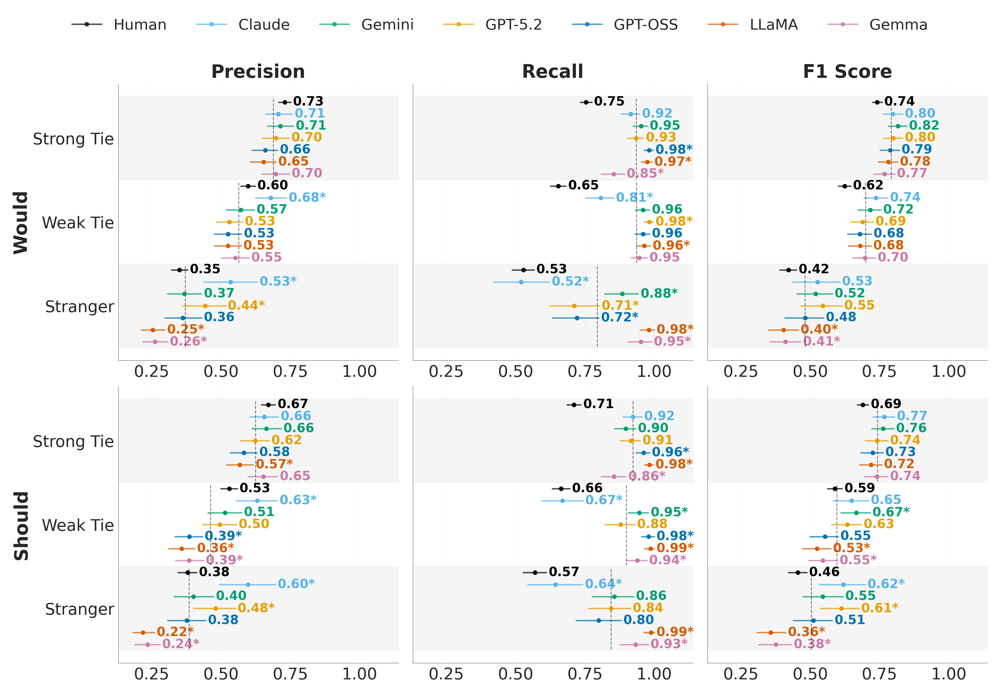

In [93]:
FONT_SIZE = 28
FIG_WIDTH = 36
FIG_HEIGHT = 16

metrics = ["precision", "recall", "f1"]
metric_titles = ["Precision", "Recall", "F1 Score"]

case_groups = {
    "Would": ["stranger_would", "acq_would", "friend_would"],
    "Should": ["stranger_should", "acq_should", "friend_should"],
}
cat_labels = ["Stranger", "Weak Tie", "Strong Tie"]

model_order = ["claude", "gemini", "gpt_5.2", "gpt_oss", "llama", "gemma"]
model_labels = ["Claude", "Gemini", "GPT-5.2", "GPT-OSS", "LLaMA", "Gemma"]

all_order = ["human", "claude", "gemini", "gpt_5.2", "gpt_oss", "llama", "gemma"]
all_labels = ["Human", "Claude", "Gemini", "GPT-5.2", "GPT-OSS", "LLaMA", "Gemma"]

colors = {
    "claude": "#56B4E9",
    "gemini": "#009E73",
    "gpt_5.2": "#E69F00",
    "gpt_oss": "#0072B2",
    "llama": "#D55E00",
    "gemma": "#CC79A7",
    "human": "#000000",
}

n_all = len(all_order)
n_cats = len(cat_labels)

fig, axes = plt.subplots(2, 3, figsize=(24, FIG_HEIGHT), sharey='row')

for row_idx, (group_name, case_list) in enumerate(case_groups.items()):
    for col_idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
        ax = axes[row_idx, col_idx]

        for cat_idx, (case_name, cat_label) in enumerate(zip(case_list, cat_labels)):
            if cat_idx % 2 == 0:
                ax.axhspan(
                    cat_idx * n_all - 0.5,
                    cat_idx * n_all + n_all - 0.5,
                    color='grey', alpha=0.08
                )

            llm_vals = []

            for model_idx, (model, model_label) in enumerate(zip(all_order[::-1], all_labels[::-1])):
                row = results_df[
                    (results_df["label_type"] == model) &
                    (results_df["case"] == case_name)
                ]

                if len(row) == 0:
                    continue

                val = row[metric].values[0]
                lo = row[f"{metric}_ci_lo"].values[0]
                hi = row[f"{metric}_ci_hi"].values[0]

                if model != "human":
                    llm_vals.append(val)

                y_pos = cat_idx * n_all + model_idx

                ax.plot(
                    [lo, hi], [y_pos, y_pos],
                    color=colors[model], linewidth=2.5, alpha=0.7,
                    solid_capstyle='round'
                )
                ax.plot(
                    val, y_pos, 'o',
                    color=colors[model], markersize=7, zorder=5,
                    label=model_label if (row_idx == 0 and col_idx == 0 and cat_idx == 0) else None
                )

                stars = sig_stars(row[f"{metric}_p"].values[0])
                label_text = f"{val:.2f}{stars}"
                ax.text(
                    hi + 0.008, y_pos, label_text,
                    va='center', ha='left',
                    fontsize=FONT_SIZE - 6, color=colors[model], fontweight='bold'
                )

            # LLM average line (excluding human)
            if llm_vals:
                avg_val = np.mean(llm_vals)
                y_top = cat_idx * n_all - 0.4
                y_bot = cat_idx * n_all + n_all - 0.6
                ax.plot(
                    [avg_val, avg_val], [y_top, y_bot],
                    color='black', linewidth=1.5, linestyle='--', alpha=0.5, zorder=4
                )

        ytick_positions = [cat_idx * n_all + (n_all - 1) / 2 for cat_idx in range(n_cats)]
        ax.set_yticks(ytick_positions)
        ax.set_yticklabels(cat_labels, fontsize=FONT_SIZE)

        ax.set_xlim(0.13, 1.14)
        ax.tick_params(axis='x', labelsize=FONT_SIZE)
        ax.grid(axis='x', alpha=0.25, linestyle='--', linewidth=0.8)
        ax.set_axisbelow(True)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.5)
        ax.spines['bottom'].set_linewidth(0.5)

        if row_idx == 0:
            ax.set_title(title, fontsize=FONT_SIZE+4, fontweight='bold', pad=10)

    axes[row_idx, 0].set_ylabel(group_name, fontsize=FONT_SIZE+4, fontweight='bold')

from matplotlib.lines import Line2D

legend_handles = []
for model, model_label in zip(all_order, all_labels):
    legend_handles.append(
        Line2D([0], [0], color=colors[model], marker='o', markersize=7,
               linewidth=2.5, alpha=0.7, label=model_label)
    )

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=n_all,
    fontsize=FONT_SIZE-2,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Action Distribution

In [94]:
y_true_series = {}

for case_name, col in cases.items():
    y_true_series[case_name] = human_consensus(df_agg, col, True)

In [95]:
props = pd.DataFrame({
    'Friend': [y_true_series['friend_would'].sum() / y_true_series['friend_would'].count(),
               y_true_series['friend_should'].sum() / y_true_series['friend_should'].count(),],
    'Acquaintance': [y_true_series['acq_would'].sum() / y_true_series['acq_would'].count(),
                     y_true_series['acq_should'].sum() / y_true_series['acq_should'].count(),],
    'Stranger': [y_true_series['stranger_would'].sum() / y_true_series['stranger_would'].count(),
                 y_true_series['stranger_should'].sum() / y_true_series['stranger_should'].count()],
}, index=['Would', 'Should'])

props

,Friend,Acquaintance,Stranger
Would,0.617647,0.504525,0.235294
Should,0.531674,0.334842,0.205882


#### Individual Actions

In [96]:
ACTIONS = {
    1: "Do nothing",
    2: "Stay away",
    3: "Gossip",
    4: "Verbal confrontation",
    5: "Physical confrontation",
    6: "Inform authority",
    7: "Support",
    8: "Praise",
}

ACTION_NORMALIZATION = {
    "Do nothing": 1,

    "Stay away": 2,
    "Stay away or keep a distance from the actor": 2,

    "Gossip": 3,
    "Gossip about / discuss with / complain to others informally": 3,

    "Verbal confrontation": 4,
    "Verbal reprimand / verbal confrontation": 4,

    "Physical confrontation": 5,

    "Inform authority": 6,
    "Inform the authorities, such as the police": 6,

    "Support": 7,
    "Support the actor": 7,

    "Praise": 8,
    "Celebrate / praise": 8,
}

REACTION_COLS = {
    ("friends", "would"): "friends_reaction",
    ("friends", "should"): "friends_reaction_should",
    ("acquaintances", "would"): "acquaintances_reaction",
    ("acquaintances", "should"): "acquaintances_reaction_should",
    ("strangers", "would"): "strangers_reaction",
    ("strangers", "should"): "strangers_reaction_should",
}

def normalize_action(action):
    if pd.isna(action):
        return None
    return ACTION_NORMALIZATION.get(action.strip(), None)


def build_action_vector_union(actions):
    """Union (used for models)"""
    vec = np.zeros(8, dtype=int)
    for a in actions:
        if a is not None:
            vec[a - 1] = 1
    return vec


def build_action_vector_consensus(actions, n_annotators):
    """Consensus = majority of annotators"""
    counts = pd.Series(actions).value_counts()
    threshold = n_annotators / 2

    vec = np.zeros(8, dtype=int)
    for a, c in counts.items():
        if a is not None and c > threshold:
            vec[a - 1] = 1
    return vec

# Build vectors
rows = []

for (ID, rater), sub in df.groupby(["ID", "label_type"]):
    for (distance, mode), col in REACTION_COLS.items():
        actions = sub[col].apply(normalize_action)

        if rater == "human":
            # Aggregate to one action per annotator per ID
            sub_actions = pd.DataFrame({
                "human_id": sub["human_id"].values,
                "action": actions.values
            }).dropna(subset=["action"])

            # Take max action per annotator (strongest reaction)
            agg_actions = sub_actions.groupby("human_id")["action"].max()

            n_annotators = agg_actions.nunique() if len(agg_actions) > 0 else 0
            n_annotators = len(agg_actions)  # count of unique annotators who responded
            vec = build_action_vector_consensus(agg_actions.values, n_annotators)
        else:
            vec = build_action_vector_union(actions)

        rows.append({
            "ID": ID,
            "label_type": rater,
            "distance": distance,
            "mode": mode,
            "vector": vec,
        })

vectors_df = pd.DataFrame(rows)

# Align human + models
pivot = (
    vectors_df
    .pivot(index=["ID", "distance", "mode"], columns="label_type", values="vector")
    .dropna()
)

def extract_matrix(pivot, label, distance, mode):
    return np.vstack(
        pivot.loc[(slice(None), distance, mode), label].values
    )

labels = ["human", "llama", "gemma", "gpt_oss", "claude", "gemini", "gpt_5.2"]
distances = ["friends", "acquaintances", "strangers"]
modes = ["would", "should"]

# Extract matrices
matrices = {}

for label in labels:
    for dist in distances:
        for mode in modes:

            key = f"{label}_{dist}_{mode}"

            matrices[key] = extract_matrix(pivot, label, dist, mode)

# HUMAN
human_friend_would_X = matrices["human_friends_would"]
human_friend_should_X = matrices["human_friends_should"]

human_acq_would_X = matrices["human_acquaintances_would"]
human_acq_should_X = matrices["human_acquaintances_should"]

human_str_would_X = matrices["human_strangers_would"]
human_str_should_X = matrices["human_strangers_should"]

# GPT
gpt_friend_would_X = matrices["gpt_5.2_friends_would"]
gpt_friend_should_X = matrices["gpt_5.2_friends_should"]

gpt_acq_would_X = matrices["gpt_5.2_acquaintances_would"]
gpt_acq_should_X = matrices["gpt_5.2_acquaintances_should"]

gpt_str_would_X = matrices["gpt_5.2_strangers_would"]
gpt_str_should_X = matrices["gpt_5.2_strangers_should"]

# CLAUDE
claude_friend_would_X = matrices["claude_friends_would"]
claude_friend_should_X = matrices["claude_friends_should"]

claude_acq_would_X = matrices["claude_acquaintances_would"]
claude_acq_should_X = matrices["claude_acquaintances_should"]

claude_str_would_X = matrices["claude_strangers_would"]
claude_str_should_X = matrices["claude_strangers_should"]

# GEMINI
gemini_friend_would_X = matrices["gemini_friends_would"]
gemini_friend_should_X = matrices["gemini_friends_should"]

gemini_acq_would_X = matrices["gemini_acquaintances_would"]
gemini_acq_should_X = matrices["gemini_acquaintances_should"]

gemini_str_would_X = matrices["gemini_strangers_would"]
gemini_str_should_X = matrices["gemini_strangers_should"]

# GPT OSS
gpt_oss_friend_would_X = matrices["gpt_oss_friends_would"]
gpt_oss_friend_should_X = matrices["gpt_oss_friends_should"]

gpt_oss_acq_would_X = matrices["gpt_oss_acquaintances_would"]
gpt_oss_acq_should_X = matrices["gpt_oss_acquaintances_should"]

gpt_oss_str_would_X = matrices["gpt_oss_strangers_would"]
gpt_oss_str_should_X = matrices["gpt_oss_strangers_should"]

# LLAMA
llama_friend_would_X = matrices["llama_friends_would"]
llama_friend_should_X = matrices["llama_friends_should"]

llama_acq_would_X = matrices["llama_acquaintances_would"]
llama_acq_should_X = matrices["llama_acquaintances_should"]

llama_str_would_X = matrices["llama_strangers_would"]
llama_str_should_X = matrices["llama_strangers_should"]

# GEMMA
gemma_friend_would_X = matrices["gemma_friends_would"]
gemma_friend_should_X = matrices["gemma_friends_should"]

gemma_acq_would_X = matrices["gemma_acquaintances_would"]
gemma_acq_should_X = matrices["gemma_acquaintances_should"]

gemma_str_would_X = matrices["gemma_strangers_would"]
gemma_str_should_X = matrices["gemma_strangers_should"]

In [97]:
action_names = list(ACTIONS.values())
llm_labels = ["claude", "gemini", "gpt_5.2", "gpt_oss", "llama", "gemma"]
distances = ["friends", "acquaintances", "strangers"]
modes = ["would", "should"]

results = []

for dist in distances:
    for mode in modes:
        for act_idx, act_name in enumerate(action_names):

            y_true_dict = {}
            y_pred_dict = {}
            metrics_dict = {}

            h_key = f"human_{dist}_{mode}"
            h_matrix = matrices[h_key]

            for model in llm_labels:
                m_key = f"{model}_{dist}_{mode}"
                m_matrix = matrices[m_key]

                y_true = pd.Series(h_matrix[:, act_idx])
                y_pred = pd.Series(m_matrix[:, act_idx])

                y_true_dict[model] = y_true
                y_pred_dict[model] = y_pred
                metrics_dict[model] = compute_metrics(y_true.values, y_pred.values)

            boot_results = bootstrap_ci_with_significance(y_true_dict, y_pred_dict)

            for model in llm_labels:
                results.append({
                    "label_type": model,
                    "distance": dist,
                    "mode": mode,
                    "action": act_name,
                    **metrics_dict[model],
                    **boot_results[model],
                })

results_action_df = pd.DataFrame(results)
results_action_df

,label_type,distance,mode,action,precision,recall,f1,accuracy,precision_ci_lo,precision_ci_hi,precision_p,recall_ci_lo,recall_ci_hi,recall_p,f1_ci_lo,f1_ci_hi,f1_p,accuracy_ci_lo,accuracy_ci_hi,accuracy_p
0,claude,friends,would,Do nothing,0.181818,0.368421,0.243478,0.803167,0.095719,0.268671,0.521739,0.210526,0.533333,0.060970,0.137222,0.344840,0.309845,0.764706,0.839367,0.044978
1,gemini,friends,would,Do nothing,0.191489,0.236842,0.211765,0.848416,0.085106,0.311146,0.709645,0.107096,0.375000,0.969515,0.097561,0.322581,0.696652,0.814480,0.880090,0.492754
2,gpt_5.2,friends,would,Do nothing,0.285714,0.105263,0.153846,0.900452,0.066667,0.555556,0.520740,0.024390,0.212804,0.015992,0.037020,0.290928,0.486757,0.871041,0.927602,0.001000
3,gpt_oss,friends,would,Do nothing,0.200000,0.184211,0.191781,0.866516,0.074074,0.342857,0.873563,0.066613,0.326549,0.398801,0.068966,0.320988,0.982509,0.834842,0.895928,0.046977
4,llama,friends,would,Do nothing,0.285714,0.105263,0.153846,0.900452,0.066667,0.545455,0.505747,0.023810,0.216216,0.017991,0.037718,0.290909,0.505747,0.868778,0.927602,0.001000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,gemini,strangers,should,Praise,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
284,gpt_5.2,strangers,should,Praise,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
285,gpt_oss,strangers,should,Praise,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
286,llama,strangers,should,Praise,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000


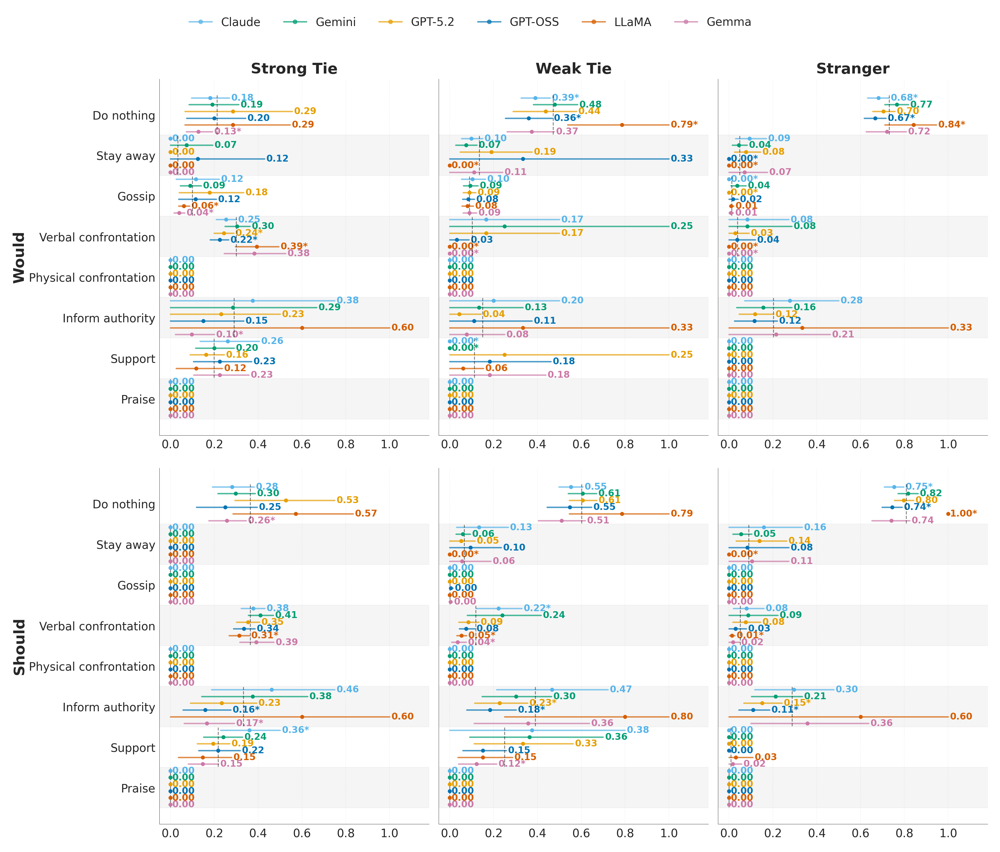

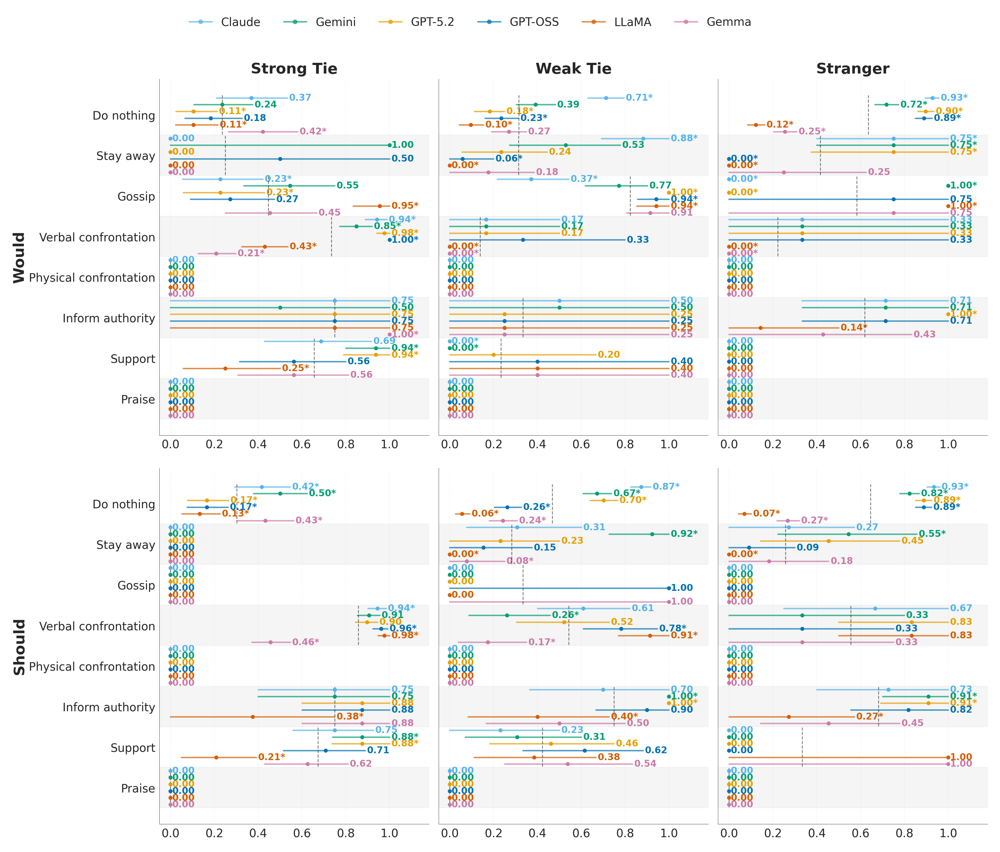

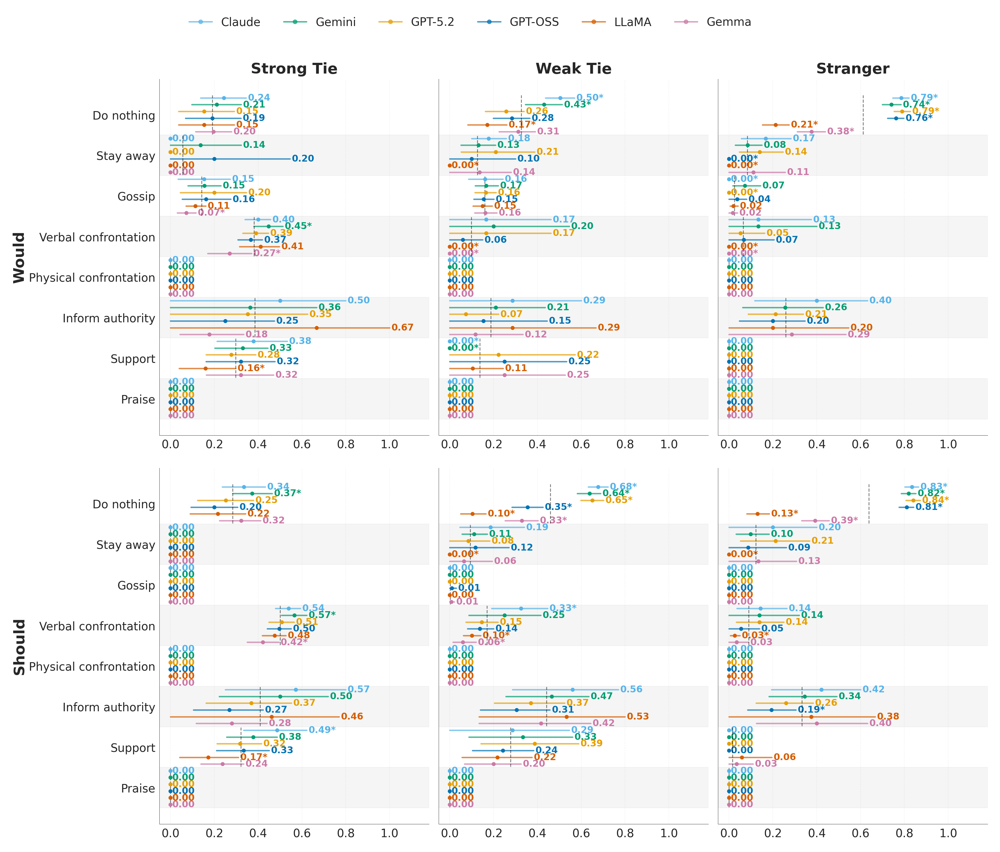

In [98]:
FONT_SIZE = 24
FIG_WIDTH = 24
FIG_HEIGHT = 10

action_names_ordered = [
    "Do nothing", "Stay away", "Gossip",
    "Verbal confrontation", "Physical confrontation",
    "Inform authority", "Support", "Praise",
]

distance_labels = {
    "friends": "Strong Tie",
    "acquaintances": "Weak Tie",
    "strangers": "Stranger",
}

model_order = ["claude", "gemini", "gpt_5.2", "gpt_oss", "llama", "gemma"]
model_labels = ["Claude", "Gemini", "GPT-5.2", "GPT-OSS", "LLaMA", "Gemma"]

colors = {
    "claude": "#56B4E9",
    "gemini": "#009E73",
    "gpt_5.2": "#E69F00",
    "gpt_oss": "#0072B2",
    "llama": "#D55E00",
    "gemma": "#CC79A7",
}

n_models = len(model_order)
n_actions = len(action_names_ordered)

metrics = ["precision", "recall", "f1"]
metric_titles = ["Precision", "Recall", "F1 Score"]

modes = ["would", "should"]
mode_labels = ["Would", "Should"]
distances = ["friends", "acquaintances", "strangers"]

for metric, metric_title in zip(metrics, metric_titles):

    fig, axes = plt.subplots(2, 3, figsize=(FIG_WIDTH, FIG_HEIGHT * 2), sharey=True)

    for row_idx, (mode, mode_label) in enumerate(zip(modes, mode_labels)):
        for col_idx, dist in enumerate(distances):
            ax = axes[row_idx, col_idx]

            for act_idx, act_name in enumerate(reversed(action_names_ordered)):
                if act_idx % 2 == 0:
                    ax.axhspan(
                        act_idx * n_models - 0.5,
                        act_idx * n_models + n_models - 0.5,
                        color='grey', alpha=0.08
                    )

                cat_vals = []

                for model_idx, (model, model_label) in enumerate(zip(model_order[::-1], model_labels[::-1])):
                    row = results_action_df[
                        (results_action_df["label_type"] == model) &
                        (results_action_df["distance"] == dist) &
                        (results_action_df["mode"] == mode) &
                        (results_action_df["action"] == act_name)
                    ]

                    if len(row) == 0:
                        continue

                    val = row[metric].values[0]
                    lo = row[f"{metric}_ci_lo"].values[0]
                    hi = row[f"{metric}_ci_hi"].values[0]
                    cat_vals.append(val)

                    y_pos = act_idx * n_models + model_idx

                    ax.plot(
                        [lo, hi], [y_pos, y_pos],
                        color=colors[model], linewidth=2.5, alpha=0.7,
                        solid_capstyle='round'
                    )
                    ax.plot(
                        val, y_pos, 'o',
                        color=colors[model], markersize=6, zorder=5,
                        label=model_label if (row_idx == 0 and col_idx == 0 and act_idx == 0) else None
                    )
                    stars = sig_stars(row[f"{metric}_p"].values[0])
                    label_text = f"{val:.2f}{stars}"
                    ax.text(
                        hi + 0.008, y_pos, label_text,
                        va='center', ha='left',
                        fontsize=FONT_SIZE - 8, color=colors[model], fontweight='bold'
                    )
                # Average line
                if cat_vals:
                    avg_val = np.mean(cat_vals)
                    y_top = act_idx * n_models - 0.4
                    y_bot = act_idx * n_models + n_models - 0.6
                    ax.plot(
                        [avg_val, avg_val], [y_top, y_bot],
                        color='black', linewidth=1.5, linestyle='--', alpha=0.5, zorder=4
                    )

            ytick_positions = [act_idx * n_models + (n_models - 1) / 2 for act_idx in range(n_actions)]
            ax.set_yticks(ytick_positions)
            ax.set_yticklabels(list(reversed(action_names_ordered)), fontsize=FONT_SIZE - 4)

            ax.set_xlim(-0.05, 1.18)
            ax.tick_params(axis='x', labelsize=FONT_SIZE - 4)
            ax.grid(axis='x', alpha=0.25, linestyle='--', linewidth=0.8)
            ax.set_axisbelow(True)

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(0.5)
            ax.spines['bottom'].set_linewidth(0.5)

            if row_idx == 0:
                ax.set_title(distance_labels[dist], fontsize=FONT_SIZE + 2, fontweight='bold', pad=10)

        axes[row_idx, 0].set_ylabel(mode_label, fontsize=FONT_SIZE + 2, fontweight='bold')

    legend_handles = []
    legend_labels = []
    for model, model_label in zip(model_order, model_labels):
        legend_handles.append(
            Line2D([0], [0], color=colors[model], marker='o', markersize=7,
                   linewidth=2.5, alpha=0.7)
        )
        legend_labels.append(model_label)

    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        loc="upper center",
        bbox_to_anchor=(0.47, 1.02),
        ncol=n_models,
        fontsize=FONT_SIZE - 4,
        frameon=False
    )

    # fig.suptitle(metric_title, fontsize=FONT_SIZE + 4, fontweight='bold', y=1.06)
    fig.savefig(f"action_{metric}.png", bbox_inches='tight', dpi=300)
    plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=3)
    plt.show()

### Minor Agreement (>= 2)

#### Action Distribution

In [99]:
y_true_series = {}

for case_name, col in cases.items():
    y_true_series[case_name] = human_consensus(df_human, col)

In [100]:
props = pd.DataFrame({
    'Friend': [y_true_series['friend_would'].sum() / y_true_series['friend_would'].count(),
               y_true_series['friend_should'].sum() / y_true_series['friend_should'].count(),],
    'Acquaintance': [y_true_series['acq_would'].sum() / y_true_series['acq_would'].count(),
                     y_true_series['acq_should'].sum() / y_true_series['acq_should'].count(),],
    'Stranger': [y_true_series['stranger_would'].sum() / y_true_series['stranger_would'].count(),
                 y_true_series['stranger_should'].sum() / y_true_series['stranger_should'].count()],
}, index=['Would', 'Should'])

props

,Friend,Acquaintance,Stranger
Would,0.825792,0.776018,0.592760
Should,0.739819,0.604072,0.459276
